---
title: Solving LinkedIn Patches by Linear Optimization
short_title: How to Solve Patches
date: 2026-04-10
math:
    \yellowbox: '\color{#846A0B}{ \blacksquare }'
    \tealbox: '\color{#096B78}{ \blacksquare }'
    \purplebox: '\color{#5A3DB1}{ \blacksquare }'
    \greenbox: '\color{#0A7541}{ \blacksquare }'
    \orangebox: '\color{#EF6C00}{ \blacksquare }'
    \redbox: '\color{#E30102}{ \blacksquare }'
    \bluebox: '\color{#097BB1}{ \blacksquare }'
    \magentabox: '\color{#A01E4E}{ \blacksquare }'
    \brickbox: '\color{#9B3C1C}{ \blacksquare }'
    \brownbox: '\color{#503B36}{ \blacksquare }'
downloads:
    - file: patches.ipynb
      title: This notebook
      filename: patches.ipynb
---

![Patches Banner](../../assets/how-to-solve/patches/banner.jpg)

# How to Play Patches

Pathes is a game adapted from [Shikaku](https://pt.wikipedia.org/wiki/Sikaku) (四角に切れ, _shikaku ni kire_), a japanese puzzle created by the puzzle-specialized publisher Nikoli on 2011.

Shikaku is played on a grid. Some of the squares on the grid contain numbers. The goal is to divide the grid into rectangular pieces such that each piece contains exactly one number, and each number represents the area of ​​the patch.

:::{figure} ../../assets/how-to-solve/patches/shikaku-2026-08-17-medium.png
:label: shikaku-example
:alt: Medium Shikaku 2026-08-17
:align: center
:width: 60%
Example of a Shikaku grid. _Source: [Shikaku of the Day](https://shikakuofthe.day/medium/260817)_
:::

:::{figure} ../../assets/how-to-solve/patches/shikaku-2026-08-17-medium-solution.png
:label: shikaku-solution-example
:alt: Solution of Medium Shikaku 2026-08-17
:align: center
:width: 60%
Solution of a Shikaku example. _Source: [Shikaku of the Day](https://shikakuofthe.day/medium/260817)_
:::

The Patches' grid contains some colored **patch seeds** that may state some features about the rectangles to be drawn on the grid, such as the required area (optional) or required shape (which can be a **vertical** rectangle, a **horizontal** rectangle, a **square** or **any** shape).

:::{figure} ../../assets/how-to-solve/patches/example.mp4
:label: patches-example
:alt: Patches example
:align: center
:width: 60%
Example of Patches mini game. _Source: [LinkedIn Patches](https://www.linkedin.com/games/patches)_
:::

Objective
: Partition the grid into non-overlapping rectangular patches so that each patch meets the prescriptions on their respective seeds.

Rules
: Each seed must be covered by only one patch that attends its prescriptions;
: A patch must cover only one seed;
: Specifically for the Patches game, the area of ​​all patches must be greater than 1 square. That is, rectangles with dimensions 1 $\times$ 1 are not allowed.

# Problem Modeling

## Ranges

Basically, we'll have three ranges for defining all the next components: a range for rows, columns and ractangles.

$I = \{1, \cdots, m\}$
: The row range, where $m$ is the total amount of rows on game grid.

$J = \{1, \cdots, n\}$
: The column range, where $n$ is the total amount of columns on game grid.

$K = \{1, \cdots, p\}$
: Range of all patches to be drawn on grid game, where $p$ is the total of patch seeds on grid.

## Sets

From $I$, $J$ and $K$ ranges, we can define the following sets:

$S = I \times J = \{(i,j) \mid \forall i \in I, \forall j \in J\}$
: Set of all grid squares, that is just the Cartesian product between sets $I$ and $J$.

$E = \{(i,j,k) \mid  i \in I, j \in J, k \in K\} \subset I \times J \times K$
: Set of all squares $(i,j)$ that carry a seed about a patch $k$.

$V \subseteq K$
: Set of required vertical patches, i. e., patches whose height is greater than its width.

$H \subseteq K$
: Set of required horizontal patches, i. e., patches whose width is greater than its height.

$Q \subseteq K$
: Set of required square patches, i. e., patches whose width is equal to its height.

$A \subseteq K$
: Set of patches with a required area $a_k$.

## Decision Variables

For Patches game, it'll have seven sets of decision varibles.

### Integer Variables

The following integer variables will be used to define the position and dimensions of the patches, which are the set of variables that solves the game:

$l_k \in I, \forall k \in K$
: Index of the leftmost column of the patch $k$.

$t_k \in J, \forall k \in K$
: Index of the top row of the patch $k$.

$w_k \in I, \forall k \in K$
: Width of the patch $k$.

$h_k \in J, \forall k \in K$
: Height of the patch $k$.

### Binary Variables

However, in order to ensure the rectangularity and continuity of the geometric shapes and their required areas, it is necessary to use the following auxiliary binary variables:

$u_{ik} \in \B, \forall (i,k) \in I \times K$
: $u_{ik} = 1$, if the row $i$ passes through the patch $k$
: $u_{ik} = 0$, otherwise

$v_{jk} \in \B, \forall (j,k) \in J \times K$
: $v_{jk} = 1$, if the column $j$ passes through the patch $k$
: $v_{jk} = 0$, otherwise

$x_{ijk} \in \B, \forall (i,j,k) \in I \times J \times K$
: $x_{ijk} = 1$, if the square $(i,j)$ will be covered by patch $k$.
: $x_{ijk} = 0$, otherwise

:::{note} The link between the binary variables
Further on, we'll put constraints that links the variables $x_{ijk}$ with the variables $u_{ik}$ and $v_{jk}$, which will ensure that if a row $i$ and a column $j$ pass through a patch $k$, then the square $(i,j)$ will must be covered by that patch $k$. Also, if $u_{ik}=0$ or $v_{jk}=0$, then $x_{ijk}$ must be zero, which will ensure that if a row or column does not pass through a patch, then the square $(i,j)$ will not be covered by it.
:::

## Parameters

$a_k \in \N$
: Required area for the patch $k \in A$.

## Objective Function

Since we only want to find a solution that satisfies all the rules of the game, the objective function of Patches' model is a constant. Therefore, the LOP is a **feasibility** problem, whose objective function consists of maximizing (or minimizing) an arbitrary constant.

$$\text{Max} \ C$$

## Constraints

Domain Constraints
: First, let's settle the sets of constraints for the domain of decision variables.

    Integrity Constraints
    : The main decision variables must be integers.
    : $$l_k \in \N, \forall k \in K$$
    : $$t_k \in \N, \forall k \in K$$
    : $$w_k \in \N, \forall k \in K$$
    : $$h_k \in \N, \forall k \in K$$

    Binarity Constraints
    : The auxiliary decision variables must be binary.
    : $$u_{ik} \in \B, \forall (i,k) \in I \times K$$
    : $$v_{jk} \in \B, \forall (j,k) \in J \times K$$
    : $$x_{ijk} \in \B, \forall (i,j,k) \in I \times J \times K$$

Unique-Patch-Per-Square Constraints
: Each grid square $(i,j)$ must be covered by only one patch $k$.
: $$ \sum_{k \in K}{x_{ijk}} = 1, \forall (i,j) \in S $$

Grid-Boundaries Constraints
: These sets of constraints ensure that any patch $k$ lies within the grid's row and column boundaries.

    Top-Row-Position Constraints
    : For each patch $k$, the position $t_k$ of its top row must be equal or greater than 1.
    : $$t_k \ge 1, \forall k \in K$$

    Bottom-Row-Position Constraints
    : For each patch $k$, the position of its bottom row, given by the expression $t_k + h_k - 1$, must be equal or less than the total amount of rows $n$.
    : $$t_k + h_k - 1 \le n, \forall k \in K$$

    Leftmost-Column-Position Constraints
    : For each patch $k$, the position $l_k$ of its leftmost column must be equal or greater than 1.
    : $$l_k \ge 1, \forall k \in K$$

    Rightmost-Column-Position Constraints
    : For each patch $k$, the position of its rightmost column, given by the expression $l_k + w_k - 1$, must be equal or less than the total amount of columns $m$.
    : $$l_k + w_k - 1 \le m, \forall k \in K$$

Patch-Boundaries Constraints
: These sets of constraints uses the Big $M$ strategy to ensure that any row $i$ and column $j$ that passes through a patch $k$ lies within its boundaries.

    Top-Boundary Constraints
    : if a row $i$ passes through a patch $k$, then the index $i$ must be equal or greater than its top row's index $t_k$.
    : $$t_k - i \le M(1 - u_{ik}), \forall (i,k) \in I \times K$$

    Bottom-Boundary Constraints
    : if a square $(i,j)$ is covered by patch $k$, then the index $i$ must be equal or less than the patch's bottom row's index, given by $t_k + h_k - 1$.
    : $$i - (t_k + h_k - 1) \le M(1 - u_{ik}), \forall (i,k) \in I \times K$$

    :::{tip} How big should my Big M be for constraints about row position?
    The value of $M$ sufficiently large for row $i$ to respect the boundaries of patch $k$ is the total number of rows on the grid, i.e., $M \ge m$.
    :::

    Leftmost-Boundary Constraints
    : if a colum $j$ passes through patch $k$, then the index $j$ must be equal or greater than patch's rightmost column's index $l_k$.
    : $$l_k - j \le M(1 - v_{jk}), \forall (j,k) \in J \times K$$

    Rightmost-Boundary Constraints
    : if a colum $j$ passes through patch $k$, then the index $j$ must be equal or less the patch's last column's index, given by $l_k + w_k - 1$.
    : $$j - (l_k + w_k - 1) \le M(1 - v_{jk}), \forall (j,k) \in J \times K$$

    :::{tip} How big should my Big M be for constraints about square's column position?
    The value of $M$ sufficiently large for the column $j$ to respect the boundaries of patch $k$ is the total number of columns on the grid, i.e., $M \ge n$.
    :::

:::{note}
The last set of constraints ensures that, if $u_{ik} = 1$, then the row $i$ will be inside the patch $k$ (and the same logic is applied to columns for $v_{jk}$). However, it DOES NOT ensure otherwise. That is, it's possible that a certain row $i$ may be end up inside patch $k$ even if $u_{ik}=0$ (and the same may happen for the columns). It's possible to avoid it by simply imposing the sum of all selected rows $u_{ik}$ for each patch $k$ to be equal to its height $h_k$ and by imposing the sum of all selected columns $v_{jk}$ for each patch $k$ to be equal to its width $w_k$. These sets of constraints are modeled as following.
:::

Patch Dimensions constraints
: These constraints are important to ensure that there'll not be any gap inside the patches.

    Height Constraints
    : The sum of all selected rows $u_{ik}$ for a patch $k$ must be equal to its height.
    : $$ \sum_{i \in I}{u_{ik}} = h_k, \forall k \in K$$

    Width Constraints
    : The sum of all selected columns $v_{jk}$ for a patch $k$ must be equal to its width.
    : $$ \sum_{j \in J}{v_{jk}} = w_k, \forall k \in K$$

McCormick Linearization Constraints
: These sets of constraints translates the non-linear contraint $x_{ijk} = u_{ik} \times v_{jk}$ between the binary varibles in the model into three sets of linear constraints. They will ensure that if a row $i$ and a column $j$ pass through a patch $k$, then the square $(i,j)$ will must be covered by that patch $k$. Also, if $u_{ik}=0$ or $v_{jk}=0$, then $x_{ijk}$ must be zero, which will ensure that if a row or column does not pass through a patch, then the square $(i,j)$ will not be covered by it.

    Cutout-Row Constraints
    : If a row $i$ doesn't pass through a patch $k$, then all squares in that row must not be covered by that patch.
    : $$\sum_{j \in J}{x_{ijk}} \le n \cdot u_{ik}, \forall (i,k) \in I \times K$$

    Cutout-Column Constraints
    : If a column $j$ doesn't pass through a patch $k$, then all squares in that column must not be covered by that patch.
    : $$\sum_{i \in I}{x_{ijk}} \le m \cdot v_{jk}, \forall (j,k) \in J \times K$$

    Square-Activator Constraints
    : If both row $i$ and column $j$ pass the patch $k$, then the square at this intersection must be covered by that patch.
    : $$x_{ijk} \ge u_{ik} + v_{jk} - 1, \forall (i,j,k) \in I \times J \times K$$

Seed Square Constraints
: These sets of constraints deal with prescriptions required by the seed squares.

    Seed Square Coverage Constraints
    : For each square $(i,j)$ with a seed about patch $k$, it must be covered by $k$.
    : $$x_{ijk} = 1, \forall (i,j,k) \in T$$

    Area Constraints
    : For each patch $k$ with a predefined area $a_k$, the sum of its covered squares $x_{ijk}$ must be equal to $a_k$
    : $$\sum_{(i,j) \in S}{x_{ijk}} = a_k, \forall k \in A$$

    Vertical Patch Constraints
    : For each vertical patch $k$, its height $h_k$ must be greater than its width $w_k$.
    : $$w_k < h_k, \forall k \in V$$

    Horizontal Patch Constraints
    : For each horizontal patch $k$, its width $w_k$ must be greater than its height $h_k$.
    : $$w_k > h_k, \forall k \in H$$

    Square Patch Constraints
    : For each square patch $k$, its width $w_k$ must be equal to its height $h_k$.
    : $$w_k = h_k, \forall k \in Q$$

# Abstract Model

With all components defined, we have the following abstract model for Patches game:

:::{math}
:enumerated: false
\text{Min } \ C
:::

$$
\begin{array}{rll}
    \text{S.t.:} & & \\
    & x_{ijk} \ge u_{ik} + v_{jk} - 1,     & \forall (i,j,k) \in I \times J \times K \\
    & t_k \ge 1,                           & \forall k \in K \\
    & t_k + h_k - 1 \le n,                 & \forall k \in K \\
    & l_k \ge 1,                           & \forall k \in K \\
    & l_k + w_k - 1 \le m,                 & \forall k \in K \\
    & t_k - i \le m(1-u_{ik}),             & \forall (i,k) \in I \times K \\
    & i - (t_k + h_k - 1) \le m(1-u_{ik}), & \forall (i,k) \in I \times K \\
    & l_k - j \le n(1-v_{jk}),             & \forall (j,k) \in J \times K \\
    & j - (l_k + w_k - 1) \le n(1-v_{jk}), & \forall (j,k) \in J \times K \\
    & \sum_{i \in I}{u_{ik}} = h_k,        & \forall k \in K \\
    & \sum_{j \in J}{v_{jk}} = w_k,        & \forall k \in K \\
    & \sum_{k \in K}{x_{ijk}} = 1,         & \forall (i,j) \in S \\
    & \sum_{j \in J}{x_{ijk}} \le nu_{ik}, & \forall (i,k) \in I \times K \\
    & \sum_{i \in I}{x_{ijk}} \le mv_{jk}, & \forall (j,k) \in J \times K \\
    & x_{ijk} = 1,                         & \forall (i,j,k) \in E \\
    & \sum_{(i,j) \in S}{x_{ijk}} = a_k,   & \forall k \in A \\
    & w_k < h_k,                           & \forall k \in V \\
    & w_k > h_k,                           & \forall k \in H \\
    & w_k = h_k,                           & \forall k \in Q \\
    & l_k \in \N,                          & \forall k \in K \\
    & t_k \in \N,                          & \forall k \in K \\
    & w_k \in \N,                          & \forall k \in K \\
    & h_k \in \N,                          & \forall k \in K \\
    & u_{ij} \in \B,                       & \forall (i,k) \in I \times K \\
    & v_{jk} \in \B,                       & \forall (j,k) \in J \times K \\
    & x_{ijk} \in \B,                      & \forall (i,j,k) \in I \times J \times K \\
\end{array}
$$

# Concrete model

The Patches game to be solved will be the No. 16, published on April 2{sup}`nd`, 2026.

:::{figure} ../../assets/how-to-solve/patches/problem.jpg
:label: patches-problem
:alt: Patches problem instance
:align: center
:width: 60%
Patches problem instance used in this article. _Source: [LinkedIn Patches](https://www.linkedin.com/games/patches)_
:::

And you concrete model is as the following:

:::{math}
:enumerated: false
\text{Min} \ 0
:::

S.t.:

Unique-Patch-Per-Square Constraints
: $x_{11\yellowbox} + x_{11\tealbox} + x_{11\purplebox} + x_{11\greenbox} + x_{11\orangebox} + x_{11\redbox} + x_{11\bluebox} + x_{11\magentabox} + x_{11\brickbox} + x_{11\brownbox} = 1 $ {sub}`_Square (1,1)_`
: $x_{12\yellowbox} + x_{12\tealbox} + x_{12\purplebox} + x_{12\greenbox} + x_{12\orangebox} + x_{12\redbox} + x_{12\bluebox} + x_{12\magentabox} + x_{12\brickbox} + x_{12\brownbox} = 1 $ {sub}`_Square (1,2)_`
: $x_{13\yellowbox} + x_{13\tealbox} + x_{13\purplebox} + x_{13\greenbox} + x_{13\orangebox} + x_{13\redbox} + x_{13\bluebox} + x_{13\magentabox} + x_{13\brickbox} + x_{13\brownbox} = 1 $ {sub}`_Square (1,3)_`
: $x_{14\yellowbox} + x_{14\tealbox} + x_{14\purplebox} + x_{14\greenbox} + x_{14\orangebox} + x_{14\redbox} + x_{14\bluebox} + x_{14\magentabox} + x_{14\brickbox} + x_{14\brownbox} = 1 $ {sub}`_Square (1,4)_`
: $x_{15\yellowbox} + x_{15\tealbox} + x_{15\purplebox} + x_{15\greenbox} + x_{15\orangebox} + x_{15\redbox} + x_{15\bluebox} + x_{15\magentabox} + x_{15\brickbox} + x_{15\brownbox} = 1 $ {sub}`_Square (1,5)_`
: $x_{16\yellowbox} + x_{16\tealbox} + x_{16\purplebox} + x_{16\greenbox} + x_{16\orangebox} + x_{16\redbox} + x_{16\bluebox} + x_{16\magentabox} + x_{16\brickbox} + x_{16\brownbox} = 1 $ {sub}`_Square (1,6)_`
: $x_{21\yellowbox} + x_{21\tealbox} + x_{21\purplebox} + x_{21\greenbox} + x_{21\orangebox} + x_{21\redbox} + x_{21\bluebox} + x_{21\magentabox} + x_{21\brickbox} + x_{21\brownbox} = 1 $ {sub}`_Square (2,1)_`
: $x_{22\yellowbox} + x_{22\tealbox} + x_{22\purplebox} + x_{22\greenbox} + x_{22\orangebox} + x_{22\redbox} + x_{22\bluebox} + x_{22\magentabox} + x_{22\brickbox} + x_{22\brownbox} = 1 $ {sub}`_Square (2,2)_`
: $x_{23\yellowbox} + x_{23\tealbox} + x_{23\purplebox} + x_{23\greenbox} + x_{23\orangebox} + x_{23\redbox} + x_{23\bluebox} + x_{23\magentabox} + x_{23\brickbox} + x_{23\brownbox} = 1 $ {sub}`_Square (2,3)_`
: $x_{24\yellowbox} + x_{24\tealbox} + x_{24\purplebox} + x_{24\greenbox} + x_{24\orangebox} + x_{24\redbox} + x_{24\bluebox} + x_{24\magentabox} + x_{24\brickbox} + x_{24\brownbox} = 1 $ {sub}`_Square (2,4)_`
: $x_{25\yellowbox} + x_{25\tealbox} + x_{25\purplebox} + x_{25\greenbox} + x_{25\orangebox} + x_{25\redbox} + x_{25\bluebox} + x_{25\magentabox} + x_{25\brickbox} + x_{25\brownbox} = 1 $ {sub}`_Square (2,5)_`
: $x_{26\yellowbox} + x_{26\tealbox} + x_{26\purplebox} + x_{26\greenbox} + x_{26\orangebox} + x_{26\redbox} + x_{26\bluebox} + x_{26\magentabox} + x_{26\brickbox} + x_{26\brownbox} = 1 $ {sub}`_Square (2,6)_`
: $x_{31\yellowbox} + x_{31\tealbox} + x_{31\purplebox} + x_{31\greenbox} + x_{31\orangebox} + x_{31\redbox} + x_{31\bluebox} + x_{31\magentabox} + x_{31\brickbox} + x_{31\brownbox} = 1 $ {sub}`_Square (3,1)_`
: $x_{32\yellowbox} + x_{32\tealbox} + x_{32\purplebox} + x_{32\greenbox} + x_{32\orangebox} + x_{32\redbox} + x_{32\bluebox} + x_{32\magentabox} + x_{32\brickbox} + x_{32\brownbox} = 1 $ {sub}`_Square (3,2)_`
: $x_{33\yellowbox} + x_{33\tealbox} + x_{33\purplebox} + x_{33\greenbox} + x_{33\orangebox} + x_{33\redbox} + x_{33\bluebox} + x_{33\magentabox} + x_{33\brickbox} + x_{33\brownbox} = 1 $ {sub}`_Square (3,3)_`
: $x_{34\yellowbox} + x_{34\tealbox} + x_{34\purplebox} + x_{34\greenbox} + x_{34\orangebox} + x_{34\redbox} + x_{34\bluebox} + x_{34\magentabox} + x_{34\brickbox} + x_{34\brownbox} = 1 $ {sub}`_Square (3,4)_`
: $x_{35\yellowbox} + x_{35\tealbox} + x_{35\purplebox} + x_{35\greenbox} + x_{35\orangebox} + x_{35\redbox} + x_{35\bluebox} + x_{35\magentabox} + x_{35\brickbox} + x_{35\brownbox} = 1 $ {sub}`_Square (3,5)_`
: $x_{36\yellowbox} + x_{36\tealbox} + x_{36\purplebox} + x_{36\greenbox} + x_{36\orangebox} + x_{36\redbox} + x_{36\bluebox} + x_{36\magentabox} + x_{36\brickbox} + x_{36\brownbox} = 1 $ {sub}`_Square (3,6)_`
: $x_{41\yellowbox} + x_{41\tealbox} + x_{41\purplebox} + x_{41\greenbox} + x_{41\orangebox} + x_{41\redbox} + x_{41\bluebox} + x_{41\magentabox} + x_{41\brickbox} + x_{41\brownbox} = 1 $ {sub}`_Square (4,1)_`
: $x_{42\yellowbox} + x_{42\tealbox} + x_{42\purplebox} + x_{42\greenbox} + x_{42\orangebox} + x_{42\redbox} + x_{42\bluebox} + x_{42\magentabox} + x_{42\brickbox} + x_{42\brownbox} = 1 $ {sub}`_Square (4,2)_`
: $x_{43\yellowbox} + x_{43\tealbox} + x_{43\purplebox} + x_{43\greenbox} + x_{43\orangebox} + x_{43\redbox} + x_{43\bluebox} + x_{43\magentabox} + x_{43\brickbox} + x_{43\brownbox} = 1 $ {sub}`_Square (4,3)_`
: $x_{44\yellowbox} + x_{44\tealbox} + x_{44\purplebox} + x_{44\greenbox} + x_{44\orangebox} + x_{44\redbox} + x_{44\bluebox} + x_{44\magentabox} + x_{44\brickbox} + x_{44\brownbox} = 1 $ {sub}`_Square (4,4)_`
: $x_{45\yellowbox} + x_{45\tealbox} + x_{45\purplebox} + x_{45\greenbox} + x_{45\orangebox} + x_{45\redbox} + x_{45\bluebox} + x_{45\magentabox} + x_{45\brickbox} + x_{45\brownbox} = 1 $ {sub}`_Square (4,5)_`
: $x_{46\yellowbox} + x_{46\tealbox} + x_{46\purplebox} + x_{46\greenbox} + x_{46\orangebox} + x_{46\redbox} + x_{46\bluebox} + x_{46\magentabox} + x_{46\brickbox} + x_{46\brownbox} = 1 $ {sub}`_Square (4,6)_`
: $x_{51\yellowbox} + x_{51\tealbox} + x_{51\purplebox} + x_{51\greenbox} + x_{51\orangebox} + x_{51\redbox} + x_{51\bluebox} + x_{51\magentabox} + x_{51\brickbox} + x_{51\brownbox} = 1 $ {sub}`_Square (5,1)_`
: $x_{52\yellowbox} + x_{52\tealbox} + x_{52\purplebox} + x_{52\greenbox} + x_{52\orangebox} + x_{52\redbox} + x_{52\bluebox} + x_{52\magentabox} + x_{52\brickbox} + x_{52\brownbox} = 1 $ {sub}`_Square (5,2)_`
: $x_{53\yellowbox} + x_{53\tealbox} + x_{53\purplebox} + x_{53\greenbox} + x_{53\orangebox} + x_{53\redbox} + x_{53\bluebox} + x_{53\magentabox} + x_{53\brickbox} + x_{53\brownbox} = 1 $ {sub}`_Square (5,3)_`
: $x_{54\yellowbox} + x_{54\tealbox} + x_{54\purplebox} + x_{54\greenbox} + x_{54\orangebox} + x_{54\redbox} + x_{54\bluebox} + x_{54\magentabox} + x_{54\brickbox} + x_{54\brownbox} = 1 $ {sub}`_Square (5,4)_`
: $x_{55\yellowbox} + x_{55\tealbox} + x_{55\purplebox} + x_{55\greenbox} + x_{55\orangebox} + x_{55\redbox} + x_{55\bluebox} + x_{55\magentabox} + x_{55\brickbox} + x_{55\brownbox} = 1 $ {sub}`_Square (5,5)_`
: $x_{56\yellowbox} + x_{56\tealbox} + x_{56\purplebox} + x_{56\greenbox} + x_{56\orangebox} + x_{56\redbox} + x_{56\bluebox} + x_{56\magentabox} + x_{56\brickbox} + x_{56\brownbox} = 1 $ {sub}`_Square (5,6)_`
: $x_{61\yellowbox} + x_{61\tealbox} + x_{61\purplebox} + x_{61\greenbox} + x_{61\orangebox} + x_{61\redbox} + x_{61\bluebox} + x_{61\magentabox} + x_{61\brickbox} + x_{61\brownbox} = 1 $ {sub}`_Square (6,1)_`
: $x_{62\yellowbox} + x_{62\tealbox} + x_{62\purplebox} + x_{62\greenbox} + x_{62\orangebox} + x_{62\redbox} + x_{62\bluebox} + x_{62\magentabox} + x_{62\brickbox} + x_{62\brownbox} = 1 $ {sub}`_Square (6,2)_`
: $x_{63\yellowbox} + x_{63\tealbox} + x_{63\purplebox} + x_{63\greenbox} + x_{63\orangebox} + x_{63\redbox} + x_{63\bluebox} + x_{63\magentabox} + x_{63\brickbox} + x_{63\brownbox} = 1 $ {sub}`_Square (6,3)_`
: $x_{64\yellowbox} + x_{64\tealbox} + x_{64\purplebox} + x_{64\greenbox} + x_{64\orangebox} + x_{64\redbox} + x_{64\bluebox} + x_{64\magentabox} + x_{64\brickbox} + x_{64\brownbox} = 1 $ {sub}`_Square (6,4)_`
: $x_{65\yellowbox} + x_{65\tealbox} + x_{65\purplebox} + x_{65\greenbox} + x_{65\orangebox} + x_{65\redbox} + x_{65\bluebox} + x_{65\magentabox} + x_{65\brickbox} + x_{65\brownbox} = 1 $ {sub}`_Square (6,5)_`
: $x_{66\yellowbox} + x_{66\tealbox} + x_{66\purplebox} + x_{66\greenbox} + x_{66\orangebox} + x_{66\redbox} + x_{66\bluebox} + x_{66\magentabox} + x_{66\brickbox} + x_{66\brownbox} = 1 $ {sub}`_Square (6,6)_`

Top Row Constraints
: $t_{\yellowbox} \ge 1$ {sub}`_Yellow Patch_`
: $t_{\tealbox} \ge 1$ {sub}`_Teal Patch_`
: $t_{\purplebox} \ge 1$ {sub}`_Purple Patch_`
: $t_{\greenbox} \ge 1$ {sub}`_Green Patch_`
: $t_{\orangebox} \ge 1$ {sub}`_Orange Patch_`
: $t_{\redbox} \ge 1$ {sub}`_Red Patch_`
: $t_{\bluebox} \ge 1$ {sub}`_Blue Patch_`
: $t_{\magentabox} \ge 1$ {sub}`_Magenta Patch_`
: $t_{\brickbox} \ge 1$ {sub}`_Brick Patch_`
: $t_{\brownbox} \ge 1$ {sub}`_Brown Patch_`

Bottom Row Constraints
: $t_{\yellowbox}  + h_{\yellowbox}  - 1 \le 6$ {sub}`_Yellow Patch_`
: $t_{\tealbox}    + h_{\tealbox}    - 1 \le 6$ {sub}`_Teal Patch_`
: $t_{\purplebox}  + h_{\purplebox}  - 1 \le 6$ {sub}`_Purple Patch_`
: $t_{\greenbox}   + h_{\greenbox}   - 1 \le 6$ {sub}`_Green Patch_`
: $t_{\orangebox}  + h_{\orangebox}  - 1 \le 6$ {sub}`_Orange Patch_`
: $t_{\redbox}     + h_{\redbox}     - 1 \le 6$ {sub}`_Red Patch_`
: $t_{\bluebox}    + h_{\bluebox}    - 1 \le 6$ {sub}`_Blue Patch_`
: $t_{\magentabox} + h_{\magentabox} - 1 \le 6$ {sub}`_Magenta Patch_`
: $t_{\brickbox}   + h_{\brickbox}   - 1 \le 6$ {sub}`_Brick Patch_`
: $t_{\brownbox}   + h_{\brownbox}   - 1 \le 6$ {sub}`_Brown Patch_`

Leftmost Column Constraints
: $l_{\yellowbox}  \ge 1$ {sub}`_Yellow Patch_`
: $l_{\tealbox}    \ge 1$ {sub}`_Teal Patch_`
: $l_{\purplebox}  \ge 1$ {sub}`_Purple Patch_`
: $l_{\greenbox}   \ge 1$ {sub}`_Green Patch_`
: $l_{\orangebox}  \ge 1$ {sub}`_Orange Patch_`
: $l_{\redbox}     \ge 1$ {sub}`_Red Patch_`
: $l_{\bluebox}    \ge 1$ {sub}`_Blue Patch_`
: $l_{\magentabox} \ge 1$ {sub}`_Magenta Patch_`
: $l_{\brickbox}   \ge 1$ {sub}`_Brick Patch_`
: $l_{\brownbox}   \ge 1$ {sub}`_Brown Patch_`

Rightmost Column Constraints
: $l_{\yellowbox}  + w_{\yellowbox}  - 1 \le 6$ {sub}`_Yellow Patch_`
: $l_{\tealbox}    + w_{\tealbox}    - 1 \le 6$ {sub}`_Teal Patch_`
: $l_{\purplebox}  + w_{\purplebox}  - 1 \le 6$ {sub}`_Purple Patch_`
: $l_{\greenbox}   + w_{\greenbox}   - 1 \le 6$ {sub}`_Green Patch_`
: $l_{\orangebox}  + w_{\orangebox}  - 1 \le 6$ {sub}`_Orange Patch_`
: $l_{\redbox}     + w_{\redbox}     - 1 \le 6$ {sub}`_Red Patch_`
: $l_{\bluebox}    + w_{\bluebox}    - 1 \le 6$ {sub}`_Blue Patch_`
: $l_{\magentabox} + w_{\magentabox} - 1 \le 6$ {sub}`_Magenta Patch_`
: $l_{\brickbox}   + w_{\brickbox}   - 1 \le 6$ {sub}`_Brick Patch_`
: $l_{\brownbox}   + w_{\brownbox}   - 1 \le 6$ {sub}`_Brown Patch_`

Top Boundary Constraints
: $t_{\yellowbox} - 1 \le 6(1-u_{1\yellowbox})$ {sub}`_Row 1, Yellow Patch_`
: $t_{\yellowbox} - 2 \le 6(1-u_{2\yellowbox})$ {sub}`_Row 2, Yellow Patch_`
: $t_{\yellowbox} - 3 \le 6(1-u_{3\yellowbox})$ {sub}`_Row 3, Yellow Patch_`
: $t_{\yellowbox} - 4 \le 6(1-u_{4\yellowbox})$ {sub}`_Row 4, Yellow Patch_`
: $t_{\yellowbox} - 5 \le 6(1-u_{5\yellowbox})$ {sub}`_Row 5, Yellow Patch_`
: $t_{\yellowbox} - 6 \le 6(1-u_{6\yellowbox})$ {sub}`_Row 6, Yellow Patch_`
: $t_{\tealbox} - 1 \le 6(1-u_{1\tealbox})$ {sub}`_Row 1, Tealbox Patch_`
: $t_{\tealbox} - 2 \le 6(1-u_{2\tealbox})$ {sub}`_Row 2, Tealbox Patch_`
: $t_{\tealbox} - 3 \le 6(1-u_{3\tealbox})$ {sub}`_Row 3, Tealbox Patch_`
: $t_{\tealbox} - 4 \le 6(1-u_{4\tealbox})$ {sub}`_Row 4, Tealbox Patch_`
: $t_{\tealbox} - 5 \le 6(1-u_{5\tealbox})$ {sub}`_Row 5, Tealbox Patch_`
: $t_{\tealbox} - 6 \le 6(1-u_{6\tealbox})$ {sub}`_Row 6, Tealbox Patch_`
: $t_{\purplebox} - 1 \le 6(1-u_{1\purplebox})$ {sub}`_Row 1, Purple Patch_`
: $t_{\purplebox} - 2 \le 6(1-u_{2\purplebox})$ {sub}`_Row 2, Purple Patch_`
: $t_{\purplebox} - 3 \le 6(1-u_{3\purplebox})$ {sub}`_Row 3, Purple Patch_`
: $t_{\purplebox} - 4 \le 6(1-u_{4\purplebox})$ {sub}`_Row 4, Purple Patch_`
: $t_{\purplebox} - 5 \le 6(1-u_{5\purplebox})$ {sub}`_Row 5, Purple Patch_`
: $t_{\purplebox} - 6 \le 6(1-u_{6\purplebox})$ {sub}`_Row 6, Purple Patch_`
: $t_{\greenbox} - 1 \le 6(1-u_{1\greenbox})$ {sub}`_Row 1, Green Patch_`
: $t_{\greenbox} - 2 \le 6(1-u_{2\greenbox})$ {sub}`_Row 2, Green Patch_`
: $t_{\greenbox} - 3 \le 6(1-u_{3\greenbox})$ {sub}`_Row 3, Green Patch_`
: $t_{\greenbox} - 4 \le 6(1-u_{4\greenbox})$ {sub}`_Row 4, Green Patch_`
: $t_{\greenbox} - 5 \le 6(1-u_{5\greenbox})$ {sub}`_Row 5, Green Patch_`
: $t_{\greenbox} - 6 \le 6(1-u_{6\greenbox})$ {sub}`_Row 6, Green Patch_`
: $t_{\orangebox} - 1 \le 6(1-u_{1\orangebox})$ {sub}`_Row 1, Orange Patch_`
: $t_{\orangebox} - 2 \le 6(1-u_{2\orangebox})$ {sub}`_Row 2, Orange Patch_`
: $t_{\orangebox} - 3 \le 6(1-u_{3\orangebox})$ {sub}`_Row 3, Orange Patch_`
: $t_{\orangebox} - 4 \le 6(1-u_{4\orangebox})$ {sub}`_Row 4, Orange Patch_`
: $t_{\orangebox} - 5 \le 6(1-u_{5\orangebox})$ {sub}`_Row 5, Orange Patch_`
: $t_{\orangebox} - 6 \le 6(1-u_{6\orangebox})$ {sub}`_Row 6, Orange Patch_`
: $t_{\redbox} - 1 \le 6(1-u_{1\redbox})$ {sub}`_Row 1, Red Patch_`
: $t_{\redbox} - 2 \le 6(1-u_{2\redbox})$ {sub}`_Row 2, Red Patch_`
: $t_{\redbox} - 3 \le 6(1-u_{3\redbox})$ {sub}`_Row 3, Red Patch_`
: $t_{\redbox} - 4 \le 6(1-u_{4\redbox})$ {sub}`_Row 4, Red Patch_`
: $t_{\redbox} - 5 \le 6(1-u_{5\redbox})$ {sub}`_Row 5, Red Patch_`
: $t_{\redbox} - 6 \le 6(1-u_{6\redbox})$ {sub}`_Row 6, Red Patch_`
: $t_{\bluebox} - 1 \le 6(1-u_{1\bluebox})$ {sub}`_Row 1, Blue Patch_`
: $t_{\bluebox} - 2 \le 6(1-u_{2\bluebox})$ {sub}`_Row 2, Blue Patch_`
: $t_{\bluebox} - 3 \le 6(1-u_{3\bluebox})$ {sub}`_Row 3, Blue Patch_`
: $t_{\bluebox} - 4 \le 6(1-u_{4\bluebox})$ {sub}`_Row 4, Blue Patch_`
: $t_{\bluebox} - 5 \le 6(1-u_{5\bluebox})$ {sub}`_Row 5, Blue Patch_`
: $t_{\bluebox} - 6 \le 6(1-u_{6\bluebox})$ {sub}`_Row 6, Blue Patch_`
: $t_{\magentabox} - 1 \le 6(1-u_{1\magentabox})$ {sub}`_Row 1, Magenta Patch_`
: $t_{\magentabox} - 2 \le 6(1-u_{2\magentabox})$ {sub}`_Row 2, Magenta Patch_`
: $t_{\magentabox} - 3 \le 6(1-u_{3\magentabox})$ {sub}`_Row 3, Magenta Patch_`
: $t_{\magentabox} - 4 \le 6(1-u_{4\magentabox})$ {sub}`_Row 4, Magenta Patch_`
: $t_{\magentabox} - 5 \le 6(1-u_{5\magentabox})$ {sub}`_Row 5, Magenta Patch_`
: $t_{\magentabox} - 6 \le 6(1-u_{6\magentabox})$ {sub}`_Row 6, Magenta Patch_`
: $t_{\brickbox} - 1 \le 6(1-u_{1\brickbox})$ {sub}`_Row 1, Brick Patch_`
: $t_{\brickbox} - 2 \le 6(1-u_{2\brickbox})$ {sub}`_Row 2, Brick Patch_`
: $t_{\brickbox} - 3 \le 6(1-u_{3\brickbox})$ {sub}`_Row 3, Brick Patch_`
: $t_{\brickbox} - 4 \le 6(1-u_{4\brickbox})$ {sub}`_Row 4, Brick Patch_`
: $t_{\brickbox} - 5 \le 6(1-u_{5\brickbox})$ {sub}`_Row 5, Brick Patch_`
: $t_{\brickbox} - 6 \le 6(1-u_{6\brickbox})$ {sub}`_Row 6, Brick Patch_`
: $t_{\brownbox} - 1 \le 6(1-u_{1\brownbox})$ {sub}`_Row 1, Brown Patch_`
: $t_{\brownbox} - 2 \le 6(1-u_{2\brownbox})$ {sub}`_Row 2, Brown Patch_`
: $t_{\brownbox} - 3 \le 6(1-u_{3\brownbox})$ {sub}`_Row 3, Brown Patch_`
: $t_{\brownbox} - 4 \le 6(1-u_{4\brownbox})$ {sub}`_Row 4, Brown Patch_`
: $t_{\brownbox} - 5 \le 6(1-u_{5\brownbox})$ {sub}`_Row 5, Brown Patch_`
: $t_{\brownbox} - 6 \le 6(1-u_{6\brownbox})$ {sub}`_Row 6, Brown Patch_`

Bottom Boundary Constraints
: $1 - (t_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1 - u_{1\yellowbox})$ {sub}`_Row 1, Yellow Patch_`
: $2 - (t_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1 - u_{2\yellowbox})$ {sub}`_Row 2, Yellow Patch_`
: $3 - (t_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1 - u_{3\yellowbox})$ {sub}`_Row 3, Yellow Patch_`
: $4 - (t_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1 - u_{4\yellowbox})$ {sub}`_Row 4, Yellow Patch_`
: $5 - (t_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1 - u_{5\yellowbox})$ {sub}`_Row 5, Yellow Patch_`
: $6 - (t_{\yellowbox} + h_{\yellowbox} - 1) \le 6(1 - u_{6\yellowbox})$ {sub}`_Row 6, Yellow Patch_`
: $1 - (t_{\tealbox} + h_{\tealbox} - 1) \le 6(1 - u_{1\tealbox})$ {sub}`_Row 1, Tealbox Patch_`
: $2 - (t_{\tealbox} + h_{\tealbox} - 1) \le 6(1 - u_{2\tealbox})$ {sub}`_Row 2, Tealbox Patch_`
: $3 - (t_{\tealbox} + h_{\tealbox} - 1) \le 6(1 - u_{3\tealbox})$ {sub}`_Row 3, Tealbox Patch_`
: $4 - (t_{\tealbox} + h_{\tealbox} - 1) \le 6(1 - u_{4\tealbox})$ {sub}`_Row 4, Tealbox Patch_`
: $5 - (t_{\tealbox} + h_{\tealbox} - 1) \le 6(1 - u_{5\tealbox})$ {sub}`_Row 5, Tealbox Patch_`
: $6 - (t_{\tealbox} + h_{\tealbox} - 1) \le 6(1 - u_{6\tealbox})$ {sub}`_Row 6, Tealbox Patch_`
: $1 - (t_{\purplebox} + h_{\purplebox} - 1) \le 6(1 - u_{1\purplebox})$ {sub}`_Row 1, Purple Patch_`
: $2 - (t_{\purplebox} + h_{\purplebox} - 1) \le 6(1 - u_{2\purplebox})$ {sub}`_Row 2, Purple Patch_`
: $3 - (t_{\purplebox} + h_{\purplebox} - 1) \le 6(1 - u_{3\purplebox})$ {sub}`_Row 3, Purple Patch_`
: $4 - (t_{\purplebox} + h_{\purplebox} - 1) \le 6(1 - u_{4\purplebox})$ {sub}`_Row 4, Purple Patch_`
: $5 - (t_{\purplebox} + h_{\purplebox} - 1) \le 6(1 - u_{5\purplebox})$ {sub}`_Row 5, Purple Patch_`
: $6 - (t_{\purplebox} + h_{\purplebox} - 1) \le 6(1 - u_{6\purplebox})$ {sub}`_Row 6, Purple Patch_`
: $1 - (t_{\greenbox} + h_{\greenbox} - 1) \le 6(1 - u_{1\greenbox})$ {sub}`_Row 1, Green Patch_`
: $2 - (t_{\greenbox} + h_{\greenbox} - 1) \le 6(1 - u_{2\greenbox})$ {sub}`_Row 2, Green Patch_`
: $3 - (t_{\greenbox} + h_{\greenbox} - 1) \le 6(1 - u_{3\greenbox})$ {sub}`_Row 3, Green Patch_`
: $4 - (t_{\greenbox} + h_{\greenbox} - 1) \le 6(1 - u_{4\greenbox})$ {sub}`_Row 4, Green Patch_`
: $5 - (t_{\greenbox} + h_{\greenbox} - 1) \le 6(1 - u_{5\greenbox})$ {sub}`_Row 5, Green Patch_`
: $6 - (t_{\greenbox} + h_{\greenbox} - 1) \le 6(1 - u_{6\greenbox})$ {sub}`_Row 6, Green Patch_`
: $1 - (t_{\orangebox} + h_{\orangebox} - 1) \le 6(1 - u_{1\orangebox})$ {sub}`_Row 1, Orange Patch_`
: $2 - (t_{\orangebox} + h_{\orangebox} - 1) \le 6(1 - u_{2\orangebox})$ {sub}`_Row 2, Orange Patch_`
: $3 - (t_{\orangebox} + h_{\orangebox} - 1) \le 6(1 - u_{3\orangebox})$ {sub}`_Row 3, Orange Patch_`
: $4 - (t_{\orangebox} + h_{\orangebox} - 1) \le 6(1 - u_{4\orangebox})$ {sub}`_Row 4, Orange Patch_`
: $5 - (t_{\orangebox} + h_{\orangebox} - 1) \le 6(1 - u_{5\orangebox})$ {sub}`_Row 5, Orange Patch_`
: $6 - (t_{\orangebox} + h_{\orangebox} - 1) \le 6(1 - u_{6\orangebox})$ {sub}`_Row 6, Orange Patch_`
: $1 - (t_{\redbox} + h_{\redbox} - 1) \le 6(1 - u_{1\redbox})$ {sub}`_Row 1, Red Patch_`
: $2 - (t_{\redbox} + h_{\redbox} - 1) \le 6(1 - u_{2\redbox})$ {sub}`_Row 2, Red Patch_`
: $3 - (t_{\redbox} + h_{\redbox} - 1) \le 6(1 - u_{3\redbox})$ {sub}`_Row 3, Red Patch_`
: $4 - (t_{\redbox} + h_{\redbox} - 1) \le 6(1 - u_{4\redbox})$ {sub}`_Row 4, Red Patch_`
: $5 - (t_{\redbox} + h_{\redbox} - 1) \le 6(1 - u_{5\redbox})$ {sub}`_Row 5, Red Patch_`
: $6 - (t_{\redbox} + h_{\redbox} - 1) \le 6(1 - u_{6\redbox})$ {sub}`_Row 6, Red Patch_`
: $1 - (t_{\bluebox} + h_{\bluebox} - 1) \le 6(1 - u_{1\bluebox})$ {sub}`_Row 1, Blue Patch_`
: $2 - (t_{\bluebox} + h_{\bluebox} - 1) \le 6(1 - u_{2\bluebox})$ {sub}`_Row 2, Blue Patch_`
: $3 - (t_{\bluebox} + h_{\bluebox} - 1) \le 6(1 - u_{3\bluebox})$ {sub}`_Row 3, Blue Patch_`
: $4 - (t_{\bluebox} + h_{\bluebox} - 1) \le 6(1 - u_{4\bluebox})$ {sub}`_Row 4, Blue Patch_`
: $5 - (t_{\bluebox} + h_{\bluebox} - 1) \le 6(1 - u_{5\bluebox})$ {sub}`_Row 5, Blue Patch_`
: $6 - (t_{\bluebox} + h_{\bluebox} - 1) \le 6(1 - u_{6\bluebox})$ {sub}`_Row 6, Blue Patch_`
: $1 - (t_{\magentabox} + h_{\magentabox} - 1) \le 6(1 - u_{1\magentabox})$ {sub}`_Row 1, Magenta Patch_`
: $2 - (t_{\magentabox} + h_{\magentabox} - 1) \le 6(1 - u_{2\magentabox})$ {sub}`_Row 2, Magenta Patch_`
: $3 - (t_{\magentabox} + h_{\magentabox} - 1) \le 6(1 - u_{3\magentabox})$ {sub}`_Row 3, Magenta Patch_`
: $4 - (t_{\magentabox} + h_{\magentabox} - 1) \le 6(1 - u_{4\magentabox})$ {sub}`_Row 4, Magenta Patch_`
: $5 - (t_{\magentabox} + h_{\magentabox} - 1) \le 6(1 - u_{5\magentabox})$ {sub}`_Row 5, Magenta Patch_`
: $6 - (t_{\magentabox} + h_{\magentabox} - 1) \le 6(1 - u_{6\magentabox})$ {sub}`_Row 6, Magenta Patch_`
: $1 - (t_{\brickbox} + h_{\brickbox} - 1) \le 6(1 - u_{1\brickbox})$ {sub}`_Row 1, Brick Patch_`
: $2 - (t_{\brickbox} + h_{\brickbox} - 1) \le 6(1 - u_{2\brickbox})$ {sub}`_Row 2, Brick Patch_`
: $3 - (t_{\brickbox} + h_{\brickbox} - 1) \le 6(1 - u_{3\brickbox})$ {sub}`_Row 3, Brick Patch_`
: $4 - (t_{\brickbox} + h_{\brickbox} - 1) \le 6(1 - u_{4\brickbox})$ {sub}`_Row 4, Brick Patch_`
: $5 - (t_{\brickbox} + h_{\brickbox} - 1) \le 6(1 - u_{5\brickbox})$ {sub}`_Row 5, Brick Patch_`
: $6 - (t_{\brickbox} + h_{\brickbox} - 1) \le 6(1 - u_{6\brickbox})$ {sub}`_Row 6, Brick Patch_`
: $1 - (t_{\brownbox} + h_{\brownbox} - 1) \le 6(1 - u_{1\brownbox})$ {sub}`_Row 1, Brown Patch_`
: $2 - (t_{\brownbox} + h_{\brownbox} - 1) \le 6(1 - u_{2\brownbox})$ {sub}`_Row 2, Brown Patch_`
: $3 - (t_{\brownbox} + h_{\brownbox} - 1) \le 6(1 - u_{3\brownbox})$ {sub}`_Row 3, Brown Patch_`
: $4 - (t_{\brownbox} + h_{\brownbox} - 1) \le 6(1 - u_{4\brownbox})$ {sub}`_Row 4, Brown Patch_`
: $5 - (t_{\brownbox} + h_{\brownbox} - 1) \le 6(1 - u_{5\brownbox})$ {sub}`_Row 5, Brown Patch_`
: $6 - (t_{\brownbox} + h_{\brownbox} - 1) \le 6(1 - u_{6\brownbox})$ {sub}`_Row 6, Brown Patch_`

Left Boundary Constraints
: $l_{\yellowbox} - 1 \le 6(1 - v_{1\yellowbox})$ {sub}`_Column 1, Yellow Patch_`
: $l_{\yellowbox} - 2 \le 6(1 - v_{2\yellowbox})$ {sub}`_Column 2, Yellow Patch_`
: $l_{\yellowbox} - 3 \le 6(1 - v_{3\yellowbox})$ {sub}`_Column 3, Yellow Patch_`
: $l_{\yellowbox} - 4 \le 6(1 - v_{4\yellowbox})$ {sub}`_Column 4, Yellow Patch_`
: $l_{\yellowbox} - 5 \le 6(1 - v_{5\yellowbox})$ {sub}`_Column 5, Yellow Patch_`
: $l_{\yellowbox} - 6 \le 6(1 - v_{6\yellowbox})$ {sub}`_Column 6, Yellow Patch_`
: $l_{\tealbox} - 1 \le 6(1 - v_{1\tealbox})$ {sub}`_Column 1, Tealbox Patch_`
: $l_{\tealbox} - 2 \le 6(1 - v_{2\tealbox})$ {sub}`_Column 2, Tealbox Patch_`
: $l_{\tealbox} - 3 \le 6(1 - v_{3\tealbox})$ {sub}`_Column 3, Tealbox Patch_`
: $l_{\tealbox} - 4 \le 6(1 - v_{4\tealbox})$ {sub}`_Column 4, Tealbox Patch_`
: $l_{\tealbox} - 5 \le 6(1 - v_{5\tealbox})$ {sub}`_Column 5, Tealbox Patch_`
: $l_{\tealbox} - 6 \le 6(1 - v_{6\tealbox})$ {sub}`_Column 6, Tealbox Patch_`
: $l_{\purplebox} - 1 \le 6(1 - v_{1\purplebox})$ {sub}`_Column 1, Purple Patch_`
: $l_{\purplebox} - 2 \le 6(1 - v_{2\purplebox})$ {sub}`_Column 2, Purple Patch_`
: $l_{\purplebox} - 3 \le 6(1 - v_{3\purplebox})$ {sub}`_Column 3, Purple Patch_`
: $l_{\purplebox} - 4 \le 6(1 - v_{4\purplebox})$ {sub}`_Column 4, Purple Patch_`
: $l_{\purplebox} - 5 \le 6(1 - v_{5\purplebox})$ {sub}`_Column 5, Purple Patch_`
: $l_{\purplebox} - 6 \le 6(1 - v_{6\purplebox})$ {sub}`_Column 6, Purple Patch_`
: $l_{\greenbox} - 1 \le 6(1 - v_{1\greenbox})$ {sub}`_Column 1, Green Patch_`
: $l_{\greenbox} - 2 \le 6(1 - v_{2\greenbox})$ {sub}`_Column 2, Green Patch_`
: $l_{\greenbox} - 3 \le 6(1 - v_{3\greenbox})$ {sub}`_Column 3, Green Patch_`
: $l_{\greenbox} - 4 \le 6(1 - v_{4\greenbox})$ {sub}`_Column 4, Green Patch_`
: $l_{\greenbox} - 5 \le 6(1 - v_{5\greenbox})$ {sub}`_Column 5, Green Patch_`
: $l_{\greenbox} - 6 \le 6(1 - v_{6\greenbox})$ {sub}`_Column 6, Green Patch_`
: $l_{\orangebox} - 1 \le 6(1 - v_{1\orangebox})$ {sub}`_Column 1, Orange Patch_`
: $l_{\orangebox} - 2 \le 6(1 - v_{2\orangebox})$ {sub}`_Column 2, Orange Patch_`
: $l_{\orangebox} - 3 \le 6(1 - v_{3\orangebox})$ {sub}`_Column 3, Orange Patch_`
: $l_{\orangebox} - 4 \le 6(1 - v_{4\orangebox})$ {sub}`_Column 4, Orange Patch_`
: $l_{\orangebox} - 5 \le 6(1 - v_{5\orangebox})$ {sub}`_Column 5, Orange Patch_`
: $l_{\orangebox} - 6 \le 6(1 - v_{6\orangebox})$ {sub}`_Column 6, Orange Patch_`
: $l_{\redbox} - 1 \le 6(1 - v_{1\redbox})$ {sub}`_Column 1, Red Patch_`
: $l_{\redbox} - 2 \le 6(1 - v_{2\redbox})$ {sub}`_Column 2, Red Patch_`
: $l_{\redbox} - 3 \le 6(1 - v_{3\redbox})$ {sub}`_Column 3, Red Patch_`
: $l_{\redbox} - 4 \le 6(1 - v_{4\redbox})$ {sub}`_Column 4, Red Patch_`
: $l_{\redbox} - 5 \le 6(1 - v_{5\redbox})$ {sub}`_Column 5, Red Patch_`
: $l_{\redbox} - 6 \le 6(1 - v_{6\redbox})$ {sub}`_Column 6, Red Patch_`
: $l_{\bluebox} - 1 \le 6(1 - v_{1\bluebox})$ {sub}`_Column 1, Blue Patch_`
: $l_{\bluebox} - 2 \le 6(1 - v_{2\bluebox})$ {sub}`_Column 2, Blue Patch_`
: $l_{\bluebox} - 3 \le 6(1 - v_{3\bluebox})$ {sub}`_Column 3, Blue Patch_`
: $l_{\bluebox} - 4 \le 6(1 - v_{4\bluebox})$ {sub}`_Column 4, Blue Patch_`
: $l_{\bluebox} - 5 \le 6(1 - v_{5\bluebox})$ {sub}`_Column 5, Blue Patch_`
: $l_{\bluebox} - 6 \le 6(1 - v_{6\bluebox})$ {sub}`_Column 6, Blue Patch_`
: $l_{\magentabox} - 1 \le 6(1 - v_{1\magentabox})$ {sub}`_Column 1, Magenta Patch_`
: $l_{\magentabox} - 2 \le 6(1 - v_{2\magentabox})$ {sub}`_Column 2, Magenta Patch_`
: $l_{\magentabox} - 3 \le 6(1 - v_{3\magentabox})$ {sub}`_Column 3, Magenta Patch_`
: $l_{\magentabox} - 4 \le 6(1 - v_{4\magentabox})$ {sub}`_Column 4, Magenta Patch_`
: $l_{\magentabox} - 5 \le 6(1 - v_{5\magentabox})$ {sub}`_Column 5, Magenta Patch_`
: $l_{\magentabox} - 6 \le 6(1 - v_{6\magentabox})$ {sub}`_Column 6, Magenta Patch_`
: $l_{\brickbox} - 1 \le 6(1 - v_{1\brickbox})$ {sub}`_Column 1, Brick Patch_`
: $l_{\brickbox} - 2 \le 6(1 - v_{2\brickbox})$ {sub}`_Column 2, Brick Patch_`
: $l_{\brickbox} - 3 \le 6(1 - v_{3\brickbox})$ {sub}`_Column 3, Brick Patch_`
: $l_{\brickbox} - 4 \le 6(1 - v_{4\brickbox})$ {sub}`_Column 4, Brick Patch_`
: $l_{\brickbox} - 5 \le 6(1 - v_{5\brickbox})$ {sub}`_Column 5, Brick Patch_`
: $l_{\brickbox} - 6 \le 6(1 - v_{6\brickbox})$ {sub}`_Column 6, Brick Patch_`
: $l_{\brownbox} - 1 \le 6(1 - v_{1\brownbox})$ {sub}`_Column 1, Brown Patch_`
: $l_{\brownbox} - 2 \le 6(1 - v_{2\brownbox})$ {sub}`_Column 2, Brown Patch_`
: $l_{\brownbox} - 3 \le 6(1 - v_{3\brownbox})$ {sub}`_Column 3, Brown Patch_`
: $l_{\brownbox} - 4 \le 6(1 - v_{4\brownbox})$ {sub}`_Column 4, Brown Patch_`
: $l_{\brownbox} - 5 \le 6(1 - v_{5\brownbox})$ {sub}`_Column 5, Brown Patch_`
: $l_{\brownbox} - 6 \le 6(1 - v_{6\brownbox})$ {sub}`_Column 6, Brown Patch_`

Right Boundary Constraints
: $1 - (l_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1 - v_{1\yellowbox})$ {sub}`_Column 1, Yellow Patch_`
: $2 - (l_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1 - v_{2\yellowbox})$ {sub}`_Column 2, Yellow Patch_`
: $3 - (l_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1 - v_{3\yellowbox})$ {sub}`_Column 3, Yellow Patch_`
: $4 - (l_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1 - v_{4\yellowbox})$ {sub}`_Column 4, Yellow Patch_`
: $5 - (l_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1 - v_{5\yellowbox})$ {sub}`_Column 5, Yellow Patch_`
: $6 - (l_{\yellowbox} + w_{\yellowbox} - 1) \le 6(1 - v_{6\yellowbox})$ {sub}`_Column 6, Yellow Patch_`
: $1 - (l_{\tealbox} + w_{\tealbox} - 1) \le 6(1 - v_{1\tealbox})$ {sub}`_Column 1, Tealbox Patch_`
: $2 - (l_{\tealbox} + w_{\tealbox} - 1) \le 6(1 - v_{2\tealbox})$ {sub}`_Column 2, Tealbox Patch_`
: $3 - (l_{\tealbox} + w_{\tealbox} - 1) \le 6(1 - v_{3\tealbox})$ {sub}`_Column 3, Tealbox Patch_`
: $4 - (l_{\tealbox} + w_{\tealbox} - 1) \le 6(1 - v_{4\tealbox})$ {sub}`_Column 4, Tealbox Patch_`
: $5 - (l_{\tealbox} + w_{\tealbox} - 1) \le 6(1 - v_{5\tealbox})$ {sub}`_Column 5, Tealbox Patch_`
: $6 - (l_{\tealbox} + w_{\tealbox} - 1) \le 6(1 - v_{6\tealbox})$ {sub}`_Column 6, Tealbox Patch_`
: $1 - (l_{\purplebox} + w_{\purplebox} - 1) \le 6(1 - v_{1\purplebox})$ {sub}`_Column 1, Purple Patch_`
: $2 - (l_{\purplebox} + w_{\purplebox} - 1) \le 6(1 - v_{2\purplebox})$ {sub}`_Column 2, Purple Patch_`
: $3 - (l_{\purplebox} + w_{\purplebox} - 1) \le 6(1 - v_{3\purplebox})$ {sub}`_Column 3, Purple Patch_`
: $4 - (l_{\purplebox} + w_{\purplebox} - 1) \le 6(1 - v_{4\purplebox})$ {sub}`_Column 4, Purple Patch_`
: $5 - (l_{\purplebox} + w_{\purplebox} - 1) \le 6(1 - v_{5\purplebox})$ {sub}`_Column 5, Purple Patch_`
: $6 - (l_{\purplebox} + w_{\purplebox} - 1) \le 6(1 - v_{6\purplebox})$ {sub}`_Column 6, Purple Patch_`
: $1 - (l_{\greenbox} + w_{\greenbox} - 1) \le 6(1 - v_{1\greenbox})$ {sub}`_Column 1, Green Patch_`
: $2 - (l_{\greenbox} + w_{\greenbox} - 1) \le 6(1 - v_{2\greenbox})$ {sub}`_Column 2, Green Patch_`
: $3 - (l_{\greenbox} + w_{\greenbox} - 1) \le 6(1 - v_{3\greenbox})$ {sub}`_Column 3, Green Patch_`
: $4 - (l_{\greenbox} + w_{\greenbox} - 1) \le 6(1 - v_{4\greenbox})$ {sub}`_Column 4, Green Patch_`
: $5 - (l_{\greenbox} + w_{\greenbox} - 1) \le 6(1 - v_{5\greenbox})$ {sub}`_Column 5, Green Patch_`
: $6 - (l_{\greenbox} + w_{\greenbox} - 1) \le 6(1 - v_{6\greenbox})$ {sub}`_Column 6, Green Patch_`
: $1 - (l_{\orangebox} + w_{\orangebox} - 1) \le 6(1 - v_{1\orangebox})$ {sub}`_Column 1, Orange Patch_`
: $2 - (l_{\orangebox} + w_{\orangebox} - 1) \le 6(1 - v_{2\orangebox})$ {sub}`_Column 2, Orange Patch_`
: $3 - (l_{\orangebox} + w_{\orangebox} - 1) \le 6(1 - v_{3\orangebox})$ {sub}`_Column 3, Orange Patch_`
: $4 - (l_{\orangebox} + w_{\orangebox} - 1) \le 6(1 - v_{4\orangebox})$ {sub}`_Column 4, Orange Patch_`
: $5 - (l_{\orangebox} + w_{\orangebox} - 1) \le 6(1 - v_{5\orangebox})$ {sub}`_Column 5, Orange Patch_`
: $6 - (l_{\orangebox} + w_{\orangebox} - 1) \le 6(1 - v_{6\orangebox})$ {sub}`_Column 6, Orange Patch_`
: $1 - (l_{\redbox} + w_{\redbox} - 1) \le 6(1 - v_{1\redbox})$ {sub}`_Column 1, Red Patch_`
: $2 - (l_{\redbox} + w_{\redbox} - 1) \le 6(1 - v_{2\redbox})$ {sub}`_Column 2, Red Patch_`
: $3 - (l_{\redbox} + w_{\redbox} - 1) \le 6(1 - v_{3\redbox})$ {sub}`_Column 3, Red Patch_`
: $4 - (l_{\redbox} + w_{\redbox} - 1) \le 6(1 - v_{4\redbox})$ {sub}`_Column 4, Red Patch_`
: $5 - (l_{\redbox} + w_{\redbox} - 1) \le 6(1 - v_{5\redbox})$ {sub}`_Column 5, Red Patch_`
: $6 - (l_{\redbox} + w_{\redbox} - 1) \le 6(1 - v_{6\redbox})$ {sub}`_Column 6, Red Patch_`
: $1 - (l_{\bluebox} + w_{\bluebox} - 1) \le 6(1 - v_{1\bluebox})$ {sub}`_Column 1, Blue Patch_`
: $2 - (l_{\bluebox} + w_{\bluebox} - 1) \le 6(1 - v_{2\bluebox})$ {sub}`_Column 2, Blue Patch_`
: $3 - (l_{\bluebox} + w_{\bluebox} - 1) \le 6(1 - v_{3\bluebox})$ {sub}`_Column 3, Blue Patch_`
: $4 - (l_{\bluebox} + w_{\bluebox} - 1) \le 6(1 - v_{4\bluebox})$ {sub}`_Column 4, Blue Patch_`
: $5 - (l_{\bluebox} + w_{\bluebox} - 1) \le 6(1 - v_{5\bluebox})$ {sub}`_Column 5, Blue Patch_`
: $6 - (l_{\bluebox} + w_{\bluebox} - 1) \le 6(1 - v_{6\bluebox})$ {sub}`_Column 6, Blue Patch_`
: $1 - (l_{\magentabox} + w_{\magentabox} - 1) \le 6(1 - v_{1\magentabox})$ {sub}`_Column 1, Magenta Patch_`
: $2 - (l_{\magentabox} + w_{\magentabox} - 1) \le 6(1 - v_{2\magentabox})$ {sub}`_Column 2, Magenta Patch_`
: $3 - (l_{\magentabox} + w_{\magentabox} - 1) \le 6(1 - v_{3\magentabox})$ {sub}`_Column 3, Magenta Patch_`
: $4 - (l_{\magentabox} + w_{\magentabox} - 1) \le 6(1 - v_{4\magentabox})$ {sub}`_Column 4, Magenta Patch_`
: $5 - (l_{\magentabox} + w_{\magentabox} - 1) \le 6(1 - v_{5\magentabox})$ {sub}`_Column 5, Magenta Patch_`
: $6 - (l_{\magentabox} + w_{\magentabox} - 1) \le 6(1 - v_{6\magentabox})$ {sub}`_Column 6, Magenta Patch_`
: $1 - (l_{\brickbox} + w_{\brickbox} - 1) \le 6(1 - v_{1\brickbox})$ {sub}`_Column 1, Brick Patch_`
: $2 - (l_{\brickbox} + w_{\brickbox} - 1) \le 6(1 - v_{2\brickbox})$ {sub}`_Column 2, Brick Patch_`
: $3 - (l_{\brickbox} + w_{\brickbox} - 1) \le 6(1 - v_{3\brickbox})$ {sub}`_Column 3, Brick Patch_`
: $4 - (l_{\brickbox} + w_{\brickbox} - 1) \le 6(1 - v_{4\brickbox})$ {sub}`_Column 4, Brick Patch_`
: $5 - (l_{\brickbox} + w_{\brickbox} - 1) \le 6(1 - v_{5\brickbox})$ {sub}`_Column 5, Brick Patch_`
: $6 - (l_{\brickbox} + w_{\brickbox} - 1) \le 6(1 - v_{6\brickbox})$ {sub}`_Column 6, Brick Patch_`
: $1 - (l_{\brownbox} + w_{\brownbox} - 1) \le 6(1 - v_{1\brownbox})$ {sub}`_Column 1, Brown Patch_`
: $2 - (l_{\brownbox} + w_{\brownbox} - 1) \le 6(1 - v_{2\brownbox})$ {sub}`_Column 2, Brown Patch_`
: $3 - (l_{\brownbox} + w_{\brownbox} - 1) \le 6(1 - v_{3\brownbox})$ {sub}`_Column 3, Brown Patch_`
: $4 - (l_{\brownbox} + w_{\brownbox} - 1) \le 6(1 - v_{4\brownbox})$ {sub}`_Column 4, Brown Patch_`
: $5 - (l_{\brownbox} + w_{\brownbox} - 1) \le 6(1 - v_{5\brownbox})$ {sub}`_Column 5, Brown Patch_`
: $6 - (l_{\brownbox} + w_{\brownbox} - 1) \le 6(1 - v_{6\brownbox})$ {sub}`_Column 6, Brown Patch_`

Height Constraints
: $u_{1\yellowbox} + u_{2\yellowbox} + u_{3\yellowbox} + u_{4\yellowbox} + u_{5\yellowbox} + u_{6\yellowbox} = h_{\yellowbox}$ {sub}`Yellow Patch_`
: $u_{1\tealbox} + u_{2\tealbox} + u_{3\tealbox} + u_{4\tealbox} + u_{5\tealbox} + u_{6\tealbox} = h_{\tealbox}$ {sub}`Teal Patch_`
: $u_{1\purplebox} + u_{2\purplebox} + u_{3\purplebox} + u_{4\purplebox} + u_{5\purplebox} + u_{6\purplebox} = h_{\purplebox}$ {sub}`Purple Patch_`
: $u_{1\greenbox} + u_{2\greenbox} + u_{3\greenbox} + u_{4\greenbox} + u_{5\greenbox} + u_{6\greenbox} = h_{\greenbox}$ {sub}`Green Patch_`
: $u_{1\orangebox} + u_{2\orangebox} + u_{3\orangebox} + u_{4\orangebox} + u_{5\orangebox} + u_{6\orangebox} = h_{\orangebox}$ {sub}`Orange Patch_`
: $u_{1\redbox} + u_{2\redbox} + u_{3\redbox} + u_{4\redbox} + u_{5\redbox} + u_{6\redbox} = h_{\redbox}$ {sub}`Red Patch_`
: $u_{1\bluebox} + u_{2\bluebox} + u_{3\bluebox} + u_{4\bluebox} + u_{5\bluebox} + u_{6\bluebox} = h_{\bluebox}$ {sub}`Blue Patch_`
: $u_{1\magentabox} + u_{2\magentabox} + u_{3\magentabox} + u_{4\magentabox} + u_{5\magentabox} + u_{6\magentabox} = h_{\magentabox}$ {sub}`Magenta Patch_`
: $u_{1\brickbox} + u_{2\brickbox} + u_{3\brickbox} + u_{4\brickbox} + u_{5\brickbox} + u_{6\brickbox} = h_{\brickbox}$ {sub}`Brick Patch_`
: $u_{1\brownbox} + u_{2\brownbox} + u_{3\brownbox} + u_{4\brownbox} + u_{5\brownbox} + u_{6\brownbox} = h_{\brownbox}$ {sub}`Brown Patch_`

Width Constraints
: $v_{1\yellowbox} + v_{2\yellowbox} + v_{3\yellowbox} + v_{4\yellowbox} + v_{5\yellowbox} + v_{6\yellowbox} = w_{\yellowbox}$ {sub}`Yellow Patch_`
: $v_{1\tealbox} + v_{2\tealbox} + v_{3\tealbox} + v_{4\tealbox} + v_{5\tealbox} + v_{6\tealbox} = w_{\tealbox}$ {sub}`Teal Patch_`
: $v_{1\purplebox} + v_{2\purplebox} + v_{3\purplebox} + v_{4\purplebox} + v_{5\purplebox} + v_{6\purplebox} = w_{\purplebox}$ {sub}`Purple Patch_`
: $v_{1\greenbox} + v_{2\greenbox} + v_{3\greenbox} + v_{4\greenbox} + v_{5\greenbox} + v_{6\greenbox} = w_{\greenbox}$ {sub}`Green Patch_`
: $v_{1\orangebox} + v_{2\orangebox} + v_{3\orangebox} + v_{4\orangebox} + v_{5\orangebox} + v_{6\orangebox} = w_{\orangebox}$ {sub}`Orange Patch_`
: $v_{1\redbox} + v_{2\redbox} + v_{3\redbox} + v_{4\redbox} + v_{5\redbox} + v_{6\redbox} = w_{\redbox}$ {sub}`Red Patch_`
: $v_{1\bluebox} + v_{2\bluebox} + v_{3\bluebox} + v_{4\bluebox} + v_{5\bluebox} + v_{6\bluebox} = w_{\bluebox}$ {sub}`Blue Patch_`
: $v_{1\magentabox} + v_{2\magentabox} + v_{3\magentabox} + v_{4\magentabox} + v_{5\magentabox} + v_{6\magentabox} = w_{\magentabox}$ {sub}`Magenta Patch_`
: $v_{1\brickbox} + v_{2\brickbox} + v_{3\brickbox} + v_{4\brickbox} + v_{5\brickbox} + v_{6\brickbox} = w_{\brickbox}$ {sub}`Brick Patch_`
: $v_{1\brownbox} + v_{2\brownbox} + v_{3\brownbox} + v_{4\brownbox} + v_{5\brownbox} + v_{6\brownbox} = w_{\brownbox}$ {sub}`Brown Patch_`

Cutout-Rows Constraints
: $x_{11\yellowbox} + x_{12\yellowbox} + x_{13\yellowbox} + x_{14\yellowbox} + x_{15\yellowbox} + x_{16\yellowbox} \le 6u_{1\yellowbox}$ {sub}`_Row 1, Yellow Patch_`
: $x_{21\yellowbox} + x_{22\yellowbox} + x_{23\yellowbox} + x_{24\yellowbox} + x_{25\yellowbox} + x_{26\yellowbox} \le 6u_{2\yellowbox}$ {sub}`_Row 2, Yellow Patch_`
: $x_{31\yellowbox} + x_{32\yellowbox} + x_{33\yellowbox} + x_{34\yellowbox} + x_{35\yellowbox} + x_{36\yellowbox} \le 6u_{3\yellowbox}$ {sub}`_Row 3, Yellow Patch_`
: $x_{41\yellowbox} + x_{42\yellowbox} + x_{43\yellowbox} + x_{44\yellowbox} + x_{45\yellowbox} + x_{46\yellowbox} \le 6u_{4\yellowbox}$ {sub}`_Row 4, Yellow Patch_`
: $x_{51\yellowbox} + x_{52\yellowbox} + x_{53\yellowbox} + x_{54\yellowbox} + x_{55\yellowbox} + x_{56\yellowbox} \le 6u_{5\yellowbox}$ {sub}`_Row 5, Yellow Patch_`
: $x_{61\yellowbox} + x_{62\yellowbox} + x_{63\yellowbox} + x_{64\yellowbox} + x_{65\yellowbox} + x_{66\yellowbox} \le 6u_{6\yellowbox}$ {sub}`_Row 6, Yellow Patch_`
: $x_{11\tealbox} + x_{12\tealbox} + x_{13\tealbox} + x_{14\tealbox} + x_{15\tealbox} + x_{16\tealbox} \le 6u_{1\tealbox}$ {sub}`_Row 1, Teal_`
: $x_{21\tealbox} + x_{22\tealbox} + x_{23\tealbox} + x_{24\tealbox} + x_{25\tealbox} + x_{26\tealbox} \le 6u_{2\tealbox}$ {sub}`_Row 2, Teal_`
: $x_{31\tealbox} + x_{32\tealbox} + x_{33\tealbox} + x_{34\tealbox} + x_{35\tealbox} + x_{36\tealbox} \le 6u_{3\tealbox}$ {sub}`_Row 3, Teal_`
: $x_{41\tealbox} + x_{42\tealbox} + x_{43\tealbox} + x_{44\tealbox} + x_{45\tealbox} + x_{46\tealbox} \le 6u_{4\tealbox}$ {sub}`_Row 4, Teal_`
: $x_{51\tealbox} + x_{52\tealbox} + x_{53\tealbox} + x_{54\tealbox} + x_{55\tealbox} + x_{56\tealbox} \le 6u_{5\tealbox}$ {sub}`_Row 5, Teal_`
: $x_{61\tealbox} + x_{62\tealbox} + x_{63\tealbox} + x_{64\tealbox} + x_{65\tealbox} + x_{66\tealbox} \le 6u_{6\tealbox}$ {sub}`_Row 6, Teal_`
: $x_{11\purplebox} + x_{12\purplebox} + x_{13\purplebox} + x_{14\purplebox} + x_{15\purplebox} + x_{16\purplebox} \le 6u_{1\purplebox}$ {sub}`_Row 1, Purple Patch_`
: $x_{21\purplebox} + x_{22\purplebox} + x_{23\purplebox} + x_{24\purplebox} + x_{25\purplebox} + x_{26\purplebox} \le 6u_{2\purplebox}$ {sub}`_Row 2, Purple Patch_`
: $x_{31\purplebox} + x_{32\purplebox} + x_{33\purplebox} + x_{34\purplebox} + x_{35\purplebox} + x_{36\purplebox} \le 6u_{3\purplebox}$ {sub}`_Row 3, Purple Patch_`
: $x_{41\purplebox} + x_{42\purplebox} + x_{43\purplebox} + x_{44\purplebox} + x_{45\purplebox} + x_{46\purplebox} \le 6u_{4\purplebox}$ {sub}`_Row 4, Purple Patch_`
: $x_{51\purplebox} + x_{52\purplebox} + x_{53\purplebox} + x_{54\purplebox} + x_{55\purplebox} + x_{56\purplebox} \le 6u_{5\purplebox}$ {sub}`_Row 5, Purple Patch_`
: $x_{61\purplebox} + x_{62\purplebox} + x_{63\purplebox} + x_{64\purplebox} + x_{65\purplebox} + x_{66\purplebox} \le 6u_{6\purplebox}$ {sub}`_Row 6, Purple Patch_`
: $x_{11\greenbox} + x_{12\greenbox} + x_{13\greenbox} + x_{14\greenbox} + x_{15\greenbox} + x_{16\greenbox} \le 6u_{1\greenbox}$ {sub}`_Row 1, Green Patch_`
: $x_{21\greenbox} + x_{22\greenbox} + x_{23\greenbox} + x_{24\greenbox} + x_{25\greenbox} + x_{26\greenbox} \le 6u_{2\greenbox}$ {sub}`_Row 2, Green Patch_`
: $x_{31\greenbox} + x_{32\greenbox} + x_{33\greenbox} + x_{34\greenbox} + x_{35\greenbox} + x_{36\greenbox} \le 6u_{3\greenbox}$ {sub}`_Row 3, Green Patch_`
: $x_{41\greenbox} + x_{42\greenbox} + x_{43\greenbox} + x_{44\greenbox} + x_{45\greenbox} + x_{46\greenbox} \le 6u_{4\greenbox}$ {sub}`_Row 4, Green Patch_`
: $x_{51\greenbox} + x_{52\greenbox} + x_{53\greenbox} + x_{54\greenbox} + x_{55\greenbox} + x_{56\greenbox} \le 6u_{5\greenbox}$ {sub}`_Row 5, Green Patch_`
: $x_{61\greenbox} + x_{62\greenbox} + x_{63\greenbox} + x_{64\greenbox} + x_{65\greenbox} + x_{66\greenbox} \le 6u_{6\greenbox}$ {sub}`_Row 6, Green Patch_`
: $x_{11\orangebox} + x_{12\orangebox} + x_{13\orangebox} + x_{14\orangebox} + x_{15\orangebox} + x_{16\orangebox} \le 6u_{1\orangebox}$ {sub}`_Row 1, Orange Patch_`
: $x_{21\orangebox} + x_{22\orangebox} + x_{23\orangebox} + x_{24\orangebox} + x_{25\orangebox} + x_{26\orangebox} \le 6u_{2\orangebox}$ {sub}`_Row 2, Orange Patch_`
: $x_{31\orangebox} + x_{32\orangebox} + x_{33\orangebox} + x_{34\orangebox} + x_{35\orangebox} + x_{36\orangebox} \le 6u_{3\orangebox}$ {sub}`_Row 3, Orange Patch_`
: $x_{41\orangebox} + x_{42\orangebox} + x_{43\orangebox} + x_{44\orangebox} + x_{45\orangebox} + x_{46\orangebox} \le 6u_{4\orangebox}$ {sub}`_Row 4, Orange Patch_`
: $x_{51\orangebox} + x_{52\orangebox} + x_{53\orangebox} + x_{54\orangebox} + x_{55\orangebox} + x_{56\orangebox} \le 6u_{5\orangebox}$ {sub}`_Row 5, Orange Patch_`
: $x_{61\orangebox} + x_{62\orangebox} + x_{63\orangebox} + x_{64\orangebox} + x_{65\orangebox} + x_{66\orangebox} \le 6u_{6\orangebox}$ {sub}`_Row 6, Orange Patch_`
: $x_{11\redbox} + x_{12\redbox} + x_{13\redbox} + x_{14\redbox} + x_{15\redbox} + x_{16\redbox} \le 6u_{1\redbox}$ {sub}`_Row 1, Red Patch_`
: $x_{21\redbox} + x_{22\redbox} + x_{23\redbox} + x_{24\redbox} + x_{25\redbox} + x_{26\redbox} \le 6u_{2\redbox}$ {sub}`_Row 2, Red Patch_`
: $x_{31\redbox} + x_{32\redbox} + x_{33\redbox} + x_{34\redbox} + x_{35\redbox} + x_{36\redbox} \le 6u_{3\redbox}$ {sub}`_Row 3, Red Patch_`
: $x_{41\redbox} + x_{42\redbox} + x_{43\redbox} + x_{44\redbox} + x_{45\redbox} + x_{46\redbox} \le 6u_{4\redbox}$ {sub}`_Row 4, Red Patch_`
: $x_{51\redbox} + x_{52\redbox} + x_{53\redbox} + x_{54\redbox} + x_{55\redbox} + x_{56\redbox} \le 6u_{5\redbox}$ {sub}`_Row 5, Red Patch_`
: $x_{61\redbox} + x_{62\redbox} + x_{63\redbox} + x_{64\redbox} + x_{65\redbox} + x_{66\redbox} \le 6u_{6\redbox}$ {sub}`_Row 6, Red Patch_`
: $x_{11\bluebox} + x_{12\bluebox} + x_{13\bluebox} + x_{14\bluebox} + x_{15\bluebox} + x_{16\bluebox} \le 6u_{1\bluebox}$ {sub}`_Row 1, Blue Patch_`
: $x_{21\bluebox} + x_{22\bluebox} + x_{23\bluebox} + x_{24\bluebox} + x_{25\bluebox} + x_{26\bluebox} \le 6u_{2\bluebox}$ {sub}`_Row 2, Blue Patch_`
: $x_{31\bluebox} + x_{32\bluebox} + x_{33\bluebox} + x_{34\bluebox} + x_{35\bluebox} + x_{36\bluebox} \le 6u_{3\bluebox}$ {sub}`_Row 3, Blue Patch_`
: $x_{41\bluebox} + x_{42\bluebox} + x_{43\bluebox} + x_{44\bluebox} + x_{45\bluebox} + x_{46\bluebox} \le 6u_{4\bluebox}$ {sub}`_Row 4, Blue Patch_`
: $x_{51\bluebox} + x_{52\bluebox} + x_{53\bluebox} + x_{54\bluebox} + x_{55\bluebox} + x_{56\bluebox} \le 6u_{5\bluebox}$ {sub}`_Row 5, Blue Patch_`
: $x_{61\bluebox} + x_{62\bluebox} + x_{63\bluebox} + x_{64\bluebox} + x_{65\bluebox} + x_{66\bluebox} \le 6u_{6\bluebox}$ {sub}`_Row 6, Blue Patch_`
: $x_{11\magentabox} + x_{12\magentabox} + x_{13\magentabox} + x_{14\magentabox} + x_{15\magentabox} + x_{16\magentabox} \le 6u_{1\magentabox}$ {sub}`_Row 1, Magenta Patch_`
: $x_{21\magentabox} + x_{22\magentabox} + x_{23\magentabox} + x_{24\magentabox} + x_{25\magentabox} + x_{26\magentabox} \le 6u_{2\magentabox}$ {sub}`_Row 2, Magenta Patch_`
: $x_{31\magentabox} + x_{32\magentabox} + x_{33\magentabox} + x_{34\magentabox} + x_{35\magentabox} + x_{36\magentabox} \le 6u_{3\magentabox}$ {sub}`_Row 3, Magenta Patch_`
: $x_{41\magentabox} + x_{42\magentabox} + x_{43\magentabox} + x_{44\magentabox} + x_{45\magentabox} + x_{46\magentabox} \le 6u_{4\magentabox}$ {sub}`_Row 4, Magenta Patch_`
: $x_{51\magentabox} + x_{52\magentabox} + x_{53\magentabox} + x_{54\magentabox} + x_{55\magentabox} + x_{56\magentabox} \le 6u_{5\magentabox}$ {sub}`_Row 5, Magenta Patch_`
: $x_{61\magentabox} + x_{62\magentabox} + x_{63\magentabox} + x_{64\magentabox} + x_{65\magentabox} + x_{66\magentabox} \le 6u_{6\magentabox}$ {sub}`_Row 6, Magenta Patch_`
: $x_{11\brickbox} + x_{12\brickbox} + x_{13\brickbox} + x_{14\brickbox} + x_{15\brickbox} + x_{16\brickbox} \le 6u_{1\brickbox}$ {sub}`_Row 1, Brick Patch_`
: $x_{21\brickbox} + x_{22\brickbox} + x_{23\brickbox} + x_{24\brickbox} + x_{25\brickbox} + x_{26\brickbox} \le 6u_{2\brickbox}$ {sub}`_Row 2, Brick Patch_`
: $x_{31\brickbox} + x_{32\brickbox} + x_{33\brickbox} + x_{34\brickbox} + x_{35\brickbox} + x_{36\brickbox} \le 6u_{3\brickbox}$ {sub}`_Row 3, Brick Patch_`
: $x_{41\brickbox} + x_{42\brickbox} + x_{43\brickbox} + x_{44\brickbox} + x_{45\brickbox} + x_{46\brickbox} \le 6u_{4\brickbox}$ {sub}`_Row 4, Brick Patch_`
: $x_{51\brickbox} + x_{52\brickbox} + x_{53\brickbox} + x_{54\brickbox} + x_{55\brickbox} + x_{56\brickbox} \le 6u_{5\brickbox}$ {sub}`_Row 5, Brick Patch_`
: $x_{61\brickbox} + x_{62\brickbox} + x_{63\brickbox} + x_{64\brickbox} + x_{65\brickbox} + x_{66\brickbox} \le 6u_{6\brickbox}$ {sub}`_Row 6, Brick Patch_`
: $x_{11\brownbox} + x_{12\brownbox} + x_{13\brownbox} + x_{14\brownbox} + x_{15\brownbox} + x_{16\brownbox} \le 6u_{1\brownbox}$ {sub}`_Row 1, Brown Patch_`
: $x_{21\brownbox} + x_{22\brownbox} + x_{23\brownbox} + x_{24\brownbox} + x_{25\brownbox} + x_{26\brownbox} \le 6u_{2\brownbox}$ {sub}`_Row 2, Brown Patch_`
: $x_{31\brownbox} + x_{32\brownbox} + x_{33\brownbox} + x_{34\brownbox} + x_{35\brownbox} + x_{36\brownbox} \le 6u_{3\brownbox}$ {sub}`_Row 3, Brown Patch_`
: $x_{41\brownbox} + x_{42\brownbox} + x_{43\brownbox} + x_{44\brownbox} + x_{45\brownbox} + x_{46\brownbox} \le 6u_{4\brownbox}$ {sub}`_Row 4, Brown Patch_`
: $x_{51\brownbox} + x_{52\brownbox} + x_{53\brownbox} + x_{54\brownbox} + x_{55\brownbox} + x_{56\brownbox} \le 6u_{5\brownbox}$ {sub}`_Row 5, Brown Patch_`
: $x_{61\brownbox} + x_{62\brownbox} + x_{63\brownbox} + x_{64\brownbox} + x_{65\brownbox} + x_{66\brownbox} \le 6u_{6\brownbox}$ {sub}`_Row 6, Brown Patch_`

Cutout-Columns Constraints
: $x_{11\yellowbox} + x_{21\yellowbox} + x_{31\yellowbox} + x_{41\yellowbox} + x_{51\yellowbox} + x_{61\yellowbox} \le 6v_{1\yellowbox}$ {sub}`_Column 1, Yellow Patch_`
: $x_{12\yellowbox} + x_{22\yellowbox} + x_{32\yellowbox} + x_{42\yellowbox} + x_{52\yellowbox} + x_{62\yellowbox} \le 6v_{2\yellowbox}$ {sub}`_Column 2, Yellow Patch_`
: $x_{13\yellowbox} + x_{23\yellowbox} + x_{33\yellowbox} + x_{43\yellowbox} + x_{53\yellowbox} + x_{63\yellowbox} \le 6v_{3\yellowbox}$ {sub}`_Column 3, Yellow Patch_`
: $x_{14\yellowbox} + x_{24\yellowbox} + x_{34\yellowbox} + x_{44\yellowbox} + x_{54\yellowbox} + x_{64\yellowbox} \le 6v_{4\yellowbox}$ {sub}`_Column 4, Yellow Patch_`
: $x_{15\yellowbox} + x_{25\yellowbox} + x_{35\yellowbox} + x_{45\yellowbox} + x_{55\yellowbox} + x_{65\yellowbox} \le 6v_{5\yellowbox}$ {sub}`_Column 5, Yellow Patch_`
: $x_{16\yellowbox} + x_{26\yellowbox} + x_{36\yellowbox} + x_{46\yellowbox} + x_{56\yellowbox} + x_{66\yellowbox} \le 6v_{6\yellowbox}$ {sub}`_Column 6, Yellow Patch_`
: $x_{11\tealbox} + x_{21\tealbox} + x_{31\tealbox} + x_{41\tealbox} + x_{51\tealbox} + x_{61\tealbox} \le 6v_{1\tealbox}$ {sub}`_Column 1, Teal_`
: $x_{12\tealbox} + x_{22\tealbox} + x_{32\tealbox} + x_{42\tealbox} + x_{52\tealbox} + x_{62\tealbox} \le 6v_{2\tealbox}$ {sub}`_Column 2, Teal_`
: $x_{13\tealbox} + x_{23\tealbox} + x_{33\tealbox} + x_{43\tealbox} + x_{53\tealbox} + x_{63\tealbox} \le 6v_{3\tealbox}$ {sub}`_Column 3, Teal_`
: $x_{14\tealbox} + x_{24\tealbox} + x_{34\tealbox} + x_{44\tealbox} + x_{54\tealbox} + x_{64\tealbox} \le 6v_{4\tealbox}$ {sub}`_Column 4, Teal_`
: $x_{15\tealbox} + x_{25\tealbox} + x_{35\tealbox} + x_{45\tealbox} + x_{55\tealbox} + x_{65\tealbox} \le 6v_{5\tealbox}$ {sub}`_Column 5, Teal_`
: $x_{16\tealbox} + x_{26\tealbox} + x_{36\tealbox} + x_{46\tealbox} + x_{56\tealbox} + x_{66\tealbox} \le 6v_{6\tealbox}$ {sub}`_Column 6, Teal_`
: $x_{11\purplebox} + x_{21\purplebox} + x_{31\purplebox} + x_{41\purplebox} + x_{51\purplebox} + x_{61\purplebox} \le 6v_{1\purplebox}$ {sub}`_Column 1, Purple Patch_`
: $x_{12\purplebox} + x_{22\purplebox} + x_{32\purplebox} + x_{42\purplebox} + x_{52\purplebox} + x_{62\purplebox} \le 6v_{2\purplebox}$ {sub}`_Column 2, Purple Patch_`
: $x_{13\purplebox} + x_{23\purplebox} + x_{33\purplebox} + x_{43\purplebox} + x_{53\purplebox} + x_{63\purplebox} \le 6v_{3\purplebox}$ {sub}`_Column 3, Purple Patch_`
: $x_{14\purplebox} + x_{24\purplebox} + x_{34\purplebox} + x_{44\purplebox} + x_{54\purplebox} + x_{64\purplebox} \le 6v_{4\purplebox}$ {sub}`_Column 4, Purple Patch_`
: $x_{15\purplebox} + x_{25\purplebox} + x_{35\purplebox} + x_{45\purplebox} + x_{55\purplebox} + x_{65\purplebox} \le 6v_{5\purplebox}$ {sub}`_Column 5, Purple Patch_`
: $x_{16\purplebox} + x_{26\purplebox} + x_{36\purplebox} + x_{46\purplebox} + x_{56\purplebox} + x_{66\purplebox} \le 6v_{6\purplebox}$ {sub}`_Column 6, Purple Patch_`
: $x_{11\greenbox} + x_{21\greenbox} + x_{31\greenbox} + x_{41\greenbox} + x_{51\greenbox} + x_{61\greenbox} \le 6v_{1\greenbox}$ {sub}`_Column 1, Green Patch_`
: $x_{12\greenbox} + x_{22\greenbox} + x_{32\greenbox} + x_{42\greenbox} + x_{52\greenbox} + x_{62\greenbox} \le 6v_{2\greenbox}$ {sub}`_Column 2, Green Patch_`
: $x_{13\greenbox} + x_{23\greenbox} + x_{33\greenbox} + x_{43\greenbox} + x_{53\greenbox} + x_{63\greenbox} \le 6v_{3\greenbox}$ {sub}`_Column 3, Green Patch_`
: $x_{14\greenbox} + x_{24\greenbox} + x_{34\greenbox} + x_{44\greenbox} + x_{54\greenbox} + x_{64\greenbox} \le 6v_{4\greenbox}$ {sub}`_Column 4, Green Patch_`
: $x_{15\greenbox} + x_{25\greenbox} + x_{35\greenbox} + x_{45\greenbox} + x_{55\greenbox} + x_{65\greenbox} \le 6v_{5\greenbox}$ {sub}`_Column 5, Green Patch_`
: $x_{16\greenbox} + x_{26\greenbox} + x_{36\greenbox} + x_{46\greenbox} + x_{56\greenbox} + x_{66\greenbox} \le 6v_{6\greenbox}$ {sub}`_Column 6, Green Patch_`
: $x_{11\orangebox} + x_{21\orangebox} + x_{31\orangebox} + x_{41\orangebox} + x_{51\orangebox} + x_{61\orangebox} \le 6v_{1\orangebox}$ {sub}`_Column 1, Orange Patch_`
: $x_{12\orangebox} + x_{22\orangebox} + x_{32\orangebox} + x_{42\orangebox} + x_{52\orangebox} + x_{62\orangebox} \le 6v_{2\orangebox}$ {sub}`_Column 2, Orange Patch_`
: $x_{13\orangebox} + x_{23\orangebox} + x_{33\orangebox} + x_{43\orangebox} + x_{53\orangebox} + x_{63\orangebox} \le 6v_{3\orangebox}$ {sub}`_Column 3, Orange Patch_`
: $x_{14\orangebox} + x_{24\orangebox} + x_{34\orangebox} + x_{44\orangebox} + x_{54\orangebox} + x_{64\orangebox} \le 6v_{4\orangebox}$ {sub}`_Column 4, Orange Patch_`
: $x_{15\orangebox} + x_{25\orangebox} + x_{35\orangebox} + x_{45\orangebox} + x_{55\orangebox} + x_{65\orangebox} \le 6v_{5\orangebox}$ {sub}`_Column 5, Orange Patch_`
: $x_{16\orangebox} + x_{26\orangebox} + x_{36\orangebox} + x_{46\orangebox} + x_{56\orangebox} + x_{66\orangebox} \le 6v_{6\orangebox}$ {sub}`_Column 6, Orange Patch_`
: $x_{11\redbox} + x_{21\redbox} + x_{31\redbox} + x_{41\redbox} + x_{51\redbox} + x_{61\redbox} \le 6v_{1\redbox}$ {sub}`_Column 1, Red Patch_`
: $x_{12\redbox} + x_{22\redbox} + x_{32\redbox} + x_{42\redbox} + x_{52\redbox} + x_{62\redbox} \le 6v_{2\redbox}$ {sub}`_Column 2, Red Patch_`
: $x_{13\redbox} + x_{23\redbox} + x_{33\redbox} + x_{43\redbox} + x_{53\redbox} + x_{63\redbox} \le 6v_{3\redbox}$ {sub}`_Column 3, Red Patch_`
: $x_{14\redbox} + x_{24\redbox} + x_{34\redbox} + x_{44\redbox} + x_{54\redbox} + x_{64\redbox} \le 6v_{4\redbox}$ {sub}`_Column 4, Red Patch_`
: $x_{15\redbox} + x_{25\redbox} + x_{35\redbox} + x_{45\redbox} + x_{55\redbox} + x_{65\redbox} \le 6v_{5\redbox}$ {sub}`_Column 5, Red Patch_`
: $x_{16\redbox} + x_{26\redbox} + x_{36\redbox} + x_{46\redbox} + x_{56\redbox} + x_{66\redbox} \le 6v_{6\redbox}$ {sub}`_Column 6, Red Patch_`
: $x_{11\bluebox} + x_{21\bluebox} + x_{31\bluebox} + x_{41\bluebox} + x_{51\bluebox} + x_{61\bluebox} \le 6v_{1\bluebox}$ {sub}`_Column 1, Blue Patch_`
: $x_{12\bluebox} + x_{22\bluebox} + x_{32\bluebox} + x_{42\bluebox} + x_{52\bluebox} + x_{62\bluebox} \le 6v_{2\bluebox}$ {sub}`_Column 2, Blue Patch_`
: $x_{13\bluebox} + x_{23\bluebox} + x_{33\bluebox} + x_{43\bluebox} + x_{53\bluebox} + x_{63\bluebox} \le 6v_{3\bluebox}$ {sub}`_Column 3, Blue Patch_`
: $x_{14\bluebox} + x_{24\bluebox} + x_{34\bluebox} + x_{44\bluebox} + x_{54\bluebox} + x_{64\bluebox} \le 6v_{4\bluebox}$ {sub}`_Column 4, Blue Patch_`
: $x_{15\bluebox} + x_{25\bluebox} + x_{35\bluebox} + x_{45\bluebox} + x_{55\bluebox} + x_{65\bluebox} \le 6v_{5\bluebox}$ {sub}`_Column 5, Blue Patch_`
: $x_{16\bluebox} + x_{26\bluebox} + x_{36\bluebox} + x_{46\bluebox} + x_{56\bluebox} + x_{66\bluebox} \le 6v_{6\bluebox}$ {sub}`_Column 6, Blue Patch_`
: $x_{11\magentabox} + x_{21\magentabox} + x_{31\magentabox} + x_{41\magentabox} + x_{51\magentabox} + x_{61\magentabox} \le 6v_{1\magentabox}$ {sub}`_Column 1, Magenta Patch_`
: $x_{12\magentabox} + x_{22\magentabox} + x_{32\magentabox} + x_{42\magentabox} + x_{52\magentabox} + x_{62\magentabox} \le 6v_{2\magentabox}$ {sub}`_Column 2, Magenta Patch_`
: $x_{13\magentabox} + x_{23\magentabox} + x_{33\magentabox} + x_{43\magentabox} + x_{53\magentabox} + x_{63\magentabox} \le 6v_{3\magentabox}$ {sub}`_Column 3, Magenta Patch_`
: $x_{14\magentabox} + x_{24\magentabox} + x_{34\magentabox} + x_{44\magentabox} + x_{54\magentabox} + x_{64\magentabox} \le 6v_{4\magentabox}$ {sub}`_Column 4, Magenta Patch_`
: $x_{15\magentabox} + x_{25\magentabox} + x_{35\magentabox} + x_{45\magentabox} + x_{55\magentabox} + x_{65\magentabox} \le 6v_{5\magentabox}$ {sub}`_Column 5, Magenta Patch_`
: $x_{16\magentabox} + x_{26\magentabox} + x_{36\magentabox} + x_{46\magentabox} + x_{56\magentabox} + x_{66\magentabox} \le 6v_{6\magentabox}$ {sub}`_Column 6, Magenta Patch_`
: $x_{11\brickbox} + x_{21\brickbox} + x_{31\brickbox} + x_{41\brickbox} + x_{51\brickbox} + x_{61\brickbox} \le 6v_{1\brickbox}$ {sub}`_Column 1, Brick Patch_`
: $x_{12\brickbox} + x_{22\brickbox} + x_{32\brickbox} + x_{42\brickbox} + x_{52\brickbox} + x_{62\brickbox} \le 6v_{2\brickbox}$ {sub}`_Column 2, Brick Patch_`
: $x_{13\brickbox} + x_{23\brickbox} + x_{33\brickbox} + x_{43\brickbox} + x_{53\brickbox} + x_{63\brickbox} \le 6v_{3\brickbox}$ {sub}`_Column 3, Brick Patch_`
: $x_{14\brickbox} + x_{24\brickbox} + x_{34\brickbox} + x_{44\brickbox} + x_{54\brickbox} + x_{64\brickbox} \le 6v_{4\brickbox}$ {sub}`_Column 4, Brick Patch_`
: $x_{15\brickbox} + x_{25\brickbox} + x_{35\brickbox} + x_{45\brickbox} + x_{55\brickbox} + x_{65\brickbox} \le 6v_{5\brickbox}$ {sub}`_Column 5, Brick Patch_`
: $x_{16\brickbox} + x_{26\brickbox} + x_{36\brickbox} + x_{46\brickbox} + x_{56\brickbox} + x_{66\brickbox} \le 6v_{6\brickbox}$ {sub}`_Column 6, Brick Patch_`
: $x_{11\brownbox} + x_{21\brownbox} + x_{31\brownbox} + x_{41\brownbox} + x_{51\brownbox} + x_{61\brownbox} \le 6v_{1\brownbox}$ {sub}`_Column 1, Brown Patch_`
: $x_{12\brownbox} + x_{22\brownbox} + x_{32\brownbox} + x_{42\brownbox} + x_{52\brownbox} + x_{62\brownbox} \le 6v_{2\brownbox}$ {sub}`_Column 2, Brown Patch_`
: $x_{13\brownbox} + x_{23\brownbox} + x_{33\brownbox} + x_{43\brownbox} + x_{53\brownbox} + x_{63\brownbox} \le 6v_{3\brownbox}$ {sub}`_Column 3, Brown Patch_`
: $x_{14\brownbox} + x_{24\brownbox} + x_{34\brownbox} + x_{44\brownbox} + x_{54\brownbox} + x_{64\brownbox} \le 6v_{4\brownbox}$ {sub}`_Column 4, Brown Patch_`
: $x_{15\brownbox} + x_{25\brownbox} + x_{35\brownbox} + x_{45\brownbox} + x_{55\brownbox} + x_{65\brownbox} \le 6v_{5\brownbox}$ {sub}`_Column 5, Brown Patch_`
: $x_{16\brownbox} + x_{26\brownbox} + x_{36\brownbox} + x_{46\brownbox} + x_{56\brownbox} + x_{66\brownbox} \le 6v_{6\brownbox}$ {sub}`_Column 6, Brown Patch_`

Square Coverage Constraints
: $x_{11\yellowbox} \ge u_{1\yellowbox} + v_{1\yellowbox} - 1$ {sub}`_Square (1, 1), Yellow Patch_`
: $x_{12\yellowbox} \ge u_{1\yellowbox} + v_{2\yellowbox} - 1$ {sub}`_Square (1, 2), Yellow Patch_`
: $x_{13\yellowbox} \ge u_{1\yellowbox} + v_{3\yellowbox} - 1$ {sub}`_Square (1, 3), Yellow Patch_`
: $x_{14\yellowbox} \ge u_{1\yellowbox} + v_{4\yellowbox} - 1$ {sub}`_Square (1, 4), Yellow Patch_`
: $x_{15\yellowbox} \ge u_{1\yellowbox} + v_{5\yellowbox} - 1$ {sub}`_Square (1, 5), Yellow Patch_`
: $x_{16\yellowbox} \ge u_{1\yellowbox} + v_{6\yellowbox} - 1$ {sub}`_Square (1, 6), Yellow Patch_`
: $x_{21\yellowbox} \ge u_{2\yellowbox} + v_{1\yellowbox} - 1$ {sub}`_Square (2, 1), Yellow Patch_`
: $x_{22\yellowbox} \ge u_{2\yellowbox} + v_{2\yellowbox} - 1$ {sub}`_Square (2, 2), Yellow Patch_`
: $x_{23\yellowbox} \ge u_{2\yellowbox} + v_{3\yellowbox} - 1$ {sub}`_Square (2, 3), Yellow Patch_`
: $x_{24\yellowbox} \ge u_{2\yellowbox} + v_{4\yellowbox} - 1$ {sub}`_Square (2, 4), Yellow Patch_`
: $x_{25\yellowbox} \ge u_{2\yellowbox} + v_{5\yellowbox} - 1$ {sub}`_Square (2, 5), Yellow Patch_`
: $x_{26\yellowbox} \ge u_{2\yellowbox} + v_{6\yellowbox} - 1$ {sub}`_Square (2, 6), Yellow Patch_`
: $x_{31\yellowbox} \ge u_{3\yellowbox} + v_{1\yellowbox} - 1$ {sub}`_Square (3, 1), Yellow Patch_`
: $x_{32\yellowbox} \ge u_{3\yellowbox} + v_{2\yellowbox} - 1$ {sub}`_Square (3, 2), Yellow Patch_`
: $x_{33\yellowbox} \ge u_{3\yellowbox} + v_{3\yellowbox} - 1$ {sub}`_Square (3, 3), Yellow Patch_`
: $x_{34\yellowbox} \ge u_{3\yellowbox} + v_{4\yellowbox} - 1$ {sub}`_Square (3, 4), Yellow Patch_`
: $x_{35\yellowbox} \ge u_{3\yellowbox} + v_{5\yellowbox} - 1$ {sub}`_Square (3, 5), Yellow Patch_`
: $x_{36\yellowbox} \ge u_{3\yellowbox} + v_{6\yellowbox} - 1$ {sub}`_Square (3, 6), Yellow Patch_`
: $x_{41\yellowbox} \ge u_{4\yellowbox} + v_{1\yellowbox} - 1$ {sub}`_Square (4, 1), Yellow Patch_`
: $x_{42\yellowbox} \ge u_{4\yellowbox} + v_{2\yellowbox} - 1$ {sub}`_Square (4, 2), Yellow Patch_`
: $x_{43\yellowbox} \ge u_{4\yellowbox} + v_{3\yellowbox} - 1$ {sub}`_Square (4, 3), Yellow Patch_`
: $x_{44\yellowbox} \ge u_{4\yellowbox} + v_{4\yellowbox} - 1$ {sub}`_Square (4, 4), Yellow Patch_`
: $x_{45\yellowbox} \ge u_{4\yellowbox} + v_{5\yellowbox} - 1$ {sub}`_Square (4, 5), Yellow Patch_`
: $x_{46\yellowbox} \ge u_{4\yellowbox} + v_{6\yellowbox} - 1$ {sub}`_Square (4, 6), Yellow Patch_`
: $x_{51\yellowbox} \ge u_{5\yellowbox} + v_{1\yellowbox} - 1$ {sub}`_Square (5, 1), Yellow Patch_`
: $x_{52\yellowbox} \ge u_{5\yellowbox} + v_{2\yellowbox} - 1$ {sub}`_Square (5, 2), Yellow Patch_`
: $x_{53\yellowbox} \ge u_{5\yellowbox} + v_{3\yellowbox} - 1$ {sub}`_Square (5, 3), Yellow Patch_`
: $x_{54\yellowbox} \ge u_{5\yellowbox} + v_{4\yellowbox} - 1$ {sub}`_Square (5, 4), Yellow Patch_`
: $x_{55\yellowbox} \ge u_{5\yellowbox} + v_{5\yellowbox} - 1$ {sub}`_Square (5, 5), Yellow Patch_`
: $x_{56\yellowbox} \ge u_{5\yellowbox} + v_{6\yellowbox} - 1$ {sub}`_Square (5, 6), Yellow Patch_`
: $x_{61\yellowbox} \ge u_{6\yellowbox} + v_{1\yellowbox} - 1$ {sub}`_Square (6, 1), Yellow Patch_`
: $x_{62\yellowbox} \ge u_{6\yellowbox} + v_{2\yellowbox} - 1$ {sub}`_Square (6, 2), Yellow Patch_`
: $x_{63\yellowbox} \ge u_{6\yellowbox} + v_{3\yellowbox} - 1$ {sub}`_Square (6, 3), Yellow Patch_`
: $x_{64\yellowbox} \ge u_{6\yellowbox} + v_{4\yellowbox} - 1$ {sub}`_Square (6, 4), Yellow Patch_`
: $x_{65\yellowbox} \ge u_{6\yellowbox} + v_{5\yellowbox} - 1$ {sub}`_Square (6, 5), Yellow Patch_`
: $x_{66\yellowbox} \ge u_{6\yellowbox} + v_{6\yellowbox} - 1$ {sub}`_Square (6, 6), Yellow Patch_`
: $x_{11\tealbox} \ge u_{1\tealbox} + v_{1\tealbox} - 1$ {sub}`_Square (1, 1), Tealbox Patch_`
: $x_{12\tealbox} \ge u_{1\tealbox} + v_{2\tealbox} - 1$ {sub}`_Square (1, 2), Tealbox Patch_`
: $x_{13\tealbox} \ge u_{1\tealbox} + v_{3\tealbox} - 1$ {sub}`_Square (1, 3), Tealbox Patch_`
: $x_{14\tealbox} \ge u_{1\tealbox} + v_{4\tealbox} - 1$ {sub}`_Square (1, 4), Tealbox Patch_`
: $x_{15\tealbox} \ge u_{1\tealbox} + v_{5\tealbox} - 1$ {sub}`_Square (1, 5), Tealbox Patch_`
: $x_{16\tealbox} \ge u_{1\tealbox} + v_{6\tealbox} - 1$ {sub}`_Square (1, 6), Tealbox Patch_`
: $x_{21\tealbox} \ge u_{2\tealbox} + v_{1\tealbox} - 1$ {sub}`_Square (2, 1), Tealbox Patch_`
: $x_{22\tealbox} \ge u_{2\tealbox} + v_{2\tealbox} - 1$ {sub}`_Square (2, 2), Tealbox Patch_`
: $x_{23\tealbox} \ge u_{2\tealbox} + v_{3\tealbox} - 1$ {sub}`_Square (2, 3), Tealbox Patch_`
: $x_{24\tealbox} \ge u_{2\tealbox} + v_{4\tealbox} - 1$ {sub}`_Square (2, 4), Tealbox Patch_`
: $x_{25\tealbox} \ge u_{2\tealbox} + v_{5\tealbox} - 1$ {sub}`_Square (2, 5), Tealbox Patch_`
: $x_{26\tealbox} \ge u_{2\tealbox} + v_{6\tealbox} - 1$ {sub}`_Square (2, 6), Tealbox Patch_`
: $x_{31\tealbox} \ge u_{3\tealbox} + v_{1\tealbox} - 1$ {sub}`_Square (3, 1), Tealbox Patch_`
: $x_{32\tealbox} \ge u_{3\tealbox} + v_{2\tealbox} - 1$ {sub}`_Square (3, 2), Tealbox Patch_`
: $x_{33\tealbox} \ge u_{3\tealbox} + v_{3\tealbox} - 1$ {sub}`_Square (3, 3), Tealbox Patch_`
: $x_{34\tealbox} \ge u_{3\tealbox} + v_{4\tealbox} - 1$ {sub}`_Square (3, 4), Tealbox Patch_`
: $x_{35\tealbox} \ge u_{3\tealbox} + v_{5\tealbox} - 1$ {sub}`_Square (3, 5), Tealbox Patch_`
: $x_{36\tealbox} \ge u_{3\tealbox} + v_{6\tealbox} - 1$ {sub}`_Square (3, 6), Tealbox Patch_`
: $x_{41\tealbox} \ge u_{4\tealbox} + v_{1\tealbox} - 1$ {sub}`_Square (4, 1), Tealbox Patch_`
: $x_{42\tealbox} \ge u_{4\tealbox} + v_{2\tealbox} - 1$ {sub}`_Square (4, 2), Tealbox Patch_`
: $x_{43\tealbox} \ge u_{4\tealbox} + v_{3\tealbox} - 1$ {sub}`_Square (4, 3), Tealbox Patch_`
: $x_{44\tealbox} \ge u_{4\tealbox} + v_{4\tealbox} - 1$ {sub}`_Square (4, 4), Tealbox Patch_`
: $x_{45\tealbox} \ge u_{4\tealbox} + v_{5\tealbox} - 1$ {sub}`_Square (4, 5), Tealbox Patch_`
: $x_{46\tealbox} \ge u_{4\tealbox} + v_{6\tealbox} - 1$ {sub}`_Square (4, 6), Tealbox Patch_`
: $x_{51\tealbox} \ge u_{5\tealbox} + v_{1\tealbox} - 1$ {sub}`_Square (5, 1), Tealbox Patch_`
: $x_{52\tealbox} \ge u_{5\tealbox} + v_{2\tealbox} - 1$ {sub}`_Square (5, 2), Tealbox Patch_`
: $x_{53\tealbox} \ge u_{5\tealbox} + v_{3\tealbox} - 1$ {sub}`_Square (5, 3), Tealbox Patch_`
: $x_{54\tealbox} \ge u_{5\tealbox} + v_{4\tealbox} - 1$ {sub}`_Square (5, 4), Tealbox Patch_`
: $x_{55\tealbox} \ge u_{5\tealbox} + v_{5\tealbox} - 1$ {sub}`_Square (5, 5), Tealbox Patch_`
: $x_{56\tealbox} \ge u_{5\tealbox} + v_{6\tealbox} - 1$ {sub}`_Square (5, 6), Tealbox Patch_`
: $x_{61\tealbox} \ge u_{6\tealbox} + v_{1\tealbox} - 1$ {sub}`_Square (6, 1), Tealbox Patch_`
: $x_{62\tealbox} \ge u_{6\tealbox} + v_{2\tealbox} - 1$ {sub}`_Square (6, 2), Tealbox Patch_`
: $x_{63\tealbox} \ge u_{6\tealbox} + v_{3\tealbox} - 1$ {sub}`_Square (6, 3), Tealbox Patch_`
: $x_{64\tealbox} \ge u_{6\tealbox} + v_{4\tealbox} - 1$ {sub}`_Square (6, 4), Tealbox Patch_`
: $x_{65\tealbox} \ge u_{6\tealbox} + v_{5\tealbox} - 1$ {sub}`_Square (6, 5), Tealbox Patch_`
: $x_{66\tealbox} \ge u_{6\tealbox} + v_{6\tealbox} - 1$ {sub}`_Square (6, 6), Tealbox Patch_`
: $x_{11\purplebox} \ge u_{1\purplebox} + v_{1\purplebox} - 1$ {sub}`_Square (1, 1), Purple Patch_`
: $x_{12\purplebox} \ge u_{1\purplebox} + v_{2\purplebox} - 1$ {sub}`_Square (1, 2), Purple Patch_`
: $x_{13\purplebox} \ge u_{1\purplebox} + v_{3\purplebox} - 1$ {sub}`_Square (1, 3), Purple Patch_`
: $x_{14\purplebox} \ge u_{1\purplebox} + v_{4\purplebox} - 1$ {sub}`_Square (1, 4), Purple Patch_`
: $x_{15\purplebox} \ge u_{1\purplebox} + v_{5\purplebox} - 1$ {sub}`_Square (1, 5), Purple Patch_`
: $x_{16\purplebox} \ge u_{1\purplebox} + v_{6\purplebox} - 1$ {sub}`_Square (1, 6), Purple Patch_`
: $x_{21\purplebox} \ge u_{2\purplebox} + v_{1\purplebox} - 1$ {sub}`_Square (2, 1), Purple Patch_`
: $x_{22\purplebox} \ge u_{2\purplebox} + v_{2\purplebox} - 1$ {sub}`_Square (2, 2), Purple Patch_`
: $x_{23\purplebox} \ge u_{2\purplebox} + v_{3\purplebox} - 1$ {sub}`_Square (2, 3), Purple Patch_`
: $x_{24\purplebox} \ge u_{2\purplebox} + v_{4\purplebox} - 1$ {sub}`_Square (2, 4), Purple Patch_`
: $x_{25\purplebox} \ge u_{2\purplebox} + v_{5\purplebox} - 1$ {sub}`_Square (2, 5), Purple Patch_`
: $x_{26\purplebox} \ge u_{2\purplebox} + v_{6\purplebox} - 1$ {sub}`_Square (2, 6), Purple Patch_`
: $x_{31\purplebox} \ge u_{3\purplebox} + v_{1\purplebox} - 1$ {sub}`_Square (3, 1), Purple Patch_`
: $x_{32\purplebox} \ge u_{3\purplebox} + v_{2\purplebox} - 1$ {sub}`_Square (3, 2), Purple Patch_`
: $x_{33\purplebox} \ge u_{3\purplebox} + v_{3\purplebox} - 1$ {sub}`_Square (3, 3), Purple Patch_`
: $x_{34\purplebox} \ge u_{3\purplebox} + v_{4\purplebox} - 1$ {sub}`_Square (3, 4), Purple Patch_`
: $x_{35\purplebox} \ge u_{3\purplebox} + v_{5\purplebox} - 1$ {sub}`_Square (3, 5), Purple Patch_`
: $x_{36\purplebox} \ge u_{3\purplebox} + v_{6\purplebox} - 1$ {sub}`_Square (3, 6), Purple Patch_`
: $x_{41\purplebox} \ge u_{4\purplebox} + v_{1\purplebox} - 1$ {sub}`_Square (4, 1), Purple Patch_`
: $x_{42\purplebox} \ge u_{4\purplebox} + v_{2\purplebox} - 1$ {sub}`_Square (4, 2), Purple Patch_`
: $x_{43\purplebox} \ge u_{4\purplebox} + v_{3\purplebox} - 1$ {sub}`_Square (4, 3), Purple Patch_`
: $x_{44\purplebox} \ge u_{4\purplebox} + v_{4\purplebox} - 1$ {sub}`_Square (4, 4), Purple Patch_`
: $x_{45\purplebox} \ge u_{4\purplebox} + v_{5\purplebox} - 1$ {sub}`_Square (4, 5), Purple Patch_`
: $x_{46\purplebox} \ge u_{4\purplebox} + v_{6\purplebox} - 1$ {sub}`_Square (4, 6), Purple Patch_`
: $x_{51\purplebox} \ge u_{5\purplebox} + v_{1\purplebox} - 1$ {sub}`_Square (5, 1), Purple Patch_`
: $x_{52\purplebox} \ge u_{5\purplebox} + v_{2\purplebox} - 1$ {sub}`_Square (5, 2), Purple Patch_`
: $x_{53\purplebox} \ge u_{5\purplebox} + v_{3\purplebox} - 1$ {sub}`_Square (5, 3), Purple Patch_`
: $x_{54\purplebox} \ge u_{5\purplebox} + v_{4\purplebox} - 1$ {sub}`_Square (5, 4), Purple Patch_`
: $x_{55\purplebox} \ge u_{5\purplebox} + v_{5\purplebox} - 1$ {sub}`_Square (5, 5), Purple Patch_`
: $x_{56\purplebox} \ge u_{5\purplebox} + v_{6\purplebox} - 1$ {sub}`_Square (5, 6), Purple Patch_`
: $x_{61\purplebox} \ge u_{6\purplebox} + v_{1\purplebox} - 1$ {sub}`_Square (6, 1), Purple Patch_`
: $x_{62\purplebox} \ge u_{6\purplebox} + v_{2\purplebox} - 1$ {sub}`_Square (6, 2), Purple Patch_`
: $x_{63\purplebox} \ge u_{6\purplebox} + v_{3\purplebox} - 1$ {sub}`_Square (6, 3), Purple Patch_`
: $x_{64\purplebox} \ge u_{6\purplebox} + v_{4\purplebox} - 1$ {sub}`_Square (6, 4), Purple Patch_`
: $x_{65\purplebox} \ge u_{6\purplebox} + v_{5\purplebox} - 1$ {sub}`_Square (6, 5), Purple Patch_`
: $x_{66\purplebox} \ge u_{6\purplebox} + v_{6\purplebox} - 1$ {sub}`_Square (6, 6), Purple Patch_`
: $x_{11\greenbox} \ge u_{1\greenbox} + v_{1\greenbox} - 1$ {sub}`_Square (1, 1), Green Patch_`
: $x_{12\greenbox} \ge u_{1\greenbox} + v_{2\greenbox} - 1$ {sub}`_Square (1, 2), Green Patch_`
: $x_{13\greenbox} \ge u_{1\greenbox} + v_{3\greenbox} - 1$ {sub}`_Square (1, 3), Green Patch_`
: $x_{14\greenbox} \ge u_{1\greenbox} + v_{4\greenbox} - 1$ {sub}`_Square (1, 4), Green Patch_`
: $x_{15\greenbox} \ge u_{1\greenbox} + v_{5\greenbox} - 1$ {sub}`_Square (1, 5), Green Patch_`
: $x_{16\greenbox} \ge u_{1\greenbox} + v_{6\greenbox} - 1$ {sub}`_Square (1, 6), Green Patch_`
: $x_{21\greenbox} \ge u_{2\greenbox} + v_{1\greenbox} - 1$ {sub}`_Square (2, 1), Green Patch_`
: $x_{22\greenbox} \ge u_{2\greenbox} + v_{2\greenbox} - 1$ {sub}`_Square (2, 2), Green Patch_`
: $x_{23\greenbox} \ge u_{2\greenbox} + v_{3\greenbox} - 1$ {sub}`_Square (2, 3), Green Patch_`
: $x_{24\greenbox} \ge u_{2\greenbox} + v_{4\greenbox} - 1$ {sub}`_Square (2, 4), Green Patch_`
: $x_{25\greenbox} \ge u_{2\greenbox} + v_{5\greenbox} - 1$ {sub}`_Square (2, 5), Green Patch_`
: $x_{26\greenbox} \ge u_{2\greenbox} + v_{6\greenbox} - 1$ {sub}`_Square (2, 6), Green Patch_`
: $x_{31\greenbox} \ge u_{3\greenbox} + v_{1\greenbox} - 1$ {sub}`_Square (3, 1), Green Patch_`
: $x_{32\greenbox} \ge u_{3\greenbox} + v_{2\greenbox} - 1$ {sub}`_Square (3, 2), Green Patch_`
: $x_{33\greenbox} \ge u_{3\greenbox} + v_{3\greenbox} - 1$ {sub}`_Square (3, 3), Green Patch_`
: $x_{34\greenbox} \ge u_{3\greenbox} + v_{4\greenbox} - 1$ {sub}`_Square (3, 4), Green Patch_`
: $x_{35\greenbox} \ge u_{3\greenbox} + v_{5\greenbox} - 1$ {sub}`_Square (3, 5), Green Patch_`
: $x_{36\greenbox} \ge u_{3\greenbox} + v_{6\greenbox} - 1$ {sub}`_Square (3, 6), Green Patch_`
: $x_{41\greenbox} \ge u_{4\greenbox} + v_{1\greenbox} - 1$ {sub}`_Square (4, 1), Green Patch_`
: $x_{42\greenbox} \ge u_{4\greenbox} + v_{2\greenbox} - 1$ {sub}`_Square (4, 2), Green Patch_`
: $x_{43\greenbox} \ge u_{4\greenbox} + v_{3\greenbox} - 1$ {sub}`_Square (4, 3), Green Patch_`
: $x_{44\greenbox} \ge u_{4\greenbox} + v_{4\greenbox} - 1$ {sub}`_Square (4, 4), Green Patch_`
: $x_{45\greenbox} \ge u_{4\greenbox} + v_{5\greenbox} - 1$ {sub}`_Square (4, 5), Green Patch_`
: $x_{46\greenbox} \ge u_{4\greenbox} + v_{6\greenbox} - 1$ {sub}`_Square (4, 6), Green Patch_`
: $x_{51\greenbox} \ge u_{5\greenbox} + v_{1\greenbox} - 1$ {sub}`_Square (5, 1), Green Patch_`
: $x_{52\greenbox} \ge u_{5\greenbox} + v_{2\greenbox} - 1$ {sub}`_Square (5, 2), Green Patch_`
: $x_{53\greenbox} \ge u_{5\greenbox} + v_{3\greenbox} - 1$ {sub}`_Square (5, 3), Green Patch_`
: $x_{54\greenbox} \ge u_{5\greenbox} + v_{4\greenbox} - 1$ {sub}`_Square (5, 4), Green Patch_`
: $x_{55\greenbox} \ge u_{5\greenbox} + v_{5\greenbox} - 1$ {sub}`_Square (5, 5), Green Patch_`
: $x_{56\greenbox} \ge u_{5\greenbox} + v_{6\greenbox} - 1$ {sub}`_Square (5, 6), Green Patch_`
: $x_{61\greenbox} \ge u_{6\greenbox} + v_{1\greenbox} - 1$ {sub}`_Square (6, 1), Green Patch_`
: $x_{62\greenbox} \ge u_{6\greenbox} + v_{2\greenbox} - 1$ {sub}`_Square (6, 2), Green Patch_`
: $x_{63\greenbox} \ge u_{6\greenbox} + v_{3\greenbox} - 1$ {sub}`_Square (6, 3), Green Patch_`
: $x_{64\greenbox} \ge u_{6\greenbox} + v_{4\greenbox} - 1$ {sub}`_Square (6, 4), Green Patch_`
: $x_{65\greenbox} \ge u_{6\greenbox} + v_{5\greenbox} - 1$ {sub}`_Square (6, 5), Green Patch_`
: $x_{66\greenbox} \ge u_{6\greenbox} + v_{6\greenbox} - 1$ {sub}`_Square (6, 6), Green Patch_`
: $x_{11\orangebox} \ge u_{1\orangebox} + v_{1\orangebox} - 1$ {sub}`_Square (1, 1), Orange Patch_`
: $x_{12\orangebox} \ge u_{1\orangebox} + v_{2\orangebox} - 1$ {sub}`_Square (1, 2), Orange Patch_`
: $x_{13\orangebox} \ge u_{1\orangebox} + v_{3\orangebox} - 1$ {sub}`_Square (1, 3), Orange Patch_`
: $x_{14\orangebox} \ge u_{1\orangebox} + v_{4\orangebox} - 1$ {sub}`_Square (1, 4), Orange Patch_`
: $x_{15\orangebox} \ge u_{1\orangebox} + v_{5\orangebox} - 1$ {sub}`_Square (1, 5), Orange Patch_`
: $x_{16\orangebox} \ge u_{1\orangebox} + v_{6\orangebox} - 1$ {sub}`_Square (1, 6), Orange Patch_`
: $x_{21\orangebox} \ge u_{2\orangebox} + v_{1\orangebox} - 1$ {sub}`_Square (2, 1), Orange Patch_`
: $x_{22\orangebox} \ge u_{2\orangebox} + v_{2\orangebox} - 1$ {sub}`_Square (2, 2), Orange Patch_`
: $x_{23\orangebox} \ge u_{2\orangebox} + v_{3\orangebox} - 1$ {sub}`_Square (2, 3), Orange Patch_`
: $x_{24\orangebox} \ge u_{2\orangebox} + v_{4\orangebox} - 1$ {sub}`_Square (2, 4), Orange Patch_`
: $x_{25\orangebox} \ge u_{2\orangebox} + v_{5\orangebox} - 1$ {sub}`_Square (2, 5), Orange Patch_`
: $x_{26\orangebox} \ge u_{2\orangebox} + v_{6\orangebox} - 1$ {sub}`_Square (2, 6), Orange Patch_`
: $x_{31\orangebox} \ge u_{3\orangebox} + v_{1\orangebox} - 1$ {sub}`_Square (3, 1), Orange Patch_`
: $x_{32\orangebox} \ge u_{3\orangebox} + v_{2\orangebox} - 1$ {sub}`_Square (3, 2), Orange Patch_`
: $x_{33\orangebox} \ge u_{3\orangebox} + v_{3\orangebox} - 1$ {sub}`_Square (3, 3), Orange Patch_`
: $x_{34\orangebox} \ge u_{3\orangebox} + v_{4\orangebox} - 1$ {sub}`_Square (3, 4), Orange Patch_`
: $x_{35\orangebox} \ge u_{3\orangebox} + v_{5\orangebox} - 1$ {sub}`_Square (3, 5), Orange Patch_`
: $x_{36\orangebox} \ge u_{3\orangebox} + v_{6\orangebox} - 1$ {sub}`_Square (3, 6), Orange Patch_`
: $x_{41\orangebox} \ge u_{4\orangebox} + v_{1\orangebox} - 1$ {sub}`_Square (4, 1), Orange Patch_`
: $x_{42\orangebox} \ge u_{4\orangebox} + v_{2\orangebox} - 1$ {sub}`_Square (4, 2), Orange Patch_`
: $x_{43\orangebox} \ge u_{4\orangebox} + v_{3\orangebox} - 1$ {sub}`_Square (4, 3), Orange Patch_`
: $x_{44\orangebox} \ge u_{4\orangebox} + v_{4\orangebox} - 1$ {sub}`_Square (4, 4), Orange Patch_`
: $x_{45\orangebox} \ge u_{4\orangebox} + v_{5\orangebox} - 1$ {sub}`_Square (4, 5), Orange Patch_`
: $x_{46\orangebox} \ge u_{4\orangebox} + v_{6\orangebox} - 1$ {sub}`_Square (4, 6), Orange Patch_`
: $x_{51\orangebox} \ge u_{5\orangebox} + v_{1\orangebox} - 1$ {sub}`_Square (5, 1), Orange Patch_`
: $x_{52\orangebox} \ge u_{5\orangebox} + v_{2\orangebox} - 1$ {sub}`_Square (5, 2), Orange Patch_`
: $x_{53\orangebox} \ge u_{5\orangebox} + v_{3\orangebox} - 1$ {sub}`_Square (5, 3), Orange Patch_`
: $x_{54\orangebox} \ge u_{5\orangebox} + v_{4\orangebox} - 1$ {sub}`_Square (5, 4), Orange Patch_`
: $x_{55\orangebox} \ge u_{5\orangebox} + v_{5\orangebox} - 1$ {sub}`_Square (5, 5), Orange Patch_`
: $x_{56\orangebox} \ge u_{5\orangebox} + v_{6\orangebox} - 1$ {sub}`_Square (5, 6), Orange Patch_`
: $x_{61\orangebox} \ge u_{6\orangebox} + v_{1\orangebox} - 1$ {sub}`_Square (6, 1), Orange Patch_`
: $x_{62\orangebox} \ge u_{6\orangebox} + v_{2\orangebox} - 1$ {sub}`_Square (6, 2), Orange Patch_`
: $x_{63\orangebox} \ge u_{6\orangebox} + v_{3\orangebox} - 1$ {sub}`_Square (6, 3), Orange Patch_`
: $x_{64\orangebox} \ge u_{6\orangebox} + v_{4\orangebox} - 1$ {sub}`_Square (6, 4), Orange Patch_`
: $x_{65\orangebox} \ge u_{6\orangebox} + v_{5\orangebox} - 1$ {sub}`_Square (6, 5), Orange Patch_`
: $x_{66\orangebox} \ge u_{6\orangebox} + v_{6\orangebox} - 1$ {sub}`_Square (6, 6), Orange Patch_`
: $x_{11\redbox} \ge u_{1\redbox} + v_{1\redbox} - 1$ {sub}`_Square (1, 1), Red Patch_`
: $x_{12\redbox} \ge u_{1\redbox} + v_{2\redbox} - 1$ {sub}`_Square (1, 2), Red Patch_`
: $x_{13\redbox} \ge u_{1\redbox} + v_{3\redbox} - 1$ {sub}`_Square (1, 3), Red Patch_`
: $x_{14\redbox} \ge u_{1\redbox} + v_{4\redbox} - 1$ {sub}`_Square (1, 4), Red Patch_`
: $x_{15\redbox} \ge u_{1\redbox} + v_{5\redbox} - 1$ {sub}`_Square (1, 5), Red Patch_`
: $x_{16\redbox} \ge u_{1\redbox} + v_{6\redbox} - 1$ {sub}`_Square (1, 6), Red Patch_`
: $x_{21\redbox} \ge u_{2\redbox} + v_{1\redbox} - 1$ {sub}`_Square (2, 1), Red Patch_`
: $x_{22\redbox} \ge u_{2\redbox} + v_{2\redbox} - 1$ {sub}`_Square (2, 2), Red Patch_`
: $x_{23\redbox} \ge u_{2\redbox} + v_{3\redbox} - 1$ {sub}`_Square (2, 3), Red Patch_`
: $x_{24\redbox} \ge u_{2\redbox} + v_{4\redbox} - 1$ {sub}`_Square (2, 4), Red Patch_`
: $x_{25\redbox} \ge u_{2\redbox} + v_{5\redbox} - 1$ {sub}`_Square (2, 5), Red Patch_`
: $x_{26\redbox} \ge u_{2\redbox} + v_{6\redbox} - 1$ {sub}`_Square (2, 6), Red Patch_`
: $x_{31\redbox} \ge u_{3\redbox} + v_{1\redbox} - 1$ {sub}`_Square (3, 1), Red Patch_`
: $x_{32\redbox} \ge u_{3\redbox} + v_{2\redbox} - 1$ {sub}`_Square (3, 2), Red Patch_`
: $x_{33\redbox} \ge u_{3\redbox} + v_{3\redbox} - 1$ {sub}`_Square (3, 3), Red Patch_`
: $x_{34\redbox} \ge u_{3\redbox} + v_{4\redbox} - 1$ {sub}`_Square (3, 4), Red Patch_`
: $x_{35\redbox} \ge u_{3\redbox} + v_{5\redbox} - 1$ {sub}`_Square (3, 5), Red Patch_`
: $x_{36\redbox} \ge u_{3\redbox} + v_{6\redbox} - 1$ {sub}`_Square (3, 6), Red Patch_`
: $x_{41\redbox} \ge u_{4\redbox} + v_{1\redbox} - 1$ {sub}`_Square (4, 1), Red Patch_`
: $x_{42\redbox} \ge u_{4\redbox} + v_{2\redbox} - 1$ {sub}`_Square (4, 2), Red Patch_`
: $x_{43\redbox} \ge u_{4\redbox} + v_{3\redbox} - 1$ {sub}`_Square (4, 3), Red Patch_`
: $x_{44\redbox} \ge u_{4\redbox} + v_{4\redbox} - 1$ {sub}`_Square (4, 4), Red Patch_`
: $x_{45\redbox} \ge u_{4\redbox} + v_{5\redbox} - 1$ {sub}`_Square (4, 5), Red Patch_`
: $x_{46\redbox} \ge u_{4\redbox} + v_{6\redbox} - 1$ {sub}`_Square (4, 6), Red Patch_`
: $x_{51\redbox} \ge u_{5\redbox} + v_{1\redbox} - 1$ {sub}`_Square (5, 1), Red Patch_`
: $x_{52\redbox} \ge u_{5\redbox} + v_{2\redbox} - 1$ {sub}`_Square (5, 2), Red Patch_`
: $x_{53\redbox} \ge u_{5\redbox} + v_{3\redbox} - 1$ {sub}`_Square (5, 3), Red Patch_`
: $x_{54\redbox} \ge u_{5\redbox} + v_{4\redbox} - 1$ {sub}`_Square (5, 4), Red Patch_`
: $x_{55\redbox} \ge u_{5\redbox} + v_{5\redbox} - 1$ {sub}`_Square (5, 5), Red Patch_`
: $x_{56\redbox} \ge u_{5\redbox} + v_{6\redbox} - 1$ {sub}`_Square (5, 6), Red Patch_`
: $x_{61\redbox} \ge u_{6\redbox} + v_{1\redbox} - 1$ {sub}`_Square (6, 1), Red Patch_`
: $x_{62\redbox} \ge u_{6\redbox} + v_{2\redbox} - 1$ {sub}`_Square (6, 2), Red Patch_`
: $x_{63\redbox} \ge u_{6\redbox} + v_{3\redbox} - 1$ {sub}`_Square (6, 3), Red Patch_`
: $x_{64\redbox} \ge u_{6\redbox} + v_{4\redbox} - 1$ {sub}`_Square (6, 4), Red Patch_`
: $x_{65\redbox} \ge u_{6\redbox} + v_{5\redbox} - 1$ {sub}`_Square (6, 5), Red Patch_`
: $x_{66\redbox} \ge u_{6\redbox} + v_{6\redbox} - 1$ {sub}`_Square (6, 6), Red Patch_`
: $x_{11\bluebox} \ge u_{1\bluebox} + v_{1\bluebox} - 1$ {sub}`_Square (1, 1), Blue Patch_`
: $x_{12\bluebox} \ge u_{1\bluebox} + v_{2\bluebox} - 1$ {sub}`_Square (1, 2), Blue Patch_`
: $x_{13\bluebox} \ge u_{1\bluebox} + v_{3\bluebox} - 1$ {sub}`_Square (1, 3), Blue Patch_`
: $x_{14\bluebox} \ge u_{1\bluebox} + v_{4\bluebox} - 1$ {sub}`_Square (1, 4), Blue Patch_`
: $x_{15\bluebox} \ge u_{1\bluebox} + v_{5\bluebox} - 1$ {sub}`_Square (1, 5), Blue Patch_`
: $x_{16\bluebox} \ge u_{1\bluebox} + v_{6\bluebox} - 1$ {sub}`_Square (1, 6), Blue Patch_`
: $x_{21\bluebox} \ge u_{2\bluebox} + v_{1\bluebox} - 1$ {sub}`_Square (2, 1), Blue Patch_`
: $x_{22\bluebox} \ge u_{2\bluebox} + v_{2\bluebox} - 1$ {sub}`_Square (2, 2), Blue Patch_`
: $x_{23\bluebox} \ge u_{2\bluebox} + v_{3\bluebox} - 1$ {sub}`_Square (2, 3), Blue Patch_`
: $x_{24\bluebox} \ge u_{2\bluebox} + v_{4\bluebox} - 1$ {sub}`_Square (2, 4), Blue Patch_`
: $x_{25\bluebox} \ge u_{2\bluebox} + v_{5\bluebox} - 1$ {sub}`_Square (2, 5), Blue Patch_`
: $x_{26\bluebox} \ge u_{2\bluebox} + v_{6\bluebox} - 1$ {sub}`_Square (2, 6), Blue Patch_`
: $x_{31\bluebox} \ge u_{3\bluebox} + v_{1\bluebox} - 1$ {sub}`_Square (3, 1), Blue Patch_`
: $x_{32\bluebox} \ge u_{3\bluebox} + v_{2\bluebox} - 1$ {sub}`_Square (3, 2), Blue Patch_`
: $x_{33\bluebox} \ge u_{3\bluebox} + v_{3\bluebox} - 1$ {sub}`_Square (3, 3), Blue Patch_`
: $x_{34\bluebox} \ge u_{3\bluebox} + v_{4\bluebox} - 1$ {sub}`_Square (3, 4), Blue Patch_`
: $x_{35\bluebox} \ge u_{3\bluebox} + v_{5\bluebox} - 1$ {sub}`_Square (3, 5), Blue Patch_`
: $x_{36\bluebox} \ge u_{3\bluebox} + v_{6\bluebox} - 1$ {sub}`_Square (3, 6), Blue Patch_`
: $x_{41\bluebox} \ge u_{4\bluebox} + v_{1\bluebox} - 1$ {sub}`_Square (4, 1), Blue Patch_`
: $x_{42\bluebox} \ge u_{4\bluebox} + v_{2\bluebox} - 1$ {sub}`_Square (4, 2), Blue Patch_`
: $x_{43\bluebox} \ge u_{4\bluebox} + v_{3\bluebox} - 1$ {sub}`_Square (4, 3), Blue Patch_`
: $x_{44\bluebox} \ge u_{4\bluebox} + v_{4\bluebox} - 1$ {sub}`_Square (4, 4), Blue Patch_`
: $x_{45\bluebox} \ge u_{4\bluebox} + v_{5\bluebox} - 1$ {sub}`_Square (4, 5), Blue Patch_`
: $x_{46\bluebox} \ge u_{4\bluebox} + v_{6\bluebox} - 1$ {sub}`_Square (4, 6), Blue Patch_`
: $x_{51\bluebox} \ge u_{5\bluebox} + v_{1\bluebox} - 1$ {sub}`_Square (5, 1), Blue Patch_`
: $x_{52\bluebox} \ge u_{5\bluebox} + v_{2\bluebox} - 1$ {sub}`_Square (5, 2), Blue Patch_`
: $x_{53\bluebox} \ge u_{5\bluebox} + v_{3\bluebox} - 1$ {sub}`_Square (5, 3), Blue Patch_`
: $x_{54\bluebox} \ge u_{5\bluebox} + v_{4\bluebox} - 1$ {sub}`_Square (5, 4), Blue Patch_`
: $x_{55\bluebox} \ge u_{5\bluebox} + v_{5\bluebox} - 1$ {sub}`_Square (5, 5), Blue Patch_`
: $x_{56\bluebox} \ge u_{5\bluebox} + v_{6\bluebox} - 1$ {sub}`_Square (5, 6), Blue Patch_`
: $x_{61\bluebox} \ge u_{6\bluebox} + v_{1\bluebox} - 1$ {sub}`_Square (6, 1), Blue Patch_`
: $x_{62\bluebox} \ge u_{6\bluebox} + v_{2\bluebox} - 1$ {sub}`_Square (6, 2), Blue Patch_`
: $x_{63\bluebox} \ge u_{6\bluebox} + v_{3\bluebox} - 1$ {sub}`_Square (6, 3), Blue Patch_`
: $x_{64\bluebox} \ge u_{6\bluebox} + v_{4\bluebox} - 1$ {sub}`_Square (6, 4), Blue Patch_`
: $x_{65\bluebox} \ge u_{6\bluebox} + v_{5\bluebox} - 1$ {sub}`_Square (6, 5), Blue Patch_`
: $x_{66\bluebox} \ge u_{6\bluebox} + v_{6\bluebox} - 1$ {sub}`_Square (6, 6), Blue Patch_`
: $x_{11\magentabox} \ge u_{1\magentabox} + v_{1\magentabox} - 1$ {sub}`_Square (1, 1), Magenta Patch_`
: $x_{12\magentabox} \ge u_{1\magentabox} + v_{2\magentabox} - 1$ {sub}`_Square (1, 2), Magenta Patch_`
: $x_{13\magentabox} \ge u_{1\magentabox} + v_{3\magentabox} - 1$ {sub}`_Square (1, 3), Magenta Patch_`
: $x_{14\magentabox} \ge u_{1\magentabox} + v_{4\magentabox} - 1$ {sub}`_Square (1, 4), Magenta Patch_`
: $x_{15\magentabox} \ge u_{1\magentabox} + v_{5\magentabox} - 1$ {sub}`_Square (1, 5), Magenta Patch_`
: $x_{16\magentabox} \ge u_{1\magentabox} + v_{6\magentabox} - 1$ {sub}`_Square (1, 6), Magenta Patch_`
: $x_{21\magentabox} \ge u_{2\magentabox} + v_{1\magentabox} - 1$ {sub}`_Square (2, 1), Magenta Patch_`
: $x_{22\magentabox} \ge u_{2\magentabox} + v_{2\magentabox} - 1$ {sub}`_Square (2, 2), Magenta Patch_`
: $x_{23\magentabox} \ge u_{2\magentabox} + v_{3\magentabox} - 1$ {sub}`_Square (2, 3), Magenta Patch_`
: $x_{24\magentabox} \ge u_{2\magentabox} + v_{4\magentabox} - 1$ {sub}`_Square (2, 4), Magenta Patch_`
: $x_{25\magentabox} \ge u_{2\magentabox} + v_{5\magentabox} - 1$ {sub}`_Square (2, 5), Magenta Patch_`
: $x_{26\magentabox} \ge u_{2\magentabox} + v_{6\magentabox} - 1$ {sub}`_Square (2, 6), Magenta Patch_`
: $x_{31\magentabox} \ge u_{3\magentabox} + v_{1\magentabox} - 1$ {sub}`_Square (3, 1), Magenta Patch_`
: $x_{32\magentabox} \ge u_{3\magentabox} + v_{2\magentabox} - 1$ {sub}`_Square (3, 2), Magenta Patch_`
: $x_{33\magentabox} \ge u_{3\magentabox} + v_{3\magentabox} - 1$ {sub}`_Square (3, 3), Magenta Patch_`
: $x_{34\magentabox} \ge u_{3\magentabox} + v_{4\magentabox} - 1$ {sub}`_Square (3, 4), Magenta Patch_`
: $x_{35\magentabox} \ge u_{3\magentabox} + v_{5\magentabox} - 1$ {sub}`_Square (3, 5), Magenta Patch_`
: $x_{36\magentabox} \ge u_{3\magentabox} + v_{6\magentabox} - 1$ {sub}`_Square (3, 6), Magenta Patch_`
: $x_{41\magentabox} \ge u_{4\magentabox} + v_{1\magentabox} - 1$ {sub}`_Square (4, 1), Magenta Patch_`
: $x_{42\magentabox} \ge u_{4\magentabox} + v_{2\magentabox} - 1$ {sub}`_Square (4, 2), Magenta Patch_`
: $x_{43\magentabox} \ge u_{4\magentabox} + v_{3\magentabox} - 1$ {sub}`_Square (4, 3), Magenta Patch_`
: $x_{44\magentabox} \ge u_{4\magentabox} + v_{4\magentabox} - 1$ {sub}`_Square (4, 4), Magenta Patch_`
: $x_{45\magentabox} \ge u_{4\magentabox} + v_{5\magentabox} - 1$ {sub}`_Square (4, 5), Magenta Patch_`
: $x_{46\magentabox} \ge u_{4\magentabox} + v_{6\magentabox} - 1$ {sub}`_Square (4, 6), Magenta Patch_`
: $x_{51\magentabox} \ge u_{5\magentabox} + v_{1\magentabox} - 1$ {sub}`_Square (5, 1), Magenta Patch_`
: $x_{52\magentabox} \ge u_{5\magentabox} + v_{2\magentabox} - 1$ {sub}`_Square (5, 2), Magenta Patch_`
: $x_{53\magentabox} \ge u_{5\magentabox} + v_{3\magentabox} - 1$ {sub}`_Square (5, 3), Magenta Patch_`
: $x_{54\magentabox} \ge u_{5\magentabox} + v_{4\magentabox} - 1$ {sub}`_Square (5, 4), Magenta Patch_`
: $x_{55\magentabox} \ge u_{5\magentabox} + v_{5\magentabox} - 1$ {sub}`_Square (5, 5), Magenta Patch_`
: $x_{56\magentabox} \ge u_{5\magentabox} + v_{6\magentabox} - 1$ {sub}`_Square (5, 6), Magenta Patch_`
: $x_{61\magentabox} \ge u_{6\magentabox} + v_{1\magentabox} - 1$ {sub}`_Square (6, 1), Magenta Patch_`
: $x_{62\magentabox} \ge u_{6\magentabox} + v_{2\magentabox} - 1$ {sub}`_Square (6, 2), Magenta Patch_`
: $x_{63\magentabox} \ge u_{6\magentabox} + v_{3\magentabox} - 1$ {sub}`_Square (6, 3), Magenta Patch_`
: $x_{64\magentabox} \ge u_{6\magentabox} + v_{4\magentabox} - 1$ {sub}`_Square (6, 4), Magenta Patch_`
: $x_{65\magentabox} \ge u_{6\magentabox} + v_{5\magentabox} - 1$ {sub}`_Square (6, 5), Magenta Patch_`
: $x_{66\magentabox} \ge u_{6\magentabox} + v_{6\magentabox} - 1$ {sub}`_Square (6, 6), Magenta Patch_`
: $x_{11\brickbox} \ge u_{1\brickbox} + v_{1\brickbox} - 1$ {sub}`_Square (1, 1), Brick Patch_`
: $x_{12\brickbox} \ge u_{1\brickbox} + v_{2\brickbox} - 1$ {sub}`_Square (1, 2), Brick Patch_`
: $x_{13\brickbox} \ge u_{1\brickbox} + v_{3\brickbox} - 1$ {sub}`_Square (1, 3), Brick Patch_`
: $x_{14\brickbox} \ge u_{1\brickbox} + v_{4\brickbox} - 1$ {sub}`_Square (1, 4), Brick Patch_`
: $x_{15\brickbox} \ge u_{1\brickbox} + v_{5\brickbox} - 1$ {sub}`_Square (1, 5), Brick Patch_`
: $x_{16\brickbox} \ge u_{1\brickbox} + v_{6\brickbox} - 1$ {sub}`_Square (1, 6), Brick Patch_`
: $x_{21\brickbox} \ge u_{2\brickbox} + v_{1\brickbox} - 1$ {sub}`_Square (2, 1), Brick Patch_`
: $x_{22\brickbox} \ge u_{2\brickbox} + v_{2\brickbox} - 1$ {sub}`_Square (2, 2), Brick Patch_`
: $x_{23\brickbox} \ge u_{2\brickbox} + v_{3\brickbox} - 1$ {sub}`_Square (2, 3), Brick Patch_`
: $x_{24\brickbox} \ge u_{2\brickbox} + v_{4\brickbox} - 1$ {sub}`_Square (2, 4), Brick Patch_`
: $x_{25\brickbox} \ge u_{2\brickbox} + v_{5\brickbox} - 1$ {sub}`_Square (2, 5), Brick Patch_`
: $x_{26\brickbox} \ge u_{2\brickbox} + v_{6\brickbox} - 1$ {sub}`_Square (2, 6), Brick Patch_`
: $x_{31\brickbox} \ge u_{3\brickbox} + v_{1\brickbox} - 1$ {sub}`_Square (3, 1), Brick Patch_`
: $x_{32\brickbox} \ge u_{3\brickbox} + v_{2\brickbox} - 1$ {sub}`_Square (3, 2), Brick Patch_`
: $x_{33\brickbox} \ge u_{3\brickbox} + v_{3\brickbox} - 1$ {sub}`_Square (3, 3), Brick Patch_`
: $x_{34\brickbox} \ge u_{3\brickbox} + v_{4\brickbox} - 1$ {sub}`_Square (3, 4), Brick Patch_`
: $x_{35\brickbox} \ge u_{3\brickbox} + v_{5\brickbox} - 1$ {sub}`_Square (3, 5), Brick Patch_`
: $x_{36\brickbox} \ge u_{3\brickbox} + v_{6\brickbox} - 1$ {sub}`_Square (3, 6), Brick Patch_`
: $x_{41\brickbox} \ge u_{4\brickbox} + v_{1\brickbox} - 1$ {sub}`_Square (4, 1), Brick Patch_`
: $x_{42\brickbox} \ge u_{4\brickbox} + v_{2\brickbox} - 1$ {sub}`_Square (4, 2), Brick Patch_`
: $x_{43\brickbox} \ge u_{4\brickbox} + v_{3\brickbox} - 1$ {sub}`_Square (4, 3), Brick Patch_`
: $x_{44\brickbox} \ge u_{4\brickbox} + v_{4\brickbox} - 1$ {sub}`_Square (4, 4), Brick Patch_`
: $x_{45\brickbox} \ge u_{4\brickbox} + v_{5\brickbox} - 1$ {sub}`_Square (4, 5), Brick Patch_`
: $x_{46\brickbox} \ge u_{4\brickbox} + v_{6\brickbox} - 1$ {sub}`_Square (4, 6), Brick Patch_`
: $x_{51\brickbox} \ge u_{5\brickbox} + v_{1\brickbox} - 1$ {sub}`_Square (5, 1), Brick Patch_`
: $x_{52\brickbox} \ge u_{5\brickbox} + v_{2\brickbox} - 1$ {sub}`_Square (5, 2), Brick Patch_`
: $x_{53\brickbox} \ge u_{5\brickbox} + v_{3\brickbox} - 1$ {sub}`_Square (5, 3), Brick Patch_`
: $x_{54\brickbox} \ge u_{5\brickbox} + v_{4\brickbox} - 1$ {sub}`_Square (5, 4), Brick Patch_`
: $x_{55\brickbox} \ge u_{5\brickbox} + v_{5\brickbox} - 1$ {sub}`_Square (5, 5), Brick Patch_`
: $x_{56\brickbox} \ge u_{5\brickbox} + v_{6\brickbox} - 1$ {sub}`_Square (5, 6), Brick Patch_`
: $x_{61\brickbox} \ge u_{6\brickbox} + v_{1\brickbox} - 1$ {sub}`_Square (6, 1), Brick Patch_`
: $x_{62\brickbox} \ge u_{6\brickbox} + v_{2\brickbox} - 1$ {sub}`_Square (6, 2), Brick Patch_`
: $x_{63\brickbox} \ge u_{6\brickbox} + v_{3\brickbox} - 1$ {sub}`_Square (6, 3), Brick Patch_`
: $x_{64\brickbox} \ge u_{6\brickbox} + v_{4\brickbox} - 1$ {sub}`_Square (6, 4), Brick Patch_`
: $x_{65\brickbox} \ge u_{6\brickbox} + v_{5\brickbox} - 1$ {sub}`_Square (6, 5), Brick Patch_`
: $x_{66\brickbox} \ge u_{6\brickbox} + v_{6\brickbox} - 1$ {sub}`_Square (6, 6), Brick Patch_`
: $x_{11\brownbox} \ge u_{1\brownbox} + v_{1\brownbox} - 1$ {sub}`_Square (1, 1), Brown Patch_`
: $x_{12\brownbox} \ge u_{1\brownbox} + v_{2\brownbox} - 1$ {sub}`_Square (1, 2), Brown Patch_`
: $x_{13\brownbox} \ge u_{1\brownbox} + v_{3\brownbox} - 1$ {sub}`_Square (1, 3), Brown Patch_`
: $x_{14\brownbox} \ge u_{1\brownbox} + v_{4\brownbox} - 1$ {sub}`_Square (1, 4), Brown Patch_`
: $x_{15\brownbox} \ge u_{1\brownbox} + v_{5\brownbox} - 1$ {sub}`_Square (1, 5), Brown Patch_`
: $x_{16\brownbox} \ge u_{1\brownbox} + v_{6\brownbox} - 1$ {sub}`_Square (1, 6), Brown Patch_`
: $x_{21\brownbox} \ge u_{2\brownbox} + v_{1\brownbox} - 1$ {sub}`_Square (2, 1), Brown Patch_`
: $x_{22\brownbox} \ge u_{2\brownbox} + v_{2\brownbox} - 1$ {sub}`_Square (2, 2), Brown Patch_`
: $x_{23\brownbox} \ge u_{2\brownbox} + v_{3\brownbox} - 1$ {sub}`_Square (2, 3), Brown Patch_`
: $x_{24\brownbox} \ge u_{2\brownbox} + v_{4\brownbox} - 1$ {sub}`_Square (2, 4), Brown Patch_`
: $x_{25\brownbox} \ge u_{2\brownbox} + v_{5\brownbox} - 1$ {sub}`_Square (2, 5), Brown Patch_`
: $x_{26\brownbox} \ge u_{2\brownbox} + v_{6\brownbox} - 1$ {sub}`_Square (2, 6), Brown Patch_`
: $x_{31\brownbox} \ge u_{3\brownbox} + v_{1\brownbox} - 1$ {sub}`_Square (3, 1), Brown Patch_`
: $x_{32\brownbox} \ge u_{3\brownbox} + v_{2\brownbox} - 1$ {sub}`_Square (3, 2), Brown Patch_`
: $x_{33\brownbox} \ge u_{3\brownbox} + v_{3\brownbox} - 1$ {sub}`_Square (3, 3), Brown Patch_`
: $x_{34\brownbox} \ge u_{3\brownbox} + v_{4\brownbox} - 1$ {sub}`_Square (3, 4), Brown Patch_`
: $x_{35\brownbox} \ge u_{3\brownbox} + v_{5\brownbox} - 1$ {sub}`_Square (3, 5), Brown Patch_`
: $x_{36\brownbox} \ge u_{3\brownbox} + v_{6\brownbox} - 1$ {sub}`_Square (3, 6), Brown Patch_`
: $x_{41\brownbox} \ge u_{4\brownbox} + v_{1\brownbox} - 1$ {sub}`_Square (4, 1), Brown Patch_`
: $x_{42\brownbox} \ge u_{4\brownbox} + v_{2\brownbox} - 1$ {sub}`_Square (4, 2), Brown Patch_`
: $x_{43\brownbox} \ge u_{4\brownbox} + v_{3\brownbox} - 1$ {sub}`_Square (4, 3), Brown Patch_`
: $x_{44\brownbox} \ge u_{4\brownbox} + v_{4\brownbox} - 1$ {sub}`_Square (4, 4), Brown Patch_`
: $x_{45\brownbox} \ge u_{4\brownbox} + v_{5\brownbox} - 1$ {sub}`_Square (4, 5), Brown Patch_`
: $x_{46\brownbox} \ge u_{4\brownbox} + v_{6\brownbox} - 1$ {sub}`_Square (4, 6), Brown Patch_`
: $x_{51\brownbox} \ge u_{5\brownbox} + v_{1\brownbox} - 1$ {sub}`_Square (5, 1), Brown Patch_`
: $x_{52\brownbox} \ge u_{5\brownbox} + v_{2\brownbox} - 1$ {sub}`_Square (5, 2), Brown Patch_`
: $x_{53\brownbox} \ge u_{5\brownbox} + v_{3\brownbox} - 1$ {sub}`_Square (5, 3), Brown Patch_`
: $x_{54\brownbox} \ge u_{5\brownbox} + v_{4\brownbox} - 1$ {sub}`_Square (5, 4), Brown Patch_`
: $x_{55\brownbox} \ge u_{5\brownbox} + v_{5\brownbox} - 1$ {sub}`_Square (5, 5), Brown Patch_`
: $x_{56\brownbox} \ge u_{5\brownbox} + v_{6\brownbox} - 1$ {sub}`_Square (5, 6), Brown Patch_`
: $x_{61\brownbox} \ge u_{6\brownbox} + v_{1\brownbox} - 1$ {sub}`_Square (6, 1), Brown Patch_`
: $x_{62\brownbox} \ge u_{6\brownbox} + v_{2\brownbox} - 1$ {sub}`_Square (6, 2), Brown Patch_`
: $x_{63\brownbox} \ge u_{6\brownbox} + v_{3\brownbox} - 1$ {sub}`_Square (6, 3), Brown Patch_`
: $x_{64\brownbox} \ge u_{6\brownbox} + v_{4\brownbox} - 1$ {sub}`_Square (6, 4), Brown Patch_`
: $x_{65\brownbox} \ge u_{6\brownbox} + v_{5\brownbox} - 1$ {sub}`_Square (6, 5), Brown Patch_`
: $x_{66\brownbox} \ge u_{6\brownbox} + v_{6\brownbox} - 1$ {sub}`_Square (6, 6), Brown Patch_`

Seed Square Coverage Constraints
: $x_{12\yellowbox} = 1$ {sub}`Yellow Square`
: $x_{14\tealbox} = 1$ {sub}`Teal Square`
: $x_{26\purplebox} = 1$ {sub}`Purple Square`
: $x_{31\tealbox} = 1$ {sub}`Green Square`
: $x_{33\orangebox} = 1$ {sub}`Orange Square`
: $x_{44\redbox} = 1$ {sub}`Red Square`
: $x_{46\bluebox} = 1$ {sub}`Blue Square`
: $x_{51\magentabox} = 1$ {sub}`Magenta Square`
: $x_{63\brickbox} = 1$ {sub}`Brick Square`
: $x_{65\brownbox} = 1$ {sub}`Brown Square`

Area Constraints
: $ x_{11\yellowbox} + x_{12\yellowbox} + x_{13\yellowbox} + x_{14\yellowbox} + x_{15\yellowbox} + x_{16\yellowbox} + x_{21\yellowbox} + x_{22\yellowbox} + x_{23\yellowbox} + x_{24\yellowbox} + x_{25\yellowbox} + x_{26\yellowbox} + x_{31\yellowbox} + x_{32\yellowbox} + x_{33\yellowbox} + x_{34\yellowbox} + x_{35\yellowbox} + x_{36\yellowbox} + x_{41\yellowbox} + x_{42\yellowbox} + x_{43\yellowbox} + x_{44\yellowbox} + x_{45\yellowbox} + x_{46\yellowbox} + x_{51\yellowbox} + x_{52\yellowbox} + x_{53\yellowbox} + x_{54\yellowbox} + x_{55\yellowbox} + x_{56\yellowbox} + x_{61\yellowbox} + x_{62\yellowbox} + x_{63\yellowbox} + x_{64\yellowbox} + x_{65\yellowbox} + x_{66\yellowbox} = 2$ {sub}`_Yellow Patch_`
: $ x_{11\tealbox} + x_{12\tealbox} + x_{13\tealbox} + x_{14\tealbox} + x_{15\tealbox} + x_{16\tealbox} + x_{21\tealbox} + x_{22\tealbox} + x_{23\tealbox} + x_{24\tealbox} + x_{25\tealbox}+ x_{26\tealbox} + x_{31\tealbox} + x_{32\tealbox} + x_{33\tealbox} + x_{34\tealbox} + x_{35\tealbox} + x_{36\tealbox} + x_{41\tealbox} + x_{42\tealbox} + x_{43\tealbox} + x_{44\tealbox} +x_{45\tealbox} + x_{46\tealbox} + x_{51\tealbox} + x_{52\tealbox} + x_{53\tealbox} + x_{54\tealbox} + x_{55\tealbox} + x_{56\tealbox} + x_{61\tealbox} + x_{62\tealbox} + x_{63\tealbox} + x_{64\tealbox} + x_{65\tealbox} + x_{66\tealbox} = 6$ {sub}`_Teal Patch_`
: $ x_{11\purplebox} + x_{12\purplebox} + x_{13\purplebox} + x_{14\purplebox} + x_{15\purplebox} + x_{16\purplebox} + x_{21\purplebox} + x_{22\purplebox} + x_{23\purplebox} + x_{24\purplebox} + x_{25\purplebox} + x_{26\purplebox} + x_{31\purplebox} + x_{32\purplebox} + x_{33\purplebox} + x_{34\purplebox} + x_{35\purplebox} + x_{36\purplebox} + x_{41\purplebox} + x_{42\purplebox} + x_{43\purplebox} + x_{44\purplebox} + x_{45\purplebox} + x_{46\purplebox} + x_{51\purplebox} + x_{52\purplebox} + x_{53\purplebox} + x_{54\purplebox} + x_{55\purplebox} + x_{56\purplebox} + x_{61\purplebox} + x_{62\purplebox} + x_{63\purplebox} + x_{64\purplebox} + x_{65\purplebox} + x_{66\purplebox}  = 2$ {sub}`_Purple Patch_`
: $ x_{11\greenbox} + x_{12\greenbox} + x_{13\greenbox} + x_{14\greenbox} + x_{15\greenbox} + x_{16\greenbox} + x_{21\greenbox} + x_{22\greenbox} + x_{23\greenbox} + x_{24\greenbox} + x_{25\greenbox} + x_{26\greenbox} + x_{31\greenbox} + x_{32\greenbox} + x_{33\greenbox} + x_{34\greenbox} + x_{35\greenbox} + x_{36\greenbox} + x_{41\greenbox} + x_{42\greenbox} + x_{43\greenbox} + x_{44\greenbox} + x_{45\greenbox} + x_{46\greenbox} + x_{51\greenbox} + x_{52\greenbox} + x_{53\greenbox} + x_{54\greenbox} + x_{55\greenbox} + x_{56\greenbox} + x_{61\greenbox} + x_{62\greenbox} + x_{63\greenbox} + x_{64\greenbox} + x_{65\greenbox} + x_{66\greenbox}  = 6$ {sub}`_Green Patch_`
: $ x_{11\orangebox} + x_{12\orangebox} + x_{13\orangebox} + x_{14\orangebox} + x_{15\orangebox} + x_{16\orangebox} + x_{21\orangebox} + x_{22\orangebox} + x_{23\orangebox} + x_{24\orangebox} + x_{25\orangebox} + x_{26\orangebox} + x_{31\orangebox} + x_{32\orangebox} + x_{33\orangebox} + x_{34\orangebox} + x_{35\orangebox} + x_{36\orangebox} + x_{41\orangebox} + x_{42\orangebox} + x_{43\orangebox} + x_{44\orangebox} + x_{45\orangebox} + x_{46\orangebox} + x_{51\orangebox} + x_{52\orangebox} + x_{53\orangebox} + x_{54\orangebox} + x_{55\orangebox} + x_{56\orangebox} + x_{61\orangebox} + x_{62\orangebox} + x_{63\orangebox} + x_{64\orangebox} + x_{65\orangebox} + x_{66\orangebox}  = 2$ {sub}`_Orange Patch_`
: $ x_{11\redbox} + x_{12\redbox} + x_{13\redbox} + x_{14\redbox} + x_{15\redbox} + x_{16\redbox} + x_{21\redbox} + x_{22\redbox} + x_{23\redbox} + x_{24\redbox} + x_{25\redbox} + x_{26\redbox} + x_{31\redbox} + x_{32\redbox} + x_{33\redbox} + x_{34\redbox} + x_{35\redbox} + x_{36\redbox} + x_{41\redbox} + x_{42\redbox} + x_{43\redbox} + x_{44\redbox} + x_{45\redbox} + x_{46\redbox} + x_{51\redbox} + x_{52\redbox} + x_{53\redbox} + x_{54\redbox} + x_{55\redbox} + x_{56\redbox} + x_{61\redbox} + x_{62\redbox} + x_{63\redbox} + x_{64\redbox} + x_{65\redbox} + x_{66\redbox}  = 4$ {sub}`_Red Patch_`
: $ x_{11\bluebox} + x_{12\bluebox} + x_{13\bluebox} + x_{14\bluebox} + x_{15\bluebox} + x_{16\bluebox} + x_{21\bluebox} + x_{22\bluebox} + x_{23\bluebox} + x_{24\bluebox} + x_{25\bluebox}+ x_{26\bluebox} + x_{31\bluebox} + x_{32\bluebox} + x_{33\bluebox} + x_{34\bluebox} + x_{35\bluebox} + x_{36\bluebox} + x_{41\bluebox} + x_{42\bluebox} + x_{43\bluebox} + x_{44\bluebox} +x_{45\bluebox} + x_{46\bluebox} + x_{51\bluebox} + x_{52\bluebox} + x_{53\bluebox} + x_{54\bluebox} + x_{55\bluebox} + x_{56\bluebox} + x_{61\bluebox} + x_{62\bluebox} + x_{63\bluebox} + x_{64\bluebox} + x_{65\bluebox} + x_{66\bluebox}  = 2$ {sub}`_Blue Patch_`
: $ x_{11\magentabox} + x_{12\magentabox} + x_{13\magentabox} + x_{14\magentabox} + x_{15\magentabox} + x_{16\magentabox} + x_{21\magentabox} + x_{22\magentabox} + x_{23\magentabox} + x_{24\magentabox} + x_{25\magentabox} + x_{26\magentabox} + x_{31\magentabox} + x_{32\magentabox} + x_{33\magentabox} + x_{34\magentabox} + x_{35\magentabox} + x_{36\magentabox} + x_{41\magentabox} + x_{42\magentabox} + x_{43\magentabox} + x_{44\magentabox} + x_{45\magentabox} + x_{46\magentabox} + x_{51\magentabox} + x_{52\magentabox} + x_{53\magentabox} + x_{54\magentabox} + x_{55\magentabox} + x_{56\magentabox} + x_{61\magentabox} + x_{62\magentabox} + x_{63\magentabox} + x_{64\magentabox} + x_{65\magentabox} + x_{66\magentabox}  = 2$ {sub}`_Magenta Patch_`
: $ x_{11\brickbox} + x_{12\brickbox} + x_{13\brickbox} + x_{14\brickbox} + x_{15\brickbox} + x_{16\brickbox} + x_{21\brickbox} + x_{22\brickbox} + x_{23\brickbox} + x_{24\brickbox} + x_{25\brickbox} + x_{26\brickbox} + x_{31\brickbox} + x_{32\brickbox} + x_{33\brickbox} + x_{34\brickbox} + x_{35\brickbox} + x_{36\brickbox} + x_{41\brickbox} + x_{42\brickbox} + x_{43\brickbox} + x_{44\brickbox} + x_{45\brickbox} + x_{46\brickbox} + x_{51\brickbox} + x_{52\brickbox} + x_{53\brickbox} + x_{54\brickbox} + x_{55\brickbox} + x_{56\brickbox} + x_{61\brickbox} + x_{62\brickbox} + x_{63\brickbox} + x_{64\brickbox} + x_{65\brickbox} + x_{66\brickbox}  = 6$ {sub}`_Brick Patch_`
: $ x_{11\brownbox} + x_{12\brownbox} + x_{13\brownbox} + x_{14\brownbox} + x_{15\brownbox} + x_{16\brownbox} + x_{21\brownbox} + x_{22\brownbox} + x_{23\brownbox} + x_{24\brownbox} + x_{25\brownbox} + x_{26\brownbox} + x_{31\brownbox} + x_{32\brownbox} + x_{33\brownbox} + x_{34\brownbox} + x_{35\brownbox} + x_{36\brownbox} + x_{41\brownbox} + x_{42\brownbox} + x_{43\brownbox} + x_{44\brownbox} + x_{45\brownbox} + x_{46\brownbox} + x_{51\brownbox} + x_{52\brownbox} + x_{53\brownbox} + x_{54\brownbox} + x_{55\brownbox} + x_{56\brownbox} + x_{61\brownbox} + x_{62\brownbox} + x_{63\brownbox} + x_{64\brownbox} + x_{65\brownbox} + x_{66\brownbox}  = 4$ {sub}`_Brown Patch_`

Vertical-Patch Constraints
: $w_{\orangebox} < h_{\orangebox}$ {sub}`_Orange Patch_`

Square-Patch Constraints
: $w_{\redbox} = h_{\redbox}$ {sub}`_Red Patch_`

Integrity Constraints
: $l_{\yellowbox} \in \N$ {sub}`_Yellow Patch_`
: $l_{\tealbox} \in \N$ {sub}`_Teal Patch_`
: $l_{\purplebox} \in \N$ {sub}`_Purple Patch_`
: $l_{\greenbox} \in \N$ {sub}`_Green Patch_`
: $l_{\orangebox} \in \N$ {sub}`_Orange Patch_`
: $l_{\redbox} \in \N$ {sub}`_Red Patch_`
: $l_{\bluebox} \in \N$ {sub}`_Blue Patch_`
: $l_{\magentabox} \in \N$ {sub}`_Magenta Patch_`
: $l_{\brickbox} \in \N$ {sub}`_Brick Patch_`
: $l_{\brownbox} \in \N$ {sub}`_Brown Patch_`
: $w_{\yellowbox} \in \N$ {sub}`_Yellow Patch_`
: $w_{\tealbox} \in \N$ {sub}`_Teal Patch_`
: $w_{\purplebox} \in \N$ {sub}`_Purple Patch_`
: $w_{\greenbox} \in \N$ {sub}`_Green Patch_`
: $w_{\orangebox} \in \N$ {sub}`_Orange Patch_`
: $w_{\redbox} \in \N$ {sub}`_Red Patch_`
: $w_{\bluebox} \in \N$ {sub}`_Blue Patch_`
: $w_{\magentabox} \in \N$ {sub}`_Magenta Patch_`
: $w_{\brickbox} \in \N$ {sub}`_Brick Patch_`
: $w_{\brownbox} \in \N$ {sub}`_Brown Patch_`
: $t_{\yellowbox} \in \N$ {sub}`_Yellow Patch_`
: $t_{\tealbox} \in \N$ {sub}`_Teal Patch_`
: $t_{\purplebox} \in \N$ {sub}`_Purple Patch_`
: $t_{\greenbox} \in \N$ {sub}`_Green Patch_`
: $t_{\orangebox} \in \N$ {sub}`_Orange Patch_`
: $t_{\redbox} \in \N$ {sub}`_Red Patch_`
: $t_{\bluebox} \in \N$ {sub}`_Blue Patch_`
: $t_{\magentabox} \in \N$ {sub}`_Magenta Patch_`
: $t_{\brickbox} \in \N$ {sub}`_Brick Patch_`
: $t_{\brownbox} \in \N$ {sub}`_Brown Patch_`
: $h_{\yellowbox} \in \N$ {sub}`_Yellow Patch_`
: $h_{\tealbox} \in \N$ {sub}`_Teal Patch_`
: $h_{\purplebox} \in \N$ {sub}`_Purple Patch_`
: $h_{\greenbox} \in \N$ {sub}`_Green Patch_`
: $h_{\orangebox} \in \N$ {sub}`_Orange Patch_`
: $h_{\redbox} \in \N$ {sub}`_Red Patch_`
: $h_{\bluebox} \in \N$ {sub}`_Blue Patch_`
: $h_{\magentabox} \in \N$ {sub}`_Magenta Patch_`
: $h_{\brickbox} \in \N$ {sub}`_Brick Patch_`
: $h_{\brownbox} \in \N$ {sub}`_Brown Patch_`

Binarity Constraints
: $u_{1\yellowbox} \in \B$ {sub}`_Row 1, Yellow Patch_`
: $u_{2\yellowbox} \in \B$ {sub}`_Row 2, Yellow Patch_`
: $u_{3\yellowbox} \in \B$ {sub}`_Row 3, Yellow Patch_`
: $u_{4\yellowbox} \in \B$ {sub}`_Row 4, Yellow Patch_`
: $u_{5\yellowbox} \in \B$ {sub}`_Row 5, Yellow Patch_`
: $u_{6\yellowbox} \in \B$ {sub}`_Row 6, Yellow Patch_`
: $u_{1\tealbox} \in \B$ {sub}`_Row 1, Tealbox Patch_`
: $u_{2\tealbox} \in \B$ {sub}`_Row 2, Tealbox Patch_`
: $u_{3\tealbox} \in \B$ {sub}`_Row 3, Tealbox Patch_`
: $u_{4\tealbox} \in \B$ {sub}`_Row 4, Tealbox Patch_`
: $u_{5\tealbox} \in \B$ {sub}`_Row 5, Tealbox Patch_`
: $u_{6\tealbox} \in \B$ {sub}`_Row 6, Tealbox Patch_`
: $u_{1\purplebox} \in \B$ {sub}`_Row 1, Purple Patch_`
: $u_{2\purplebox} \in \B$ {sub}`_Row 2, Purple Patch_`
: $u_{3\purplebox} \in \B$ {sub}`_Row 3, Purple Patch_`
: $u_{4\purplebox} \in \B$ {sub}`_Row 4, Purple Patch_`
: $u_{5\purplebox} \in \B$ {sub}`_Row 5, Purple Patch_`
: $u_{6\purplebox} \in \B$ {sub}`_Row 6, Purple Patch_`
: $u_{1\greenbox} \in \B$ {sub}`_Row 1, Green Patch_`
: $u_{2\greenbox} \in \B$ {sub}`_Row 2, Green Patch_`
: $u_{3\greenbox} \in \B$ {sub}`_Row 3, Green Patch_`
: $u_{4\greenbox} \in \B$ {sub}`_Row 4, Green Patch_`
: $u_{5\greenbox} \in \B$ {sub}`_Row 5, Green Patch_`
: $u_{6\greenbox} \in \B$ {sub}`_Row 6, Green Patch_`
: $u_{1\orangebox} \in \B$ {sub}`_Row 1, Orange Patch_`
: $u_{2\orangebox} \in \B$ {sub}`_Row 2, Orange Patch_`
: $u_{3\orangebox} \in \B$ {sub}`_Row 3, Orange Patch_`
: $u_{4\orangebox} \in \B$ {sub}`_Row 4, Orange Patch_`
: $u_{5\orangebox} \in \B$ {sub}`_Row 5, Orange Patch_`
: $u_{6\orangebox} \in \B$ {sub}`_Row 6, Orange Patch_`
: $u_{1\redbox} \in \B$ {sub}`_Row 1, Red Patch_`
: $u_{2\redbox} \in \B$ {sub}`_Row 2, Red Patch_`
: $u_{3\redbox} \in \B$ {sub}`_Row 3, Red Patch_`
: $u_{4\redbox} \in \B$ {sub}`_Row 4, Red Patch_`
: $u_{5\redbox} \in \B$ {sub}`_Row 5, Red Patch_`
: $u_{6\redbox} \in \B$ {sub}`_Row 6, Red Patch_`
: $u_{1\bluebox} \in \B$ {sub}`_Row 1, Blue Patch_`
: $u_{2\bluebox} \in \B$ {sub}`_Row 2, Blue Patch_`
: $u_{3\bluebox} \in \B$ {sub}`_Row 3, Blue Patch_`
: $u_{4\bluebox} \in \B$ {sub}`_Row 4, Blue Patch_`
: $u_{5\bluebox} \in \B$ {sub}`_Row 5, Blue Patch_`
: $u_{6\bluebox} \in \B$ {sub}`_Row 6, Blue Patch_`
: $u_{1\magentabox} \in \B$ {sub}`_Row 1, Magenta Patch_`
: $u_{2\magentabox} \in \B$ {sub}`_Row 2, Magenta Patch_`
: $u_{3\magentabox} \in \B$ {sub}`_Row 3, Magenta Patch_`
: $u_{4\magentabox} \in \B$ {sub}`_Row 4, Magenta Patch_`
: $u_{5\magentabox} \in \B$ {sub}`_Row 5, Magenta Patch_`
: $u_{6\magentabox} \in \B$ {sub}`_Row 6, Magenta Patch_`
: $u_{1\brickbox} \in \B$ {sub}`_Row 1, Brick Patch_`
: $u_{2\brickbox} \in \B$ {sub}`_Row 2, Brick Patch_`
: $u_{3\brickbox} \in \B$ {sub}`_Row 3, Brick Patch_`
: $u_{4\brickbox} \in \B$ {sub}`_Row 4, Brick Patch_`
: $u_{5\brickbox} \in \B$ {sub}`_Row 5, Brick Patch_`
: $u_{6\brickbox} \in \B$ {sub}`_Row 6, Brick Patch_`
: $u_{1\brownbox} \in \B$ {sub}`_Row 1, Brown Patch_`
: $u_{2\brownbox} \in \B$ {sub}`_Row 2, Brown Patch_`
: $u_{3\brownbox} \in \B$ {sub}`_Row 3, Brown Patch_`
: $u_{4\brownbox} \in \B$ {sub}`_Row 4, Brown Patch_`
: $u_{5\brownbox} \in \B$ {sub}`_Row 5, Brown Patch_`
: $u_{6\brownbox} \in \B$ {sub}`_Row 6, Brown Patch_`
: $v_{1\yellowbox} \in \B$ {sub}`_Column 1, Yellow Patch_`
: $v_{2\yellowbox} \in \B$ {sub}`_Column 2, Yellow Patch_`
: $v_{3\yellowbox} \in \B$ {sub}`_Column 3, Yellow Patch_`
: $v_{4\yellowbox} \in \B$ {sub}`_Column 4, Yellow Patch_`
: $v_{5\yellowbox} \in \B$ {sub}`_Column 5, Yellow Patch_`
: $v_{6\yellowbox} \in \B$ {sub}`_Column 6, Yellow Patch_`
: $v_{1\tealbox} \in \B$ {sub}`_Column 1, Tealbox Patch_`
: $v_{2\tealbox} \in \B$ {sub}`_Column 2, Tealbox Patch_`
: $v_{3\tealbox} \in \B$ {sub}`_Column 3, Tealbox Patch_`
: $v_{4\tealbox} \in \B$ {sub}`_Column 4, Tealbox Patch_`
: $v_{5\tealbox} \in \B$ {sub}`_Column 5, Tealbox Patch_`
: $v_{6\tealbox} \in \B$ {sub}`_Column 6, Tealbox Patch_`
: $v_{1\purplebox} \in \B$ {sub}`_Column 1, Purple Patch_`
: $v_{2\purplebox} \in \B$ {sub}`_Column 2, Purple Patch_`
: $v_{3\purplebox} \in \B$ {sub}`_Column 3, Purple Patch_`
: $v_{4\purplebox} \in \B$ {sub}`_Column 4, Purple Patch_`
: $v_{5\purplebox} \in \B$ {sub}`_Column 5, Purple Patch_`
: $v_{6\purplebox} \in \B$ {sub}`_Column 6, Purple Patch_`
: $v_{1\greenbox} \in \B$ {sub}`_Column 1, Green Patch_`
: $v_{2\greenbox} \in \B$ {sub}`_Column 2, Green Patch_`
: $v_{3\greenbox} \in \B$ {sub}`_Column 3, Green Patch_`
: $v_{4\greenbox} \in \B$ {sub}`_Column 4, Green Patch_`
: $v_{5\greenbox} \in \B$ {sub}`_Column 5, Green Patch_`
: $v_{6\greenbox} \in \B$ {sub}`_Column 6, Green Patch_`
: $v_{1\orangebox} \in \B$ {sub}`_Column 1, Orange Patch_`
: $v_{2\orangebox} \in \B$ {sub}`_Column 2, Orange Patch_`
: $v_{3\orangebox} \in \B$ {sub}`_Column 3, Orange Patch_`
: $v_{4\orangebox} \in \B$ {sub}`_Column 4, Orange Patch_`
: $v_{5\orangebox} \in \B$ {sub}`_Column 5, Orange Patch_`
: $v_{6\orangebox} \in \B$ {sub}`_Column 6, Orange Patch_`
: $v_{1\redbox} \in \B$ {sub}`_Column 1, Red Patch_`
: $v_{2\redbox} \in \B$ {sub}`_Column 2, Red Patch_`
: $v_{3\redbox} \in \B$ {sub}`_Column 3, Red Patch_`
: $v_{4\redbox} \in \B$ {sub}`_Column 4, Red Patch_`
: $v_{5\redbox} \in \B$ {sub}`_Column 5, Red Patch_`
: $v_{6\redbox} \in \B$ {sub}`_Column 6, Red Patch_`
: $v_{1\bluebox} \in \B$ {sub}`_Column 1, Blue Patch_`
: $v_{2\bluebox} \in \B$ {sub}`_Column 2, Blue Patch_`
: $v_{3\bluebox} \in \B$ {sub}`_Column 3, Blue Patch_`
: $v_{4\bluebox} \in \B$ {sub}`_Column 4, Blue Patch_`
: $v_{5\bluebox} \in \B$ {sub}`_Column 5, Blue Patch_`
: $v_{6\bluebox} \in \B$ {sub}`_Column 6, Blue Patch_`
: $v_{1\magentabox} \in \B$ {sub}`_Column 1, Magenta Patch_`
: $v_{2\magentabox} \in \B$ {sub}`_Column 2, Magenta Patch_`
: $v_{3\magentabox} \in \B$ {sub}`_Column 3, Magenta Patch_`
: $v_{4\magentabox} \in \B$ {sub}`_Column 4, Magenta Patch_`
: $v_{5\magentabox} \in \B$ {sub}`_Column 5, Magenta Patch_`
: $v_{6\magentabox} \in \B$ {sub}`_Column 6, Magenta Patch_`
: $v_{1\brickbox} \in \B$ {sub}`_Column 1, Brick Patch_`
: $v_{2\brickbox} \in \B$ {sub}`_Column 2, Brick Patch_`
: $v_{3\brickbox} \in \B$ {sub}`_Column 3, Brick Patch_`
: $v_{4\brickbox} \in \B$ {sub}`_Column 4, Brick Patch_`
: $v_{5\brickbox} \in \B$ {sub}`_Column 5, Brick Patch_`
: $v_{6\brickbox} \in \B$ {sub}`_Column 6, Brick Patch_`
: $v_{1\brownbox} \in \B$ {sub}`_Column 1, Brown Patch_`
: $v_{2\brownbox} \in \B$ {sub}`_Column 2, Brown Patch_`
: $v_{3\brownbox} \in \B$ {sub}`_Column 3, Brown Patch_`
: $v_{4\brownbox} \in \B$ {sub}`_Column 4, Brown Patch_`
: $v_{5\brownbox} \in \B$ {sub}`_Column 5, Brown Patch_`
: $v_{6\brownbox} \in \B$ {sub}`_Column 6, Brown Patch_`
: $x_{11\yellowbox} \in \B$ {sub}`_Square (1,1), Yellow Patch_`
: $x_{12\yellowbox} \in \B$ {sub}`_Square (1,2), Yellow Patch_`
: $x_{13\yellowbox} \in \B$ {sub}`_Square (1,3), Yellow Patch_`
: $x_{14\yellowbox} \in \B$ {sub}`_Square (1,4), Yellow Patch_`
: $x_{15\yellowbox} \in \B$ {sub}`_Square (1,5), Yellow Patch_`
: $x_{16\yellowbox} \in \B$ {sub}`_Square (1,6), Yellow Patch_`
: $x_{21\yellowbox} \in \B$ {sub}`_Square (2,1), Yellow Patch_`
: $x_{22\yellowbox} \in \B$ {sub}`_Square (2,2), Yellow Patch_`
: $x_{23\yellowbox} \in \B$ {sub}`_Square (2,3), Yellow Patch_`
: $x_{24\yellowbox} \in \B$ {sub}`_Square (2,4), Yellow Patch_`
: $x_{25\yellowbox} \in \B$ {sub}`_Square (2,5), Yellow Patch_`
: $x_{26\yellowbox} \in \B$ {sub}`_Square (2,6), Yellow Patch_`
: $x_{31\yellowbox} \in \B$ {sub}`_Square (3,1), Yellow Patch_`
: $x_{32\yellowbox} \in \B$ {sub}`_Square (3,2), Yellow Patch_`
: $x_{33\yellowbox} \in \B$ {sub}`_Square (3,3), Yellow Patch_`
: $x_{34\yellowbox} \in \B$ {sub}`_Square (3,4), Yellow Patch_`
: $x_{35\yellowbox} \in \B$ {sub}`_Square (3,5), Yellow Patch_`
: $x_{36\yellowbox} \in \B$ {sub}`_Square (3,6), Yellow Patch_`
: $x_{41\yellowbox} \in \B$ {sub}`_Square (4,1), Yellow Patch_`
: $x_{42\yellowbox} \in \B$ {sub}`_Square (4,2), Yellow Patch_`
: $x_{43\yellowbox} \in \B$ {sub}`_Square (4,3), Yellow Patch_`
: $x_{44\yellowbox} \in \B$ {sub}`_Square (4,4), Yellow Patch_`
: $x_{45\yellowbox} \in \B$ {sub}`_Square (4,5), Yellow Patch_`
: $x_{46\yellowbox} \in \B$ {sub}`_Square (4,6), Yellow Patch_`
: $x_{51\yellowbox} \in \B$ {sub}`_Square (5,1), Yellow Patch_`
: $x_{52\yellowbox} \in \B$ {sub}`_Square (5,2), Yellow Patch_`
: $x_{53\yellowbox} \in \B$ {sub}`_Square (5,3), Yellow Patch_`
: $x_{54\yellowbox} \in \B$ {sub}`_Square (5,4), Yellow Patch_`
: $x_{55\yellowbox} \in \B$ {sub}`_Square (5,5), Yellow Patch_`
: $x_{56\yellowbox} \in \B$ {sub}`_Square (5,6), Yellow Patch_`
: $x_{61\yellowbox} \in \B$ {sub}`_Square (6,1), Yellow Patch_`
: $x_{62\yellowbox} \in \B$ {sub}`_Square (6,2), Yellow Patch_`
: $x_{63\yellowbox} \in \B$ {sub}`_Square (6,3), Yellow Patch_`
: $x_{64\yellowbox} \in \B$ {sub}`_Square (6,4), Yellow Patch_`
: $x_{65\yellowbox} \in \B$ {sub}`_Square (6,5), Yellow Patch_`
: $x_{66\yellowbox} \in \B$ {sub}`_Square (6,6), Yellow Patch_`
: $x_{11\tealbox} \in \B$ {sub}`_Square (1,1), Teal_`
: $x_{12\tealbox} \in \B$ {sub}`_Square (1,2), Teal_`
: $x_{13\tealbox} \in \B$ {sub}`_Square (1,3), Teal_`
: $x_{14\tealbox} \in \B$ {sub}`_Square (1,4), Teal_`
: $x_{15\tealbox} \in \B$ {sub}`_Square (1,5), Teal_`
: $x_{16\tealbox} \in \B$ {sub}`_Square (1,6), Teal_`
: $x_{21\tealbox} \in \B$ {sub}`_Square (2,1), Teal_`
: $x_{22\tealbox} \in \B$ {sub}`_Square (2,2), Teal_`
: $x_{23\tealbox} \in \B$ {sub}`_Square (2,3), Teal_`
: $x_{24\tealbox} \in \B$ {sub}`_Square (2,4), Teal_`
: $x_{25\tealbox} \in \B$ {sub}`_Square (2,5), Teal_`
: $x_{26\tealbox} \in \B$ {sub}`_Square (2,6), Teal_`
: $x_{31\tealbox} \in \B$ {sub}`_Square (3,1), Teal_`
: $x_{32\tealbox} \in \B$ {sub}`_Square (3,2), Teal_`
: $x_{33\tealbox} \in \B$ {sub}`_Square (3,3), Teal_`
: $x_{34\tealbox} \in \B$ {sub}`_Square (3,4), Teal_`
: $x_{35\tealbox} \in \B$ {sub}`_Square (3,5), Teal_`
: $x_{36\tealbox} \in \B$ {sub}`_Square (3,6), Teal_`
: $x_{41\tealbox} \in \B$ {sub}`_Square (4,1), Teal_`
: $x_{42\tealbox} \in \B$ {sub}`_Square (4,2), Teal_`
: $x_{43\tealbox} \in \B$ {sub}`_Square (4,3), Teal_`
: $x_{44\tealbox} \in \B$ {sub}`_Square (4,4), Teal_`
: $x_{45\tealbox} \in \B$ {sub}`_Square (4,5), Teal_`
: $x_{46\tealbox} \in \B$ {sub}`_Square (4,6), Teal_`
: $x_{51\tealbox} \in \B$ {sub}`_Square (5,1), Teal_`
: $x_{52\tealbox} \in \B$ {sub}`_Square (5,2), Teal_`
: $x_{53\tealbox} \in \B$ {sub}`_Square (5,3), Teal_`
: $x_{54\tealbox} \in \B$ {sub}`_Square (5,4), Teal_`
: $x_{55\tealbox} \in \B$ {sub}`_Square (5,5), Teal_`
: $x_{56\tealbox} \in \B$ {sub}`_Square (5,6), Teal_`
: $x_{61\tealbox} \in \B$ {sub}`_Square (6,1), Teal_`
: $x_{62\tealbox} \in \B$ {sub}`_Square (6,2), Teal_`
: $x_{63\tealbox} \in \B$ {sub}`_Square (6,3), Teal_`
: $x_{64\tealbox} \in \B$ {sub}`_Square (6,4), Teal_`
: $x_{65\tealbox} \in \B$ {sub}`_Square (6,5), Teal_`
: $x_{66\tealbox} \in \B$ {sub}`_Square (6,6), Teal_`
: $x_{11\purplebox} \in \B$ {sub}`_Square (1,1), Purple Patch_`
: $x_{12\purplebox} \in \B$ {sub}`_Square (1,2), Purple Patch_`
: $x_{13\purplebox} \in \B$ {sub}`_Square (1,3), Purple Patch_`
: $x_{14\purplebox} \in \B$ {sub}`_Square (1,4), Purple Patch_`
: $x_{15\purplebox} \in \B$ {sub}`_Square (1,5), Purple Patch_`
: $x_{16\purplebox} \in \B$ {sub}`_Square (1,6), Purple Patch_`
: $x_{21\purplebox} \in \B$ {sub}`_Square (2,1), Purple Patch_`
: $x_{22\purplebox} \in \B$ {sub}`_Square (2,2), Purple Patch_`
: $x_{23\purplebox} \in \B$ {sub}`_Square (2,3), Purple Patch_`
: $x_{24\purplebox} \in \B$ {sub}`_Square (2,4), Purple Patch_`
: $x_{25\purplebox} \in \B$ {sub}`_Square (2,5), Purple Patch_`
: $x_{26\purplebox} \in \B$ {sub}`_Square (2,6), Purple Patch_`
: $x_{31\purplebox} \in \B$ {sub}`_Square (3,1), Purple Patch_`
: $x_{32\purplebox} \in \B$ {sub}`_Square (3,2), Purple Patch_`
: $x_{33\purplebox} \in \B$ {sub}`_Square (3,3), Purple Patch_`
: $x_{34\purplebox} \in \B$ {sub}`_Square (3,4), Purple Patch_`
: $x_{35\purplebox} \in \B$ {sub}`_Square (3,5), Purple Patch_`
: $x_{36\purplebox} \in \B$ {sub}`_Square (3,6), Purple Patch_`
: $x_{41\purplebox} \in \B$ {sub}`_Square (4,1), Purple Patch_`
: $x_{42\purplebox} \in \B$ {sub}`_Square (4,2), Purple Patch_`
: $x_{43\purplebox} \in \B$ {sub}`_Square (4,3), Purple Patch_`
: $x_{44\purplebox} \in \B$ {sub}`_Square (4,4), Purple Patch_`
: $x_{45\purplebox} \in \B$ {sub}`_Square (4,5), Purple Patch_`
: $x_{46\purplebox} \in \B$ {sub}`_Square (4,6), Purple Patch_`
: $x_{51\purplebox} \in \B$ {sub}`_Square (5,1), Purple Patch_`
: $x_{52\purplebox} \in \B$ {sub}`_Square (5,2), Purple Patch_`
: $x_{53\purplebox} \in \B$ {sub}`_Square (5,3), Purple Patch_`
: $x_{54\purplebox} \in \B$ {sub}`_Square (5,4), Purple Patch_`
: $x_{55\purplebox} \in \B$ {sub}`_Square (5,5), Purple Patch_`
: $x_{56\purplebox} \in \B$ {sub}`_Square (5,6), Purple Patch_`
: $x_{61\purplebox} \in \B$ {sub}`_Square (6,1), Purple Patch_`
: $x_{62\purplebox} \in \B$ {sub}`_Square (6,2), Purple Patch_`
: $x_{63\purplebox} \in \B$ {sub}`_Square (6,3), Purple Patch_`
: $x_{64\purplebox} \in \B$ {sub}`_Square (6,4), Purple Patch_`
: $x_{65\purplebox} \in \B$ {sub}`_Square (6,5), Purple Patch_`
: $x_{66\purplebox} \in \B$ {sub}`_Square (6,6), Purple Patch_`
: $x_{11\greenbox} \in \B$ {sub}`_Square (1,1), Green Patch_`
: $x_{12\greenbox} \in \B$ {sub}`_Square (1,2), Green Patch_`
: $x_{13\greenbox} \in \B$ {sub}`_Square (1,3), Green Patch_`
: $x_{14\greenbox} \in \B$ {sub}`_Square (1,4), Green Patch_`
: $x_{15\greenbox} \in \B$ {sub}`_Square (1,5), Green Patch_`
: $x_{16\greenbox} \in \B$ {sub}`_Square (1,6), Green Patch_`
: $x_{21\greenbox} \in \B$ {sub}`_Square (2,1), Green Patch_`
: $x_{22\greenbox} \in \B$ {sub}`_Square (2,2), Green Patch_`
: $x_{23\greenbox} \in \B$ {sub}`_Square (2,3), Green Patch_`
: $x_{24\greenbox} \in \B$ {sub}`_Square (2,4), Green Patch_`
: $x_{25\greenbox} \in \B$ {sub}`_Square (2,5), Green Patch_`
: $x_{26\greenbox} \in \B$ {sub}`_Square (2,6), Green Patch_`
: $x_{31\greenbox} \in \B$ {sub}`_Square (3,1), Green Patch_`
: $x_{32\greenbox} \in \B$ {sub}`_Square (3,2), Green Patch_`
: $x_{33\greenbox} \in \B$ {sub}`_Square (3,3), Green Patch_`
: $x_{34\greenbox} \in \B$ {sub}`_Square (3,4), Green Patch_`
: $x_{35\greenbox} \in \B$ {sub}`_Square (3,5), Green Patch_`
: $x_{36\greenbox} \in \B$ {sub}`_Square (3,6), Green Patch_`
: $x_{41\greenbox} \in \B$ {sub}`_Square (4,1), Green Patch_`
: $x_{42\greenbox} \in \B$ {sub}`_Square (4,2), Green Patch_`
: $x_{43\greenbox} \in \B$ {sub}`_Square (4,3), Green Patch_`
: $x_{44\greenbox} \in \B$ {sub}`_Square (4,4), Green Patch_`
: $x_{45\greenbox} \in \B$ {sub}`_Square (4,5), Green Patch_`
: $x_{46\greenbox} \in \B$ {sub}`_Square (4,6), Green Patch_`
: $x_{51\greenbox} \in \B$ {sub}`_Square (5,1), Green Patch_`
: $x_{52\greenbox} \in \B$ {sub}`_Square (5,2), Green Patch_`
: $x_{53\greenbox} \in \B$ {sub}`_Square (5,3), Green Patch_`
: $x_{54\greenbox} \in \B$ {sub}`_Square (5,4), Green Patch_`
: $x_{55\greenbox} \in \B$ {sub}`_Square (5,5), Green Patch_`
: $x_{56\greenbox} \in \B$ {sub}`_Square (5,6), Green Patch_`
: $x_{61\greenbox} \in \B$ {sub}`_Square (6,1), Green Patch_`
: $x_{62\greenbox} \in \B$ {sub}`_Square (6,2), Green Patch_`
: $x_{63\greenbox} \in \B$ {sub}`_Square (6,3), Green Patch_`
: $x_{64\greenbox} \in \B$ {sub}`_Square (6,4), Green Patch_`
: $x_{65\greenbox} \in \B$ {sub}`_Square (6,5), Green Patch_`
: $x_{66\greenbox} \in \B$ {sub}`_Square (6,6), Green Patch_`
: $x_{11\orangebox} \in \B$ {sub}`_Square (1,1), Orange Patch_`
: $x_{12\orangebox} \in \B$ {sub}`_Square (1,2), Orange Patch_`
: $x_{13\orangebox} \in \B$ {sub}`_Square (1,3), Orange Patch_`
: $x_{14\orangebox} \in \B$ {sub}`_Square (1,4), Orange Patch_`
: $x_{15\orangebox} \in \B$ {sub}`_Square (1,5), Orange Patch_`
: $x_{16\orangebox} \in \B$ {sub}`_Square (1,6), Orange Patch_`
: $x_{21\orangebox} \in \B$ {sub}`_Square (2,1), Orange Patch_`
: $x_{22\orangebox} \in \B$ {sub}`_Square (2,2), Orange Patch_`
: $x_{23\orangebox} \in \B$ {sub}`_Square (2,3), Orange Patch_`
: $x_{24\orangebox} \in \B$ {sub}`_Square (2,4), Orange Patch_`
: $x_{25\orangebox} \in \B$ {sub}`_Square (2,5), Orange Patch_`
: $x_{26\orangebox} \in \B$ {sub}`_Square (2,6), Orange Patch_`
: $x_{31\orangebox} \in \B$ {sub}`_Square (3,1), Orange Patch_`
: $x_{32\orangebox} \in \B$ {sub}`_Square (3,2), Orange Patch_`
: $x_{33\orangebox} \in \B$ {sub}`_Square (3,3), Orange Patch_`
: $x_{34\orangebox} \in \B$ {sub}`_Square (3,4), Orange Patch_`
: $x_{35\orangebox} \in \B$ {sub}`_Square (3,5), Orange Patch_`
: $x_{36\orangebox} \in \B$ {sub}`_Square (3,6), Orange Patch_`
: $x_{41\orangebox} \in \B$ {sub}`_Square (4,1), Orange Patch_`
: $x_{42\orangebox} \in \B$ {sub}`_Square (4,2), Orange Patch_`
: $x_{43\orangebox} \in \B$ {sub}`_Square (4,3), Orange Patch_`
: $x_{44\orangebox} \in \B$ {sub}`_Square (4,4), Orange Patch_`
: $x_{45\orangebox} \in \B$ {sub}`_Square (4,5), Orange Patch_`
: $x_{46\orangebox} \in \B$ {sub}`_Square (4,6), Orange Patch_`
: $x_{51\orangebox} \in \B$ {sub}`_Square (5,1), Orange Patch_`
: $x_{52\orangebox} \in \B$ {sub}`_Square (5,2), Orange Patch_`
: $x_{53\orangebox} \in \B$ {sub}`_Square (5,3), Orange Patch_`
: $x_{54\orangebox} \in \B$ {sub}`_Square (5,4), Orange Patch_`
: $x_{55\orangebox} \in \B$ {sub}`_Square (5,5), Orange Patch_`
: $x_{56\orangebox} \in \B$ {sub}`_Square (5,6), Orange Patch_`
: $x_{61\orangebox} \in \B$ {sub}`_Square (6,1), Orange Patch_`
: $x_{62\orangebox} \in \B$ {sub}`_Square (6,2), Orange Patch_`
: $x_{63\orangebox} \in \B$ {sub}`_Square (6,3), Orange Patch_`
: $x_{64\orangebox} \in \B$ {sub}`_Square (6,4), Orange Patch_`
: $x_{65\orangebox} \in \B$ {sub}`_Square (6,5), Orange Patch_`
: $x_{66\orangebox} \in \B$ {sub}`_Square (6,6), Orange Patch_`
: $x_{11\redbox} \in \B$ {sub}`_Square (1,1), Red Patch_`
: $x_{12\redbox} \in \B$ {sub}`_Square (1,2), Red Patch_`
: $x_{13\redbox} \in \B$ {sub}`_Square (1,3), Red Patch_`
: $x_{14\redbox} \in \B$ {sub}`_Square (1,4), Red Patch_`
: $x_{15\redbox} \in \B$ {sub}`_Square (1,5), Red Patch_`
: $x_{16\redbox} \in \B$ {sub}`_Square (1,6), Red Patch_`
: $x_{21\redbox} \in \B$ {sub}`_Square (2,1), Red Patch_`
: $x_{22\redbox} \in \B$ {sub}`_Square (2,2), Red Patch_`
: $x_{23\redbox} \in \B$ {sub}`_Square (2,3), Red Patch_`
: $x_{24\redbox} \in \B$ {sub}`_Square (2,4), Red Patch_`
: $x_{25\redbox} \in \B$ {sub}`_Square (2,5), Red Patch_`
: $x_{26\redbox} \in \B$ {sub}`_Square (2,6), Red Patch_`
: $x_{31\redbox} \in \B$ {sub}`_Square (3,1), Red Patch_`
: $x_{32\redbox} \in \B$ {sub}`_Square (3,2), Red Patch_`
: $x_{33\redbox} \in \B$ {sub}`_Square (3,3), Red Patch_`
: $x_{34\redbox} \in \B$ {sub}`_Square (3,4), Red Patch_`
: $x_{35\redbox} \in \B$ {sub}`_Square (3,5), Red Patch_`
: $x_{36\redbox} \in \B$ {sub}`_Square (3,6), Red Patch_`
: $x_{41\redbox} \in \B$ {sub}`_Square (4,1), Red Patch_`
: $x_{42\redbox} \in \B$ {sub}`_Square (4,2), Red Patch_`
: $x_{43\redbox} \in \B$ {sub}`_Square (4,3), Red Patch_`
: $x_{44\redbox} \in \B$ {sub}`_Square (4,4), Red Patch_`
: $x_{45\redbox} \in \B$ {sub}`_Square (4,5), Red Patch_`
: $x_{46\redbox} \in \B$ {sub}`_Square (4,6), Red Patch_`
: $x_{51\redbox} \in \B$ {sub}`_Square (5,1), Red Patch_`
: $x_{52\redbox} \in \B$ {sub}`_Square (5,2), Red Patch_`
: $x_{53\redbox} \in \B$ {sub}`_Square (5,3), Red Patch_`
: $x_{54\redbox} \in \B$ {sub}`_Square (5,4), Red Patch_`
: $x_{55\redbox} \in \B$ {sub}`_Square (5,5), Red Patch_`
: $x_{56\redbox} \in \B$ {sub}`_Square (5,6), Red Patch_`
: $x_{61\redbox} \in \B$ {sub}`_Square (6,1), Red Patch_`
: $x_{62\redbox} \in \B$ {sub}`_Square (6,2), Red Patch_`
: $x_{63\redbox} \in \B$ {sub}`_Square (6,3), Red Patch_`
: $x_{64\redbox} \in \B$ {sub}`_Square (6,4), Red Patch_`
: $x_{65\redbox} \in \B$ {sub}`_Square (6,5), Red Patch_`
: $x_{66\redbox} \in \B$ {sub}`_Square (6,6), Red Patch_`
: $x_{11\bluebox} \in \B$ {sub}`_Square (1,1), Blue Patch_`
: $x_{12\bluebox} \in \B$ {sub}`_Square (1,2), Blue Patch_`
: $x_{13\bluebox} \in \B$ {sub}`_Square (1,3), Blue Patch_`
: $x_{14\bluebox} \in \B$ {sub}`_Square (1,4), Blue Patch_`
: $x_{15\bluebox} \in \B$ {sub}`_Square (1,5), Blue Patch_`
: $x_{16\bluebox} \in \B$ {sub}`_Square (1,6), Blue Patch_`
: $x_{21\bluebox} \in \B$ {sub}`_Square (2,1), Blue Patch_`
: $x_{22\bluebox} \in \B$ {sub}`_Square (2,2), Blue Patch_`
: $x_{23\bluebox} \in \B$ {sub}`_Square (2,3), Blue Patch_`
: $x_{24\bluebox} \in \B$ {sub}`_Square (2,4), Blue Patch_`
: $x_{25\bluebox} \in \B$ {sub}`_Square (2,5), Blue Patch_`
: $x_{26\bluebox} \in \B$ {sub}`_Square (2,6), Blue Patch_`
: $x_{31\bluebox} \in \B$ {sub}`_Square (3,1), Blue Patch_`
: $x_{32\bluebox} \in \B$ {sub}`_Square (3,2), Blue Patch_`
: $x_{33\bluebox} \in \B$ {sub}`_Square (3,3), Blue Patch_`
: $x_{34\bluebox} \in \B$ {sub}`_Square (3,4), Blue Patch_`
: $x_{35\bluebox} \in \B$ {sub}`_Square (3,5), Blue Patch_`
: $x_{36\bluebox} \in \B$ {sub}`_Square (3,6), Blue Patch_`
: $x_{41\bluebox} \in \B$ {sub}`_Square (4,1), Blue Patch_`
: $x_{42\bluebox} \in \B$ {sub}`_Square (4,2), Blue Patch_`
: $x_{43\bluebox} \in \B$ {sub}`_Square (4,3), Blue Patch_`
: $x_{44\bluebox} \in \B$ {sub}`_Square (4,4), Blue Patch_`
: $x_{45\bluebox} \in \B$ {sub}`_Square (4,5), Blue Patch_`
: $x_{46\bluebox} \in \B$ {sub}`_Square (4,6), Blue Patch_`
: $x_{51\bluebox} \in \B$ {sub}`_Square (5,1), Blue Patch_`
: $x_{52\bluebox} \in \B$ {sub}`_Square (5,2), Blue Patch_`
: $x_{53\bluebox} \in \B$ {sub}`_Square (5,3), Blue Patch_`
: $x_{54\bluebox} \in \B$ {sub}`_Square (5,4), Blue Patch_`
: $x_{55\bluebox} \in \B$ {sub}`_Square (5,5), Blue Patch_`
: $x_{56\bluebox} \in \B$ {sub}`_Square (5,6), Blue Patch_`
: $x_{61\bluebox} \in \B$ {sub}`_Square (6,1), Blue Patch_`
: $x_{62\bluebox} \in \B$ {sub}`_Square (6,2), Blue Patch_`
: $x_{63\bluebox} \in \B$ {sub}`_Square (6,3), Blue Patch_`
: $x_{64\bluebox} \in \B$ {sub}`_Square (6,4), Blue Patch_`
: $x_{65\bluebox} \in \B$ {sub}`_Square (6,5), Blue Patch_`
: $x_{66\bluebox} \in \B$ {sub}`_Square (6,6), Blue Patch_`
: $x_{11\magentabox} \in \B$ {sub}`_Square (1,1), Magenta Patch_`
: $x_{12\magentabox} \in \B$ {sub}`_Square (1,2), Magenta Patch_`
: $x_{13\magentabox} \in \B$ {sub}`_Square (1,3), Magenta Patch_`
: $x_{14\magentabox} \in \B$ {sub}`_Square (1,4), Magenta Patch_`
: $x_{15\magentabox} \in \B$ {sub}`_Square (1,5), Magenta Patch_`
: $x_{16\magentabox} \in \B$ {sub}`_Square (1,6), Magenta Patch_`
: $x_{21\magentabox} \in \B$ {sub}`_Square (2,1), Magenta Patch_`
: $x_{22\magentabox} \in \B$ {sub}`_Square (2,2), Magenta Patch_`
: $x_{23\magentabox} \in \B$ {sub}`_Square (2,3), Magenta Patch_`
: $x_{24\magentabox} \in \B$ {sub}`_Square (2,4), Magenta Patch_`
: $x_{25\magentabox} \in \B$ {sub}`_Square (2,5), Magenta Patch_`
: $x_{26\magentabox} \in \B$ {sub}`_Square (2,6), Magenta Patch_`
: $x_{31\magentabox} \in \B$ {sub}`_Square (3,1), Magenta Patch_`
: $x_{32\magentabox} \in \B$ {sub}`_Square (3,2), Magenta Patch_`
: $x_{33\magentabox} \in \B$ {sub}`_Square (3,3), Magenta Patch_`
: $x_{34\magentabox} \in \B$ {sub}`_Square (3,4), Magenta Patch_`
: $x_{35\magentabox} \in \B$ {sub}`_Square (3,5), Magenta Patch_`
: $x_{36\magentabox} \in \B$ {sub}`_Square (3,6), Magenta Patch_`
: $x_{41\magentabox} \in \B$ {sub}`_Square (4,1), Magenta Patch_`
: $x_{42\magentabox} \in \B$ {sub}`_Square (4,2), Magenta Patch_`
: $x_{43\magentabox} \in \B$ {sub}`_Square (4,3), Magenta Patch_`
: $x_{44\magentabox} \in \B$ {sub}`_Square (4,4), Magenta Patch_`
: $x_{45\magentabox} \in \B$ {sub}`_Square (4,5), Magenta Patch_`
: $x_{46\magentabox} \in \B$ {sub}`_Square (4,6), Magenta Patch_`
: $x_{51\magentabox} \in \B$ {sub}`_Square (5,1), Magenta Patch_`
: $x_{52\magentabox} \in \B$ {sub}`_Square (5,2), Magenta Patch_`
: $x_{53\magentabox} \in \B$ {sub}`_Square (5,3), Magenta Patch_`
: $x_{54\magentabox} \in \B$ {sub}`_Square (5,4), Magenta Patch_`
: $x_{55\magentabox} \in \B$ {sub}`_Square (5,5), Magenta Patch_`
: $x_{56\magentabox} \in \B$ {sub}`_Square (5,6), Magenta Patch_`
: $x_{61\magentabox} \in \B$ {sub}`_Square (6,1), Magenta Patch_`
: $x_{62\magentabox} \in \B$ {sub}`_Square (6,2), Magenta Patch_`
: $x_{63\magentabox} \in \B$ {sub}`_Square (6,3), Magenta Patch_`
: $x_{64\magentabox} \in \B$ {sub}`_Square (6,4), Magenta Patch_`
: $x_{65\magentabox} \in \B$ {sub}`_Square (6,5), Magenta Patch_`
: $x_{66\magentabox} \in \B$ {sub}`_Square (6,6), Magenta Patch_`
: $x_{11\brickbox} \in \B$ {sub}`_Square (1,1), Brick Patch_`
: $x_{12\brickbox} \in \B$ {sub}`_Square (1,2), Brick Patch_`
: $x_{13\brickbox} \in \B$ {sub}`_Square (1,3), Brick Patch_`
: $x_{14\brickbox} \in \B$ {sub}`_Square (1,4), Brick Patch_`
: $x_{15\brickbox} \in \B$ {sub}`_Square (1,5), Brick Patch_`
: $x_{16\brickbox} \in \B$ {sub}`_Square (1,6), Brick Patch_`
: $x_{21\brickbox} \in \B$ {sub}`_Square (2,1), Brick Patch_`
: $x_{22\brickbox} \in \B$ {sub}`_Square (2,2), Brick Patch_`
: $x_{23\brickbox} \in \B$ {sub}`_Square (2,3), Brick Patch_`
: $x_{24\brickbox} \in \B$ {sub}`_Square (2,4), Brick Patch_`
: $x_{25\brickbox} \in \B$ {sub}`_Square (2,5), Brick Patch_`
: $x_{26\brickbox} \in \B$ {sub}`_Square (2,6), Brick Patch_`
: $x_{31\brickbox} \in \B$ {sub}`_Square (3,1), Brick Patch_`
: $x_{32\brickbox} \in \B$ {sub}`_Square (3,2), Brick Patch_`
: $x_{33\brickbox} \in \B$ {sub}`_Square (3,3), Brick Patch_`
: $x_{34\brickbox} \in \B$ {sub}`_Square (3,4), Brick Patch_`
: $x_{35\brickbox} \in \B$ {sub}`_Square (3,5), Brick Patch_`
: $x_{36\brickbox} \in \B$ {sub}`_Square (3,6), Brick Patch_`
: $x_{41\brickbox} \in \B$ {sub}`_Square (4,1), Brick Patch_`
: $x_{42\brickbox} \in \B$ {sub}`_Square (4,2), Brick Patch_`
: $x_{43\brickbox} \in \B$ {sub}`_Square (4,3), Brick Patch_`
: $x_{44\brickbox} \in \B$ {sub}`_Square (4,4), Brick Patch_`
: $x_{45\brickbox} \in \B$ {sub}`_Square (4,5), Brick Patch_`
: $x_{46\brickbox} \in \B$ {sub}`_Square (4,6), Brick Patch_`
: $x_{51\brickbox} \in \B$ {sub}`_Square (5,1), Brick Patch_`
: $x_{52\brickbox} \in \B$ {sub}`_Square (5,2), Brick Patch_`
: $x_{53\brickbox} \in \B$ {sub}`_Square (5,3), Brick Patch_`
: $x_{54\brickbox} \in \B$ {sub}`_Square (5,4), Brick Patch_`
: $x_{55\brickbox} \in \B$ {sub}`_Square (5,5), Brick Patch_`
: $x_{56\brickbox} \in \B$ {sub}`_Square (5,6), Brick Patch_`
: $x_{61\brickbox} \in \B$ {sub}`_Square (6,1), Brick Patch_`
: $x_{62\brickbox} \in \B$ {sub}`_Square (6,2), Brick Patch_`
: $x_{63\brickbox} \in \B$ {sub}`_Square (6,3), Brick Patch_`
: $x_{64\brickbox} \in \B$ {sub}`_Square (6,4), Brick Patch_`
: $x_{65\brickbox} \in \B$ {sub}`_Square (6,5), Brick Patch_`
: $x_{66\brickbox} \in \B$ {sub}`_Square (6,6), Brick Patch_`
: $x_{11\brownbox} \in \B$ {sub}`_Square (1,1), Brown Patch_`
: $x_{12\brownbox} \in \B$ {sub}`_Square (1,2), Brown Patch_`
: $x_{13\brownbox} \in \B$ {sub}`_Square (1,3), Brown Patch_`
: $x_{14\brownbox} \in \B$ {sub}`_Square (1,4), Brown Patch_`
: $x_{15\brownbox} \in \B$ {sub}`_Square (1,5), Brown Patch_`
: $x_{16\brownbox} \in \B$ {sub}`_Square (1,6), Brown Patch_`
: $x_{21\brownbox} \in \B$ {sub}`_Square (2,1), Brown Patch_`
: $x_{22\brownbox} \in \B$ {sub}`_Square (2,2), Brown Patch_`
: $x_{23\brownbox} \in \B$ {sub}`_Square (2,3), Brown Patch_`
: $x_{24\brownbox} \in \B$ {sub}`_Square (2,4), Brown Patch_`
: $x_{25\brownbox} \in \B$ {sub}`_Square (2,5), Brown Patch_`
: $x_{26\brownbox} \in \B$ {sub}`_Square (2,6), Brown Patch_`
: $x_{31\brownbox} \in \B$ {sub}`_Square (3,1), Brown Patch_`
: $x_{32\brownbox} \in \B$ {sub}`_Square (3,2), Brown Patch_`
: $x_{33\brownbox} \in \B$ {sub}`_Square (3,3), Brown Patch_`
: $x_{34\brownbox} \in \B$ {sub}`_Square (3,4), Brown Patch_`
: $x_{35\brownbox} \in \B$ {sub}`_Square (3,5), Brown Patch_`
: $x_{36\brownbox} \in \B$ {sub}`_Square (3,6), Brown Patch_`
: $x_{41\brownbox} \in \B$ {sub}`_Square (4,1), Brown Patch_`
: $x_{42\brownbox} \in \B$ {sub}`_Square (4,2), Brown Patch_`
: $x_{43\brownbox} \in \B$ {sub}`_Square (4,3), Brown Patch_`
: $x_{44\brownbox} \in \B$ {sub}`_Square (4,4), Brown Patch_`
: $x_{45\brownbox} \in \B$ {sub}`_Square (4,5), Brown Patch_`
: $x_{46\brownbox} \in \B$ {sub}`_Square (4,6), Brown Patch_`
: $x_{51\brownbox} \in \B$ {sub}`_Square (5,1), Brown Patch_`
: $x_{52\brownbox} \in \B$ {sub}`_Square (5,2), Brown Patch_`
: $x_{53\brownbox} \in \B$ {sub}`_Square (5,3), Brown Patch_`
: $x_{54\brownbox} \in \B$ {sub}`_Square (5,4), Brown Patch_`
: $x_{55\brownbox} \in \B$ {sub}`_Square (5,5), Brown Patch_`
: $x_{56\brownbox} \in \B$ {sub}`_Square (5,6), Brown Patch_`
: $x_{61\brownbox} \in \B$ {sub}`_Square (6,1), Brown Patch_`
: $x_{62\brownbox} \in \B$ {sub}`_Square (6,2), Brown Patch_`
: $x_{63\brownbox} \in \B$ {sub}`_Square (6,3), Brown Patch_`
: $x_{64\brownbox} \in \B$ {sub}`_Square (6,4), Brown Patch_`
: $x_{65\brownbox} \in \B$ {sub}`_Square (6,5), Brown Patch_`
: $x_{66\brownbox} \in \B$ {sub}`_Square (6,6), Brown Patch_`

## Solving Patches

Let's import the [`Patches`](https://github.com/rodrigo-cl-porto/linkedin-games-solvers/blob/main/linkedin_games/patches/patches.py) class from `linkedin_games` library that was design to solve the Patches game by using LOP modeling with Pyomo.

The `Patches` class needs two inputs to be instantiated:

`grid_dims`
: The grid dimensions of the Patches game.

`seeds`
: A dictionary of patch seeds on the grid, which must follow the bellow structure:

```python
{
    (row, column) : {
        "color": "color name or its hex code",
        "area": int | None
        "shape": "vertical" | "horizontal" | "square" | "any" | None 
    }, ...
}
```

In [ ]:
from linkedin_games import Patches


seeds = {
    (1,2): {"color": "#846A0B", "area": 2},
    (1,4): {"color": "#096B78", "area": 6},
    (2,6): {"color": "#5A3DB1", "area": 2},
    (3,1): {"color": "#0A7541", "area": 6},
    (3,3): {"color": "#EF6C00", "area": 2, "shape":"vertical"},
    (4,4): {"color": "#E30102", "area": 4, "shape":"square"},
    (4,6): {"color": "#097BB1", "area": 2},
    (5,1): {"color": "#A01E4E", "area": 2},
    (6,3): {"color": "#9B3C1C", "area": 6},
    (6,5): {"color": "#503B36", "area": 4},
}
patches = Patches(6, seeds)

:::{tip} Inputting color name to `color` key
It's also possible to input a color name to `color` key. It was inputted the hex code just to make it more visually appealing in the documentation. If you need to get the color's hex code, just get from the `code_color` attribute:
:::

The `Pacthes` class features the `model` attribute, which implements the `PatchesModel` object to structure the Linear Optimization logic behind the Patches' game.

:::{literalinclude} ../../../src/linkedin_games/patches/_model.py
:caption: Creating the model with Pyomo components.
:label: patches-model
:lang: python
:linenos:
:::

With the model built, the public method `solve()` calls the restricted method `_set_solution()` to save the solution to `_grid` and `__patches` attributes, which can be accessed by the public `solution` and `patches` attributes, respectively.

:::{tip}
If the `verbose` argument is enabled, the game `patches` property will be printed on the screen.
:::

:::{literalinclude} ../../../src/linkedin_games/patches/patches.py
:caption: Saving the solution on `grid` and `patch` attributes after solving the game's model.
:label: patches-set-solution
:lang: python
:linenos:
:lines: 12,105-126
:emphasize-lines: 9-14,17
:::

:::{literalinclude} ../../../src/linkedin_games/patches/patches.py
:caption: Implementation of `patches` attribute.
:label: patches-patches
:lang: python
:linenos:
:lines: 12,89-91,99-105
:::

With the solution obtained, the method `show()` plots the solved Patches' grid.

:::{literalinclude} ../../../src/linkedin_games/patches/patches.py
:caption: Implementation of `show()` function.
:label: patches-show
:lang: python
:linenos:
:lines: 12,127-
:::

So to solve the game and display its results, just call the public methods `solve()` and `show()`, at this order.

Optimal solution found!


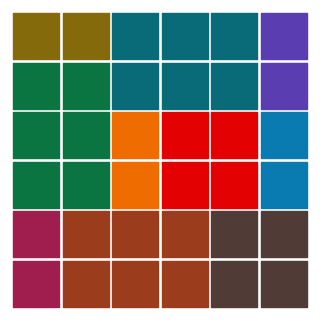

In [ ]:
patches.solve()
patches.show()

Running above block, the method `show()` returns the solved game, which matches the official solution of Patches No. 16, as expected.

:::{figure} ../../assets/how-to-solve/patches/solution.jpg
:label: patches-solution
:alt: Patches solution
:align: center
:width: 60%
Solved instance visualization.
:::